# Forward Motors: Stage 3 EDA
**DSBA 6165 | Mam Salan Njie and Will Moore**

**The project in one line:** MMR is the price guide car dealers bid with. It's right on average but often wrong for a single car, and we want to predict *where* it will be wrong before the bidding starts.

- **Target:** `sellingprice`, what the car actually sold for
- **Key input:** `mmr`, the guide price
- **What we explore most:** the gap between the two

This notebook covers the two datasets behind our proposal:

| | Auction prices (Part A) | Damage images (Part B) |
|---|---|---|
| Source | Vehicle Sales Data, Kaggle v1 (Afridi, 2024) | CarDD (Wang, Li & Wu, 2023) |
| Samples | 558,837 transactions; 548,202 after cleaning | 4,000 images; 8,740 damage instances |
| Target | `sellingprice`, continuous (regression) | 6 damage classes + box + mask per instance |
| Split | Whole sale days: 384,673 train / 77,205 val / 86,324 test | Official: 2,816 train / 810 val / 374 test |
| Benchmark | Recorded MMR: \$1,083 MAE on the test split | Published CarDD results |

The two datasets are analyzed separately, because no photo in one is linked to a sale in the other.

## Part A. Auction-price EDA

### How to run
In Colab, choose **Runtime → Run all** and mount the Drive account that holds the project data. Part A uses the verified auction CSV or downloads its public Kaggle version. Part B checks existing CarDD folders, including prior local stages, then restores our saved Drive TAR if needed.

The known cache is `MyDrive/forward-motors/_fm_cache/cardd/CarDD_core_COCO_plus_image_info.tar`. Restoration needs about 3.2 GiB of free local disk space and may take a few minutes. For another authorized copy, set `FM_CARDD_ROOT` to its release/COCO folder before setup; `FM_CARDD_TAR` can point to an existing archive. Outside Colab, set `FM_CSV_PATH` to the auction CSV.

**Saved results:** the auction/VIN analyses and CarDD figures retain their executed results. This loader repair was tested with complete and malformed small fixtures; the real Drive archive has not been rerun by this revision. No model was trained.


### Where the evidence is, and what is missing
- **Auction records:** 558,837 rows in the verified CSV; 548,202 retained by the existing cleaning rules. A row is an auction record, not a unique VIN.
- **Time coverage:** records occur on 172 of 567 calendar days. Nine whole months have no records. The usable observations are concentrated in Dec 2014–Jul 2015; no-record periods are unknown coverage, not zero market activity.
- **Missing attributes:** transmission is absent in 11.7% of raw rows. Condition is absent in 22.0% of December 2014 records, although its overall missing rate is only 2.1%. Description fields often disappear together. Color/interior also contain 24,685 / 17,077 em-dash placeholders that the null count misses. Filling a blank does not recover the real attribute.
- **VIN recovery now completed:** 28,377 manufacturer specs were recovered for missing make/model/body values; 14,450 further candidates need review. The before/after chart below shows the rate for each attribute. Original fields remain unchanged.
- **Separate evidence:** CarDD supplies damage labels and photos, but no verified photo-to-auction-price join. Other project sources and their acquisition status are summarized under “What the data can support.”

The file still supports retrospective price prediction. Calendar trends, future-market claims and damage-to-price effects need stronger coverage or linked evidence.


## 1. Loading the data
Vehicle Sales Data (Kaggle, version 1) records wholesale auction sales, one row per sale. The same car can appear more than once if it was sold more than once. We check the file's hash before loading so every number below comes from the same version of the data.

In [ ]:
# @title Setup: imports, data locations and switches { display-mode: "form" }
import hashlib
import os
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.patches import Polygon, Rectangle
from matplotlib.ticker import StrMethodFormatter
from PIL import Image

SEED = 42  # fixes the random sample used for scatter plots
try:
    import google.colab  # noqa: F401  (only importable inside Colab)

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Auction data. Our copy is on Google Drive; anyone else gets the public Kaggle
# version 1. Either way, the file must match this hash before we use it.
CSV_PATH = Path(os.environ.get(
    "FM_CSV_PATH", "/content/drive/MyDrive/forward-motors/car_prices.csv"
))
KAGGLE_DATASET = "syedanwarafridi/vehicle-sales-data/versions/1"
CSV_SHA256 = "32ba3ce51664e6a12c0c927ed193b41e3c4743fdf18bc0317389892aed27f556"

# CarDD is loaded from the authorized release or our existing Drive cache.
CARDD_ROOT_OVERRIDE = os.environ.get("FM_CARDD_ROOT")
CARDD_DRIVE_ROOTS = [
    Path("/content/CarDD_release/CarDD_COCO"),
    Path("/content/CarDD_release"),
    Path("/content/drive/MyDrive/CarDD_release/CarDD_COCO"),
    Path("/content/drive/MyDrive/CarDD_release"),
    Path.home() / ".cache/kagglehub/datasets/issamjebnouni/cardd/versions/1",
]
CARDD_CACHE_ARCHIVE = Path(os.environ.get(
    "FM_CARDD_TAR",
    "/content/drive/MyDrive/forward-motors/_fm_cache/cardd/CarDD_core_COCO_plus_image_info.tar",
))
CARDD_STAGE_PARENT = Path(os.environ.get("FM_CARDD_STAGE", "/content" if IN_COLAB else "."))
# No automatic CarDD download. Existing local copies are checked before use.

# In Colab, mount Google Drive so our own copies are used when they are available.
MOUNT_GOOGLE_DRIVE = IN_COLAB

# Optional: hash every CarDD image to look for byte-identical duplicates (slow).
HASH_CARDD_PIXELS = False


### Display settings

In [2]:
# @title Display settings: colors, table and chart style { display-mode: "form" }
# One color per partition, reused by every chart in both parts of the notebook.
SPLIT_COLORS = {
    "train": "#35618F",
    "validation": "#8066A6",
    "test": "#B87925",
}
BLUE = "#35618F"
TEAL = "#387D7A"
RUST = "#AD5D49"
LIGHT_GRAY = "#C9CED3"

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 30)
pd.set_option("display.precision", 3)

sns.set_theme(style="whitegrid", context="notebook", palette=[BLUE, TEAL, RUST])
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "figure.facecolor": "white",
        "axes.titleweight": "semibold",
        "axes.titlepad": 14,
        "axes.labelpad": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.color": "#E5E8EB",
        "grid.linewidth": 0.6,
        "legend.frameon": False,
    }
)


def format_dollar_axis(axis, which="y"):
    """Show tick labels as $12,000 instead of 12000."""
    target = axis.yaxis if which == "y" else axis.xaxis
    target.set_major_formatter(StrMethodFormatter("${x:,.0f}"))

In [ ]:
# @title Mount Drive when requested; data selection happens in each part { display-mode: "form" }
# The public auction CSV can be downloaded without Drive. CarDD uses an authorized copy.
if MOUNT_GOOGLE_DRIVE and not Path("/content/drive/MyDrive").is_dir():
    from google.colab import drive

    try:
        drive.mount("/content/drive")
    except ValueError:
        print("Drive was not mounted. Part A can use the public auction CSV.")
        print("Part B still needs an authorized CarDD folder or the existing cache archive.")

csv_source = "configured CSV" if CSV_PATH.is_file() else "public Kaggle auction download"
print(f"Auction CSV: {csv_source}")
if CARDD_ROOT_OVERRIDE:
    print("CarDD: the explicit FM_CARDD_ROOT will be validated in Part B.")
elif CARDD_CACHE_ARCHIVE.is_file():
    print("CarDD: saved cache archive found; Part B will restore it if no complete folder is available.")
else:
    print("CarDD: Part B will check existing folders and prior local stages.")
print("CarDD is not downloaded automatically.")


In [4]:
# @title Load the auction CSV and check it is the right version { display-mode: "form" }
def file_sha256(path):
    """Hash a file in 1 MB chunks so a large file never sits in memory at once."""
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def locate_auction_csv(drive_path, kaggle_dataset):
    """Use our Drive copy if it exists; otherwise download the public Kaggle version."""
    if drive_path.is_file():
        return drive_path

    import kagglehub  # preinstalled in Colab; elsewhere: pip install kagglehub

    download_dir = Path(kagglehub.dataset_download(kaggle_dataset))
    return download_dir / "car_prices.csv"


def load_auction_data(path, expected_hash):
    """Read the CSV, but only if it is the exact file this notebook was written against."""
    if not path.is_file():
        raise FileNotFoundError(f"car_prices.csv not found at {path}")
    actual_hash = file_sha256(path)
    if actual_hash != expected_hash:
        raise ValueError(
            f"{path} has SHA-256 {actual_hash}, expected {expected_hash}. "
            "This is not the Kaggle version 1 file the project uses."
        )
    return pd.read_csv(path)


csv_path = locate_auction_csv(CSV_PATH, KAGGLE_DATASET)
cars = load_auction_data(csv_path, CSV_SHA256)
print(f"Loaded {len(cars):,} auction sales with {cars.shape[1]} columns")

# VIN identifies an individual car, so we leave it out of the preview.
display(cars.drop(columns="vin").head())

Loaded 558,837 auction sales with 16 columns


,year,make,model,trim,body,transmission,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [5]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


### What each column is

| Column | Meaning |
|---|---|
| `year` | Model year of the vehicle |
| `make`, `model`, `trim`, `body` | What the vehicle is |
| `transmission` | Automatic or manual (some blanks and a few bad values) |
| `vin` | Vehicle identification number; the same car can be sold more than once |
| `state` | State code |
| `condition` | Condition code from 1 to 49 (the source does not document the scale) |
| `odometer` | Mileage at sale |
| `color`, `interior` | Exterior and interior color |
| `seller` | The seller (whoever put the car up for auction), as recorded |
| `mmr` | Manheim Market Report value, the industry price guide |
| `sellingprice` | What the car actually sold for: **our target** |
| `saledate` | Date and time of the sale |

### How each column is used
Not every column is a model input. The table below says which ones are, along with each column's type, number of distinct values and share missing. The second table summarizes the numeric columns; skewness above 1 means a long right tail.

In [6]:
# Everything is a model input unless it is the target, an identifier, or the split date.
column_roles = {column: "input" for column in cars.columns}
column_roles["sellingprice"] = "target"
column_roles["mmr"] = "input, and the benchmark to beat"
column_roles["vin"] = "identifier (never an input)"
column_roles["saledate"] = "sale date (used to split the data)"

column_overview = pd.DataFrame(
    {
        "role": pd.Series(column_roles),
        "type": cars.dtypes.astype(str),
        "distinct_values": cars.nunique(),
        "missing_pct": (100 * cars.isna().mean()).round(2),
    }
)
display(column_overview)

numeric_summary = cars.describe().T
numeric_summary["skewness"] = cars.select_dtypes("number").skew()
display(numeric_summary.round(2))

,role,type,distinct_values,missing_pct
year,input,int64,34,0.00
make,input,object,96,1.84
model,input,object,973,1.86
trim,input,object,1963,1.91
body,input,object,87,2.36
transmission,input,object,4,11.69
vin,identifier (never an input),object,550297,0.00
state,input,object,64,0.00
condition,input,float64,41,2.12
odometer,input,float64,172278,0.02


,count,mean,std,min,25%,50%,75%,max,skewness
year,558837.0,2010.04,3.97,1982.0,2007.0,2012.0,2013.0,2015.0,-1.18
condition,547017.0,30.67,13.40,1.0,23.0,35.0,42.0,49.0,-0.83
odometer,558743.0,68320.02,53398.54,1.0,28371.0,52254.0,99109.0,999999.0,1.84
mmr,558799.0,13769.38,9679.97,25.0,7100.0,12250.0,18300.0,182000.0,2.00
sellingprice,558825.0,13611.36,9749.50,1.0,6900.0,12100.0,18200.0,230000.0,1.95


## 2. Missing values
What is missing, and does it matter?

,missing_records,missing_pct
transmission,65352,11.69
body,13195,2.36
condition,11820,2.12
trim,10651,1.91
model,10399,1.86
make,10301,1.84
color,749,0.13
interior,749,0.13
odometer,94,0.02
mmr,38,0.01


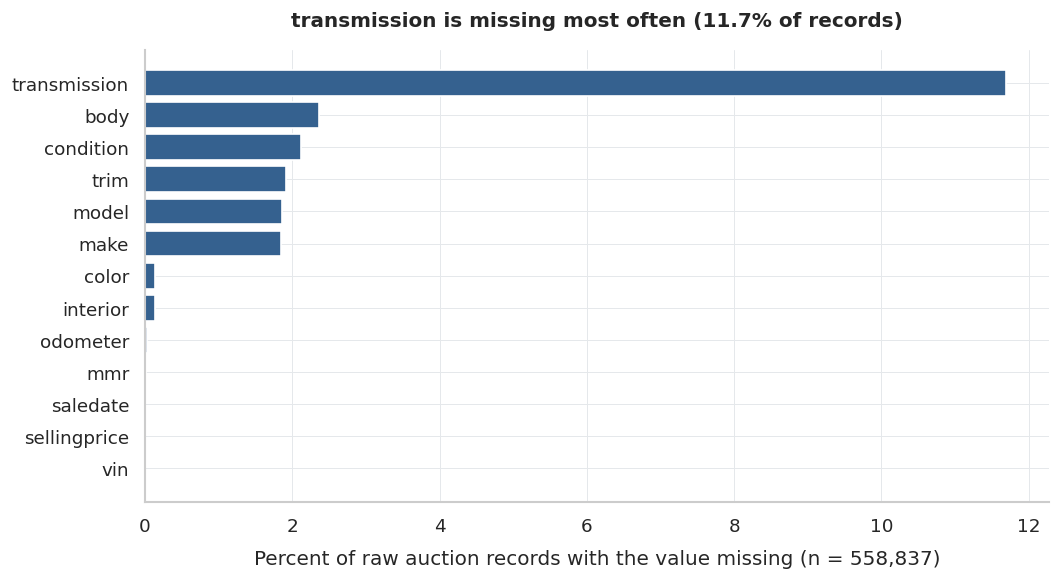

In [7]:
missing = pd.DataFrame(
    {
        "missing_records": cars.isna().sum(),
        "missing_pct": (100 * cars.isna().mean()).round(2),
    }
).sort_values("missing_records", ascending=False)
display(missing)

columns_with_gaps = missing[missing["missing_records"] > 0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(columns_with_gaps.index, columns_with_gaps["missing_pct"], color=BLUE)
ax.invert_yaxis()  # biggest gap on top
ax.set_xlabel(f"Percent of raw auction records with the value missing (n = {len(cars):,})")
top_gap = columns_with_gaps.index[0]
ax.set_title(
    f"{top_gap} is missing most often ({columns_with_gaps['missing_pct'].iloc[0]:.1f}% of records)"
)
plt.tight_layout()
plt.show()


**Missing attributes need their own audit; one overall rate is not enough.**

| Column | Missing in raw data | Treatment and limit |
|---|---:|---|
| `transmission` | 65,352 (11.7%) | Keep records with an explicit missing category; do not infer a gearbox from the majority class |
| `condition` | 11,820 (2.1%) | Retain missingness; train-only imputation is a model convenience, not recovered condition. Missingness is concentrated in December 2014 |
| `make`, `model`, `trim`, `body` | about 2% each | Often missing together. Current baseline excludes rows missing both make and model, although all 10,301 retain syntactically valid VINs; the external VIN evidence below has not been applied to this baseline |
| Price, MMR and sale date | small number | Their absence or malformed rows prevents benchmark scoring and/or temporal assignment |

Absent columns are different from blank cells. These records do not supply linked photos, repair costs, acquisition-to-resale profit, a buyer identifier, MMR publication timestamps or a complete observation calendar. No imputation can reconstruct those facts.


In [8]:
# Are the description fields missing on the same sales, or on different ones?
description_columns = ["make", "model", "trim", "body"]
missing_any = cars[description_columns].isna().any(axis=1).sum()
missing_all = cars[description_columns].isna().all(axis=1).sum()

print(f"Sales missing at least one description field: {missing_any:,}")
print(f"Sales missing all four description fields:    {missing_all:,}")
print(f"Share of those missing all four at once:      {missing_all / missing_any:.1%}")

Sales missing at least one description field: 13,293
Sales missing all four description fields:    10,301
Share of those missing all four at once:      77.5%


### Are the blanks random, clustered, or encoded as text?
These are **diagnostics on the original values**. Nothing below imputes, replaces, or encodes features. We inspect date, seller, make, price band and co-missingness to decide which explanations and future treatments are plausible. Association alone cannot distinguish missing-at-random (MAR) from missing-not-at-random (MNAR).


In [9]:
# isna() does not count text placeholders. Report them without changing the CSV.
placeholder_rows = []
for column in ["color", "interior", "transmission", "body"]:
    text = cars[column].astype("string").str.strip()
    placeholder_rows.append({
        "field": column, "null records": int(cars[column].isna().sum()),
        "em-dash records": int(text.eq("—").fillna(False).sum()),
        "blank-string records": int(text.eq("").fillna(False).sum()),
        "raw records": len(cars),
    })
display(pd.DataFrame(placeholder_rows).set_index("field"))

# A field can be present syntactically while its meaning is unrecorded.
patterns = cars[["make", "model", "trim", "body", "condition", "transmission"]].isna()
pattern_counts = patterns.value_counts().head(8).rename("raw records").reset_index()
display(pattern_counts)
print("True means the raw field is null. Em-dash labels remain separate and unaltered.")


True means the raw field is null. Em-dash labels remain separate and unaltered.


,null records,em-dash records,blank-string records,raw records
field,,,,
color,749,24685,0,558837
interior,749,17077,0,558837
transmission,65352,0,0,558837
body,13195,0,0,558837


,make,model,trim,body,condition,transmission,raw records
0,False,False,False,False,False,False,472902
1,False,False,False,False,False,True,61416
2,False,False,False,False,True,False,9459
3,True,True,True,True,False,False,8471
4,False,False,False,True,False,False,1828
5,False,False,False,False,True,True,1767
6,True,True,True,True,False,True,1743
7,False,False,False,True,True,False,348


In [10]:
# Outcomes are used only to describe selection, never to fill a predictor.
profile_rows = []
for field in ["condition", "transmission", "make", "odometer"]:
    for is_missing, group in cars.groupby(cars[field].isna()):
        profile_rows.append({
            "field": field, "status": "missing" if is_missing else "observed",
            "raw records": len(group), "priced records": group["sellingprice"].count(),
            "median sale price ($)": group["sellingprice"].median(),
            "median odometer": group["odometer"].median() if group["odometer"].notna().any() else np.nan,
        })
display(pd.DataFrame(profile_rows).set_index(["field", "status"]).round(1))

price_band = pd.cut(cars["sellingprice"], [-float("inf"), 5000, 10000, 20000, 40000, float("inf")],
                    right=False, labels=["under $5k", "$5–10k", "$10–20k", "$20–40k", "$40k+"])
price_missingness = cars[["condition", "transmission", "make", "odometer"]].isna()
price_missingness["price band"] = price_band
by_price = price_missingness.groupby("price band", observed=True).mean() * 100
by_price["records with observed price"] = price_band.value_counts().reindex(by_price.index)
display(by_price.round(2))


raw records  priced records  median sale price ($)  \
field        status                                                         
condition    observed       547017          547005                12300.0   
             missing         11820           11820                 4400.0   
transmission observed       493485          493474                12000.0   
             missing         65352           65351                13500.0   
make         observed       548536          548524                12200.0   
             missing         10301           10301                 5800.0   
odometer     observed       558743          558731                12100.0   
             missing            94              94                 1375.0   

                       median odometer  
field        status                     
condition    observed          51222.0  
             missing          115975.0  
transmission observed          53100.0  
             missing           45784.0  
make         observed          51396.0  
             missing          106560.0  
odometer     observed          52254.0  
             missing               NaN

,condition,transmission,make,odometer,records with observed price
price band,,,,,
under $5k,6.28,10.61,4.51,0.08,102344
$5–10k,2.61,9.38,2.32,0.00,109914
$10–20k,0.82,12.04,0.89,0.00,232732
$20–40k,0.56,14.25,0.81,0.00,104342
$40k+,0.31,13.57,2.28,0.00,9493


In [11]:
def missingness_by_group(frame, field, group_column, minimum_records=200):
    """Descriptive rates; low-denominator groups stay outside this ranked view."""
    source = frame[[field, group_column]].copy()
    source["missing"] = source[field].isna()
    grouped = source.groupby(group_column, dropna=False).agg(
        records=("missing", "size"), missing_records=("missing", "sum")
    )
    grouped["missing_pct"] = 100 * grouped["missing_records"] / grouped["records"]
    return grouped.loc[grouped["records"] >= minimum_records].sort_values(
        ["missing_pct", "records"], ascending=False
    )

for field in ["condition", "transmission"]:
    for group_column in ["seller", "make"]:
        print(f"{field}: highest missing rates by {group_column}, at least 200 raw records")
        display(missingness_by_group(cars, field, group_column).head(5).round(2))


condition: highest missing rates by seller, at least 200 raw records
condition: highest missing rates by make, at least 200 raw records
transmission: highest missing rates by seller, at least 200 raw records
transmission: highest missing rates by make, at least 200 raw records


,records,missing_records,missing_pct
seller,,,
woodhouse ford inc,309,89,28.80
carriage traders,201,37,18.41
pro financial inc,269,34,12.64
hertz/tra,674,78,11.57
arrowhead auto group inc,391,43,11.00


,records,missing_records,missing_pct
make,,,
dodge,245,52,21.22
ford,443,94,21.22
chevrolet,390,56,14.36
chrysler,209,29,13.88
Oldsmobile,364,31,8.52


,records,missing_records,missing_pct
seller,,,
fca canada inc,958,958,100.0
chrysler canada inc,936,936,100.0
mercedes-benz,313,313,100.0
ford motor company of canada,304,304,100.0
financialinx,281,281,100.0


,records,missing_records,missing_pct
make,,,
dodge,245,77,31.43
Land Rover,1735,394,22.71
ford,443,95,21.44
Acura,5901,1259,21.34
NaN,10301,1761,17.10


**What could explain this? What can we actually establish?**
- Condition missingness is concentrated in the first dense collection block, and the affected vehicles have lower prices and higher mileage. This is inconsistent with treating the missing rows as a harmless representative sample; the actual cause could involve reporting, source-system changes, seller mix or vehicle selection. The file has no ingestion/source-system log to distinguish these explanations.
- Transmission blanks recur across months and differ by seller/make. “Assume automatic” would create unverified labels and could erase a real subgroup.
- Description fields frequently disappear together. That is compatible with a failed lookup or incomplete source record, but the mechanism is not documented.
- Color/interior em dashes are recorded tokens without a documented interpretation. Count them separately; do not mistake them for actual colors or silently convert them into a known value.
- Request the uploader's schema, condition codebook, export/collection dates, field provenance and missing-value conventions. Compare raw source rows before repairing a suspected formatting error. These requests are the next evidence needed, not facts already recovered.


### VIN lookup: make, model and body recover well; transmission still has a large gap
**We recovered manufacturer specs for 89.6% of missing makes, 83.4% of missing models and 79.4% of missing body labels.** Trim and transmission stay in the review pile.

We sent VIN and model year to [NHTSA's vPIC decoder](https://vpic.nhtsa.dot.gov/api/) on **October 5, 2026**. It uses manufacturer-submitted vehicle specifications. The completed lookup covers **75,940 VIN/year pairs**, including the missing-field queue and controls. No API key was needed.

“Recovered” below means a manufacturer spec passed our checks and is retained beside the auction data. The original auction fields are preserved. These 2026 lookups do not verify a car's condition or equipment at its 2014–15 auction.


In [12]:
# Dated source receipt. The full VIN-free candidate snapshot is inside this notebook's metadata.
vin_evidence = {
    "retrieved_on": "2026-10-05",
    "source_url": "https://vpic.nhtsa.dot.gov/api/vehicles/DecodeVINValuesBatch/",
    "source_csv_sha256": "32ba3ce51664e6a12c0c927ed193b41e3c4743fdf18bc0317389892aed27f556",
    "candidate_csv_sha256": "7f3159b709b7c63de8b1f9a859bcb00d407060fdeaefc45836d6eeda45f2d491",
    "lookup_csv_sha256": "d230210bea55b6cf41ced58773ca9cb7e2ebf5cce2206831f22c6780dbbb7c2e",
    "request_window_utc": "2026-10-05 07:07:26 to 09:50:35",
    "decoded_vin_year_pairs": 75_940,
    "eligible_decodes": 70_430,
    "affected_auction_records": 18_938,
    "raw_fields_overwritten": 0,
}
assert CSV_SHA256 == vin_evidence["source_csv_sha256"]
assert len(cars) == 558_837


In [13]:
# Load this notebook's embedded snapshot. No NHTSA requests are made on rerun.
import base64
import gzip
import io
from urllib.request import urlopen

notebook_copy = Path(os.environ.get("FM_NOTEBOOK_PATH", "Forward_Motors_Stage3_EDA_Final.ipynb"))
if notebook_copy.is_file():
    notebook_json = json.loads(notebook_copy.read_text())
else:
    # Colab does not automatically place an open notebook in /content.
    notebook_url = "https://raw.githubusercontent.com/wmoore012/forward-motors/main/Forward_Motors_Stage3_EDA_Final.ipynb"
    with urlopen(notebook_url, timeout=60) as response:
        notebook_json = json.load(response)
snapshot = notebook_json["metadata"]["vin_recovery_snapshot"]
packed_evidence = base64.b64decode(snapshot["payload"], validate=True)
assert hashlib.sha256(packed_evidence).hexdigest() == "a3ebf49615bd31027be4d2e2e3731c549d1de0bf5845ee1a6eaecda192ec42a4"
candidate_bytes = gzip.decompress(packed_evidence)
assert hashlib.sha256(candidate_bytes).hexdigest() == "7190ed0eec58444d19ae167f3c5a7ea9cc34941d401e421793ac55377ef3f099"
vin_candidates = pd.read_csv(io.BytesIO(candidate_bytes), dtype=str, keep_default_na=False)
assert len(vin_candidates) == 42_827
assert not vin_candidates.duplicated(["source_row", "field"]).any()
assert vin_candidates["original_value"].eq("").all()
assert vin_candidates["recovered_value"].ne("").all()
assert not any("vin" in column.lower() for column in vin_candidates.columns)
print(f"Loaded {len(vin_candidates):,} archived row-field candidates from this notebook.")


Loaded 42,827 archived row-field candidates from this notebook.


In [14]:
# Recalculate every chart count from individual candidates and the untouched auction rows.
fields = ["make", "model", "trim", "body", "transmission"]
assert set(vin_candidates["field"]) == set(fields)
status_counts = pd.crosstab(vin_candidates["field"], vin_candidates["review_status"])
vin_recovery = pd.DataFrame({
    "originally_blank": cars[fields].isna().sum(),
    "recovered_spec": status_counts["supplemental_static_spec"],
    "needs_review": status_counts["review_required_not_auto_fill"],
}).sort_values("originally_blank", ascending=False)
vin_recovery["no_candidate"] = vin_recovery["originally_blank"] - vin_recovery["recovered_spec"] - vin_recovery["needs_review"]
vin_recovery["recovered_pct_of_missing"] = 100 * vin_recovery["recovered_spec"] / vin_recovery["originally_blank"]

for field, group in vin_candidates.groupby("field"):
    source_rows = group["source_row"].astype(int).to_numpy()
    assert cars.loc[source_rows, field].isna().all()
    assert cars.loc[source_rows, "year"].astype(str).tolist() == group["model_year_hint"].tolist()
review_only = vin_candidates["field"].isin(["trim", "transmission"])
assert vin_candidates.loc[review_only, "review_status"].eq("review_required_not_auto_fill").all()
assert vin_recovery["no_candidate"].ge(0).all()
assert vin_recovery["recovered_spec"].sum() == 28_377
assert vin_recovery["needs_review"].sum() == 14_450
assert vin_recovery["no_candidate"].sum() == 67_071
assert vin_candidates["source_row"].nunique() == 18_938


#### Before and after the lookup
Both bar panels use the same scale and the same **558,837 auction records**. The recovery percentage on the right divides recovered specs by the **original blanks in that attribute**. Orange values still need review and do not count as recovered.


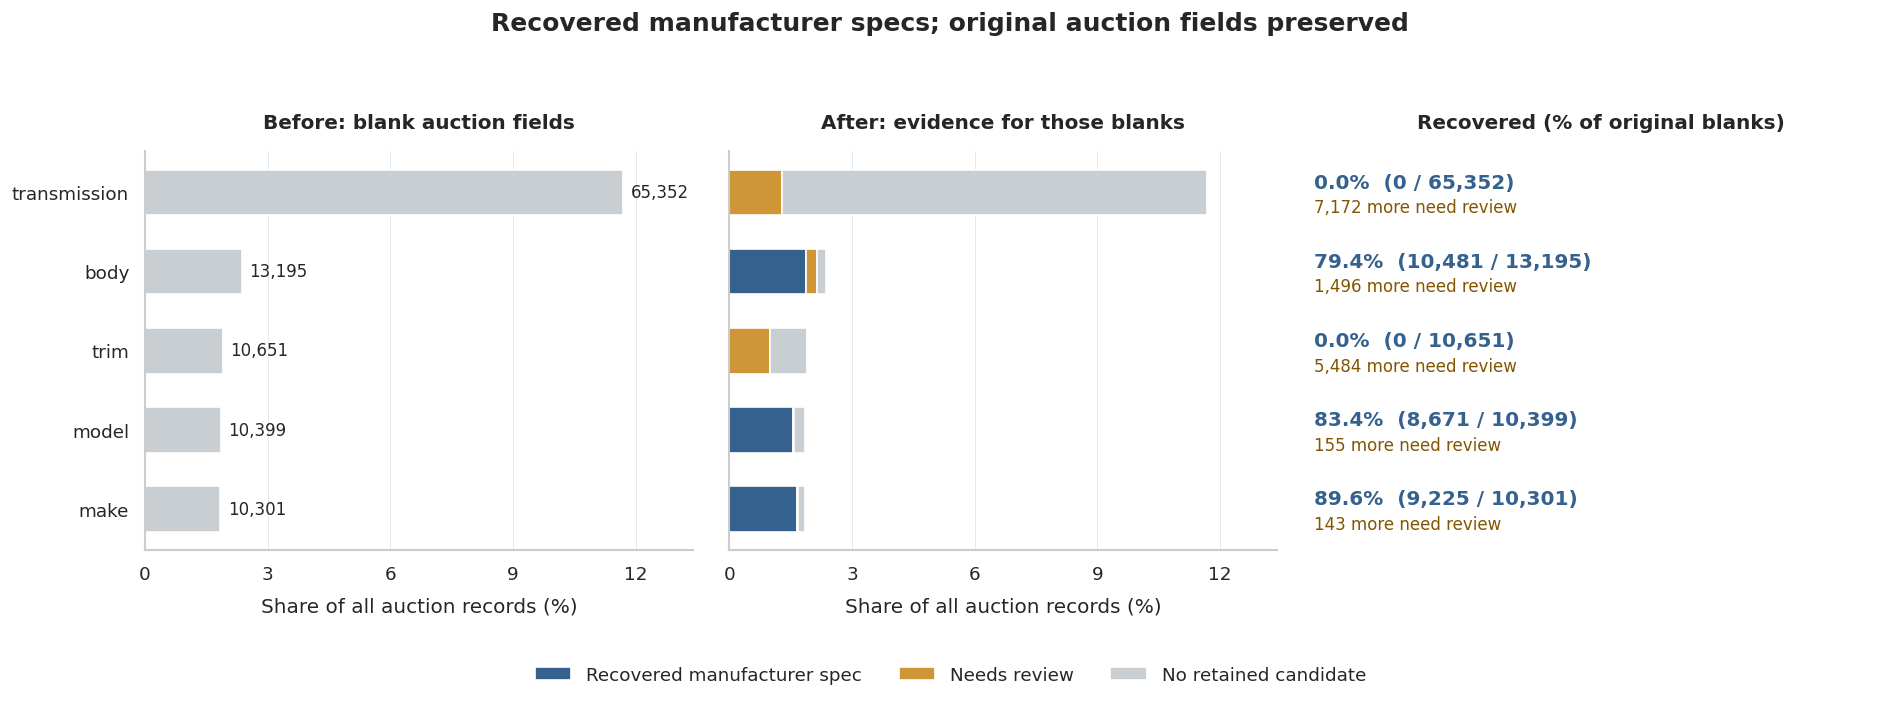

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.8), sharey=True,
                         gridspec_kw={"width_ratios": [1, 1, 1.05]})
positions = np.arange(len(vin_recovery))
share = vin_recovery / len(cars) * 100
axes[0].barh(positions, share["originally_blank"], color=LIGHT_GRAY, height=.58)
axes[0].set_yticks(positions, vin_recovery.index)
axes[0].invert_yaxis()
axes[0].set_title("Before: blank auction fields")
for position, count in enumerate(vin_recovery["originally_blank"]):
    axes[0].text(count / len(cars) * 100 + .18, position, f"{count:,}", va="center", fontsize=10)

left = np.zeros(len(vin_recovery))
for column, color, label in [
    ("recovered_spec", BLUE, "Recovered manufacturer spec"),
    ("needs_review", "#CF9638", "Needs review"),
    ("no_candidate", LIGHT_GRAY, "No retained candidate"),
]:
    axes[1].barh(positions, share[column], left=left, height=.58, color=color, label=label)
    left += share[column].to_numpy()
axes[1].set_title("After: evidence for those blanks")
for ax in axes[:2]:
    ax.set_xlim(0, 13.4)
    ax.set_xlabel("Share of all auction records (%)")
    ax.set_xticks([0, 3, 6, 9, 12])
    ax.grid(axis="y", visible=False)

axes[2].set_title("Recovered (% of original blanks)")
axes[2].set_xlim(0, 1)
axes[2].axis("off")
for position, (_, row) in enumerate(vin_recovery.iterrows()):
    axes[2].text(0, position - .13,
                 f"{row['recovered_pct_of_missing']:.1f}%  ({row['recovered_spec']:,.0f} / {row['originally_blank']:,.0f})",
                 color=BLUE, fontweight="semibold", fontsize=12, va="center")
    axes[2].text(0, position + .19, f"{row['needs_review']:,.0f} more need review",
                 color="#835500", fontsize=10, va="center")
fig.suptitle("Recovered manufacturer specs; original auction fields preserved", fontsize=15, fontweight="semibold")
fig.legend(*axes[1].get_legend_handles_labels(), loc="lower center", ncol=3, bbox_to_anchor=(.5, -.01))
fig.tight_layout(rect=[0, .08, 1, .93])
plt.show()


In [16]:
vin_count_table = vin_recovery.rename(columns={
    "originally_blank": "Before: blank records",
    "recovered_spec": "Recovered specs",
    "needs_review": "Needs review",
    "no_candidate": "No candidate",
    "recovered_pct_of_missing": "Recovered / originally blank (%)",
})
display(vin_count_table.round(1))
print("28,377 recovered specs + 14,450 review candidates + 67,071 unresolved = 109,898 original blank cells.")
print("These are field-level counts. One auction record can contribute several blanks.")
print("Original auction columns changed: 0. Rows with at least one retained candidate: 18,938.")


28,377 recovered specs + 14,450 review candidates + 67,071 unresolved = 109,898 original blank cells.
These are field-level counts. One auction record can contribute several blanks.
Original auction columns changed: 0. Rows with at least one retained candidate: 18,938.


,Before: blank records,Recovered specs,Needs review,No candidate,Recovered / originally blank (%)
transmission,65352,0,7172,58180,0.0
body,13195,10481,1496,1218,79.4
trim,10651,0,5484,5167,0.0
model,10399,8671,155,1573,83.4
make,10301,9225,143,933,89.6


#### What did we actually find?
The row numbers below refer to the original CSV, starting at zero. The recovered value is shown alongside the blank it explains. We retain the provider's wording; for example, `Sedan/Saloon` still needs a deliberate mapping to the auction's body labels.


In [17]:
# Selected examples are read from the same verified evidence, not hand-filled.
example_keys = [(742, "make"), (1514, "model"), (742, "body"),
                (1514, "trim"), (44, "transmission"), (17500, "make")]
example_rows = []
for source_row, field in example_keys:
    match = vin_candidates.loc[vin_candidates["source_row"].eq(str(source_row)) & vin_candidates["field"].eq(field)]
    assert len(match) == 1
    record = match.iloc[0]
    assert pd.isna(cars.loc[source_row, field])
    recovered = record["review_status"] == "supplemental_static_spec"
    disagreement = record["known_field_text_or_category_disagreements"]
    reason = f"Existing-label disagreement: {disagreement}" if disagreement else (
        "All trim/gearbox candidates held" if field in ["trim", "transmission"] else "VIN/year checks passed"
    )
    example_rows.append({"Source row": source_row, "Field": field, "Before": "blank",
                         "NHTSA value": record["recovered_value"],
                         "Decision": "Recovered spec" if recovered else "Needs review", "Reason": reason})
vin_examples = pd.DataFrame(example_rows)
display(vin_examples.style.hide(axis="index"))


Source row,Field,Before,NHTSA value,Decision,Reason
742,make,blank,BMW,Recovered spec,VIN/year checks passed
1514,model,blank,Range Rover,Recovered spec,VIN/year checks passed
742,body,blank,Sedan/Saloon,Recovered spec,VIN/year checks passed
1514,trim,blank,HSE LUX,Needs review,All trim/gearbox candidates held
44,transmission,blank,Automatic,Needs review,All trim/gearbox candidates held
17500,make,blank,CHEVROLET,Needs review,Existing-label disagreement: transmission


**Why did some values stay unresolved?**
- **Transmission:** NHTSA returned a retained candidate for only 7,172 of 65,352 blanks. Every gearbox value remains review-only.
- **Trim:** names do not line up reliably across the two sources. Only **44 of 84** comparable known trim labels matched in our stratified pilot. All 5,484 trim candidates stay in review.
- **Make, model and body:** we kept only error-free, unambiguous replies with matching VIN/year checks. A disagreement with an existing auction label sends the candidate to review. “Recovered” is provider-reported specification evidence, not a verified replacement for the auction taxonomy.
- **Condition, odometer and prices:** a VIN decoder cannot supply the missing auction-day observation. Those gaps still need the original inspection or transaction record.

**Checks behind the chart:** exact returned VIN, valid VIN/check digit, matching model year and VIN year code, decoder error code 0, and no extra warning, suggested VIN or multiple possible values. Broad body mappings and normalized label comparisons were used only for checking agreement. The pilot was deliberately stratified; its label agreement is not a population accuracy estimate.


#### Source and rerun notes
The **42,827 individual row-field candidates are embedded in this notebook**, without raw VINs. The loader checks their hashes, verifies their source-row IDs and recomputes the chart from the original auction blanks. In Colab it reads that snapshot from this same GitHub document; locally, keep the notebook beside the CSV or set `FM_NOTEBOOK_PATH`.

Rerunning the EDA does **not** repeat the API collection. The complete lookup and batch replies are archived separately, with their hashes recorded above. To repeat collection, use [NHTSA vPIC's documented batch endpoint](https://vpic.nhtsa.dot.gov/api/), submit VIN plus model year in batches of no more than 50, cache dated replies, and apply the stated checks. The saved run covered the 75,876-pair missing-field queue plus controls; all 75,940 requested pairs have responses. A new lookup is a new source version.

**Next step:** review the held values and model/body label mapping before deciding how to use them in Stage 4. This EDA and its existing price results still use the original auction columns.


### Duplicates
Two different questions: is any row an exact copy of another, and does the same car (VIN) show up more than once? A repeated VIN could be the same car sold again, a record entered twice, or a typo in the VIN. This file can't tell us which.

In [18]:
# An exact duplicate is a copy of a whole row. A repeated VIN is usually a real resale.
exact_duplicate_records = cars.duplicated().sum()
repeated_vin_and_date = (
    cars.dropna(subset=["vin"]).duplicated(subset=["vin", "saledate"]).sum()
)
vin_counts = cars["vin"].value_counts()

print(f"Exact duplicate rows:                      {exact_duplicate_records:,}")
print(f"Same VIN on the same sale date:            {repeated_vin_and_date:,}")
print(f"Distinct VINs:                             {len(vin_counts):,}")
print(f"VINs that appear in more than one sale:    {(vin_counts > 1).sum():,}")

Exact duplicate rows:                      0
Same VIN on the same sale date:            91
Distinct VINs:                             550,297
VINs that appear in more than one sale:    8,327


## 3. The target: auction sale price
`sellingprice` is a dollar amount, so this is a regression problem with no classes. How is it distributed?

In [19]:
price = cars["sellingprice"].dropna()

print(f"Auction sales with a price: {len(price):,}")
print(f"Mean:     ${price.mean():,.0f}")
print(f"Median:   ${price.median():,.0f}")
print(f"Skewness: {price.skew():.2f}")

percentile_levels = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]
price_percentiles = price.quantile(percentile_levels)
price_percentiles.index = [f"{level:.1%} percentile" for level in percentile_levels]
display(price_percentiles.map("${:,.0f}".format).rename("auction sale price").to_frame())

Auction sales with a price: 558,825
Mean:     $13,611
Median:   $12,100
Skewness: 1.95


,auction sale price
1.0% percentile,$500
5.0% percentile,"$1,500"
25.0% percentile,"$6,900"
50.0% percentile,"$12,100"
75.0% percentile,"$18,200"
95.0% percentile,"$30,600"
99.0% percentile,"$44,900"
99.9% percentile,"$78,000"


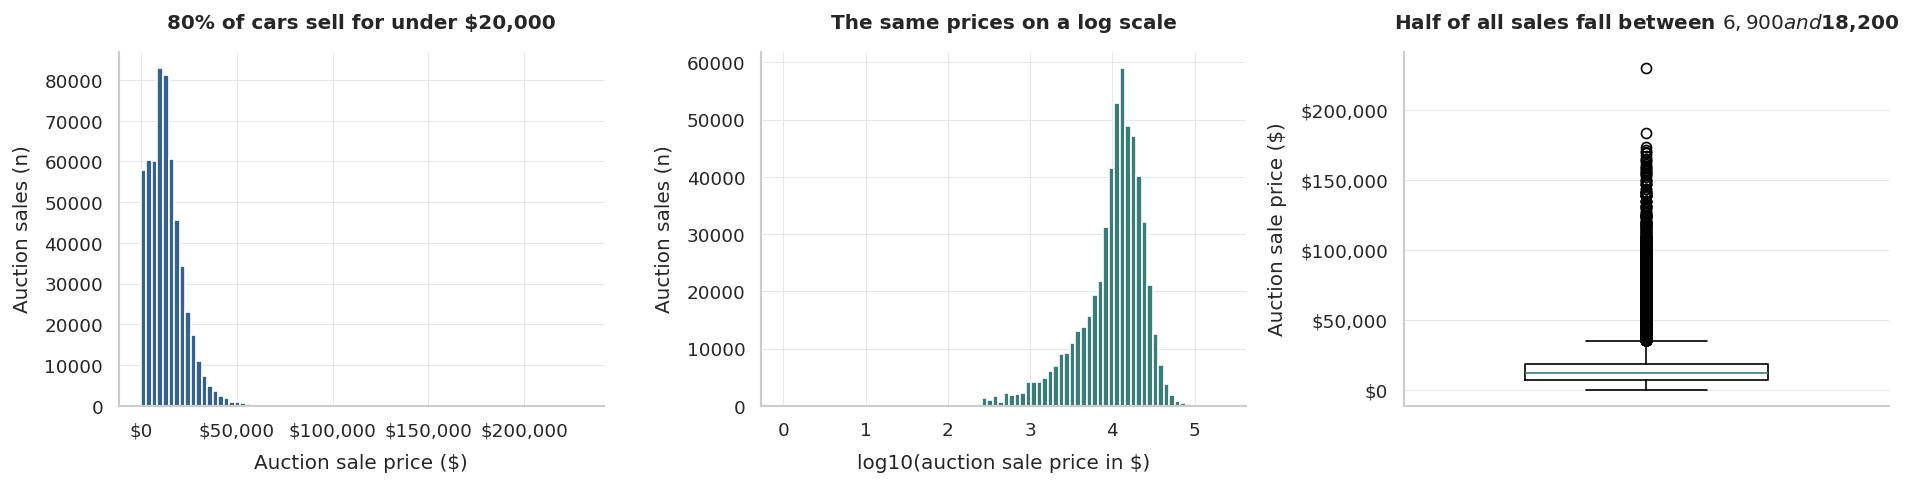

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

axes[0].hist(price, bins=80, color=BLUE, edgecolor="white")
axes[0].set_title(f"{(price < 20_000).mean():.0%} of cars sell for under $20,000")
axes[0].set_xlabel("Auction sale price ($)")
axes[0].set_ylabel("Auction sales (n)")
format_dollar_axis(axes[0], which="x")

# A log scale spreads out the tail so the bulk of the market is easier to see.
axes[1].hist(np.log10(price[price > 0]), bins=80, color=TEAL, edgecolor="white")
axes[1].set_title("The same prices on a log scale")
axes[1].set_xlabel("log10(auction sale price in $)")
axes[1].set_ylabel("Auction sales (n)")

axes[2].boxplot(price, widths=0.5)
lower_quartile, upper_quartile = price.quantile([0.25, 0.75])
axes[2].set_title(
    f"Half of all sales fall between ${lower_quartile:,.0f} and ${upper_quartile:,.0f}"
)
axes[2].set_ylabel("Auction sale price ($)")
axes[2].set_xticks([])
format_dollar_axis(axes[2])

plt.tight_layout()
plt.show()

**Takeaway: most cars are cheap, a few are very expensive.** Median \$12,100; 99th percentile \$44,900; max \$230,000.

What that means for modeling:
- **Average dollar error is driven by the expensive cars,** so we also report percent error and error by price band.
- **A model trained on raw dollars over-focuses on pricey cars,** so Stage 4 also tries predicting log price.

## 4. Numeric features

**Before reading the charts, two oddities:**
- **`condition` runs 1 to 49**, not the usual 1-to-5 dealer grade. The codes come in two clumps (1–5 and about 19–49). Our documentation doesn't say what they mean, so we keep them as recorded.
- **`odometer` tops out at 999,999 miles**, which looks like a placeholder. Cleaning drops anything over 500,000.

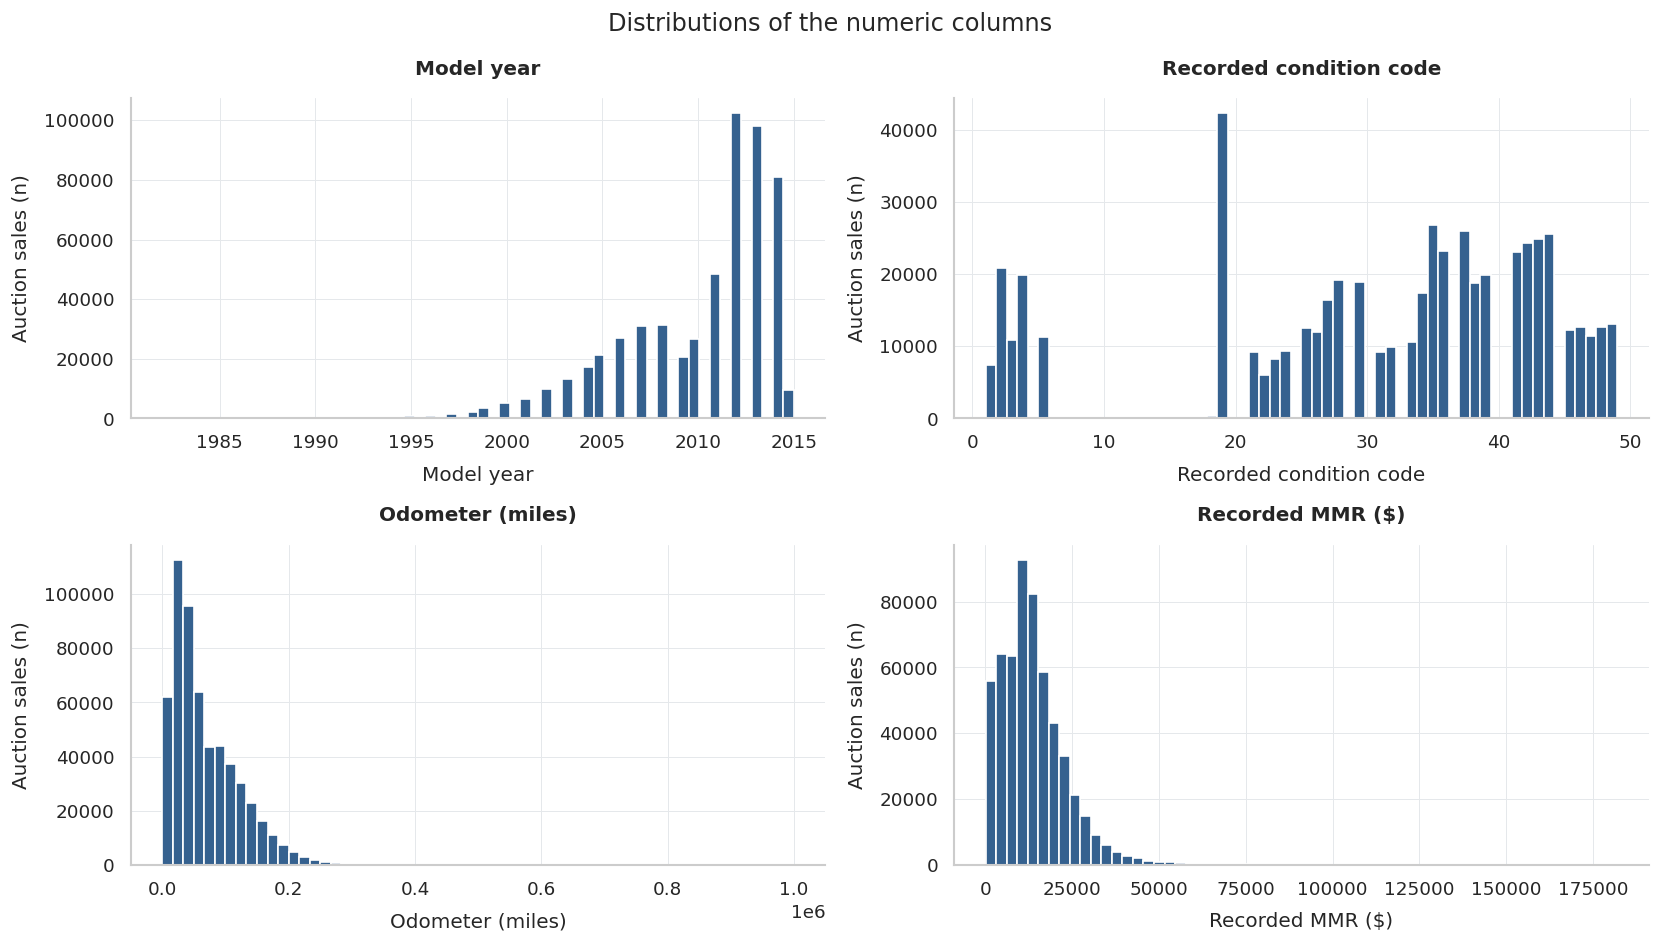

In [21]:
numeric_labels = {
    "year": "Model year",
    "condition": "Recorded condition code",
    "odometer": "Odometer (miles)",
    "mmr": "Recorded MMR ($)",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (column, label) in zip(axes.ravel(), numeric_labels.items(), strict=True):
    ax.hist(cars[column].dropna(), bins=60, color=BLUE, edgecolor="white")
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel("Auction sales (n)")

fig.suptitle("Distributions of the numeric columns")
plt.tight_layout()
plt.show()

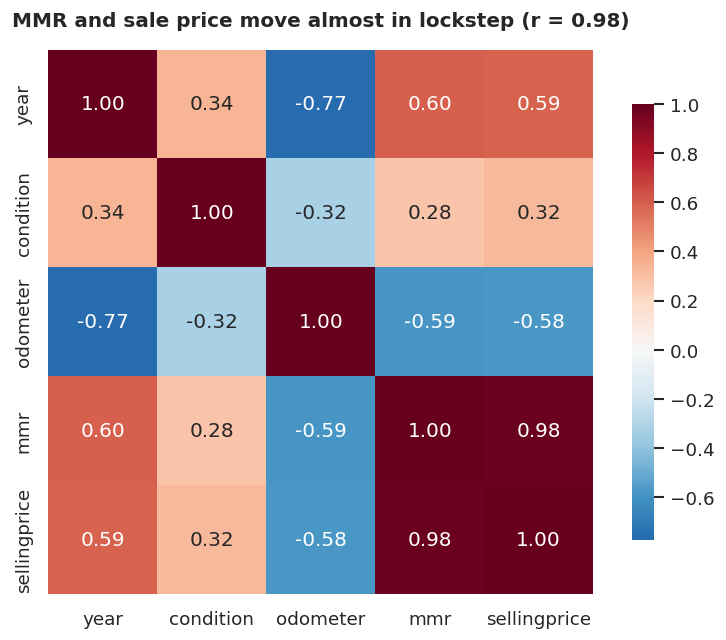

In [22]:
numeric_columns = ["year", "condition", "odometer", "mmr", "sellingprice"]
correlations = cars[numeric_columns].corr()
mmr_price_correlation = correlations.loc["mmr", "sellingprice"]

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_title(
    f"MMR and sale price move almost in lockstep (r = {mmr_price_correlation:.2f})"
)
plt.tight_layout()
plt.show()

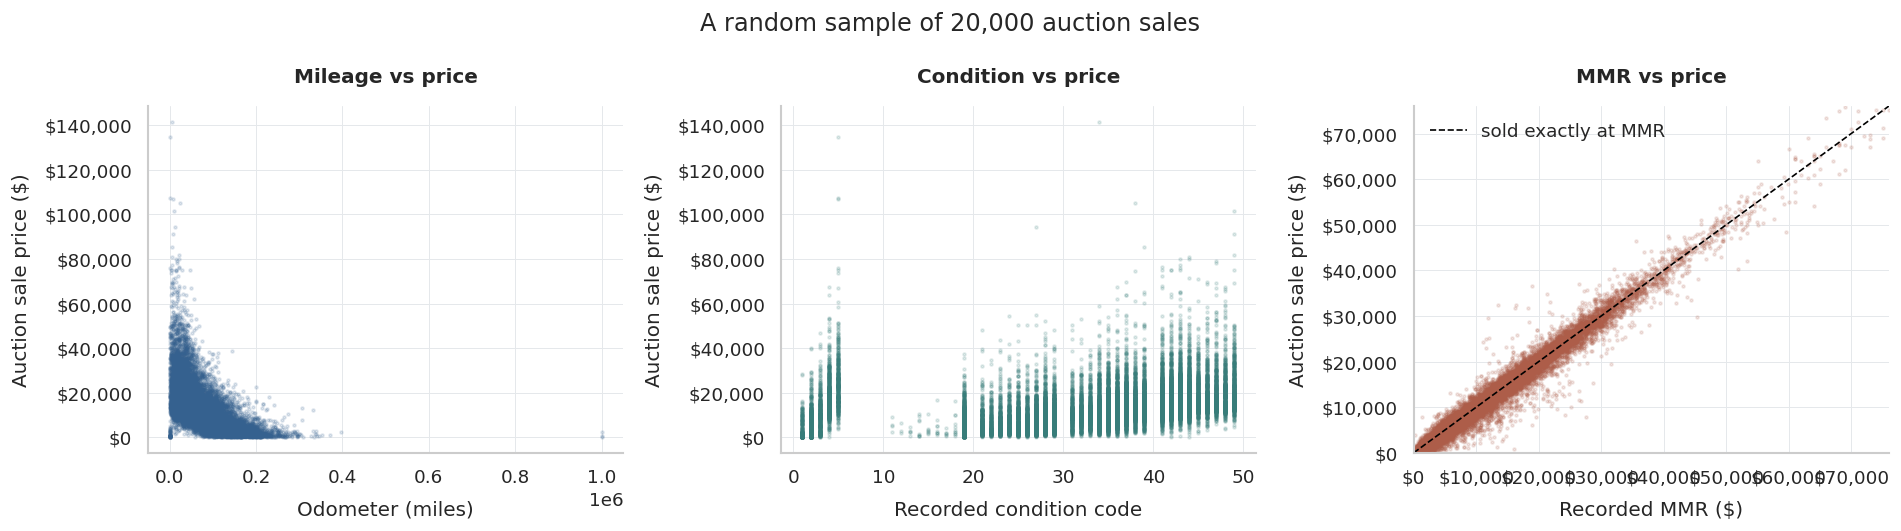

In [23]:
# A 20,000-sale sample keeps the scatter plots readable; 550,000 points would be a solid blob.
SCATTER_SAMPLE_SIZE = 20_000

plot_pool = cars.dropna(subset=["sellingprice", "odometer", "condition", "mmr"])
sample = plot_pool.sample(min(SCATTER_SAMPLE_SIZE, len(plot_pool)), random_state=SEED)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(sample["odometer"], sample["sellingprice"], s=3, alpha=0.15, color=BLUE)
axes[0].set_xlabel("Odometer (miles)")
axes[0].set_title("Mileage vs price")

axes[1].scatter(sample["condition"], sample["sellingprice"], s=3, alpha=0.15, color=TEAL)
axes[1].set_xlabel("Recorded condition code")
axes[1].set_title("Condition vs price")

# Zoom to the 99.9th percentile so a few very expensive cars don't squash the plot.
axis_limit = sample[["mmr", "sellingprice"]].quantile(0.999).max()
axes[2].scatter(sample["mmr"], sample["sellingprice"], s=3, alpha=0.15, color=RUST)
axes[2].plot(
    [0, axis_limit], [0, axis_limit], "k--", linewidth=1, label="sold exactly at MMR"
)
axes[2].set_xlim(0, axis_limit)
axes[2].set_ylim(0, axis_limit)
axes[2].set_xlabel("Recorded MMR ($)")
axes[2].set_title("MMR vs price")
axes[2].legend()
format_dollar_axis(axes[2], which="x")

for ax in axes:
    ax.set_ylabel("Auction sale price ($)")
    format_dollar_axis(ax)

fig.suptitle(f"A random sample of {len(sample):,} auction sales")
plt.tight_layout()
plt.show()

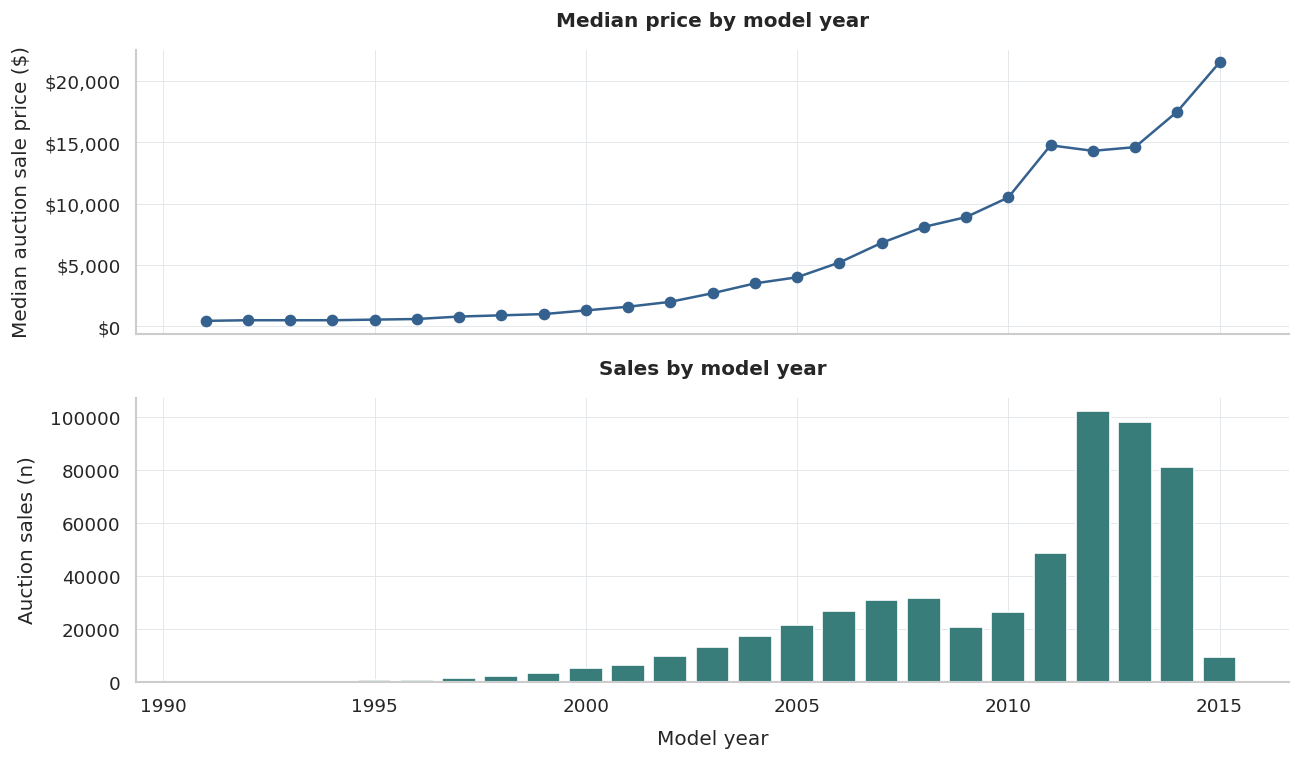

In [24]:
# Skip model years with fewer than 50 sales; a median from a handful of cars jumps around.
MIN_SALES_PER_YEAR = 50

by_year = cars.groupby("year")["sellingprice"].agg(median_price="median", sales="size")
by_year = by_year[by_year["sales"] >= MIN_SALES_PER_YEAR]

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

axes[0].plot(by_year.index, by_year["median_price"], marker="o", color=BLUE)
axes[0].set_ylabel("Median auction sale price ($)")
axes[0].set_title("Median price by model year")
format_dollar_axis(axes[0])

axes[1].bar(by_year.index, by_year["sales"], color=TEAL)
axes[1].set_ylabel("Auction sales (n)")
axes[1].set_xlabel("Model year")
axes[1].set_title("Sales by model year")

plt.tight_layout()
plt.show()

**Takeaways:**
- **Mileage:** price falls fast over the first miles, then levels off. That's a curve, not a straight line, so a linear model would need help; neural networks and gradient boosting can learn it directly.
- **MMR:** sale price hugs MMR (correlation about **0.98**). The spread around the diagonal is exactly what this project is about; Section 6 measures it.

## 5. Categorical features
How many distinct values does each text column have, and which values are most common?

,distinct_values,most_common,most_common_share_pct
column,,,
seller,14263,nissan-infiniti lt,3.5
trim,1963,Base,10.2
model,973,Altima,3.5
make,96,Ford,17.1
body,87,Sedan,36.6
state,64,fl,14.8
color,46,black,19.9
interior,17,black,43.8
transmission,4,automatic,96.4


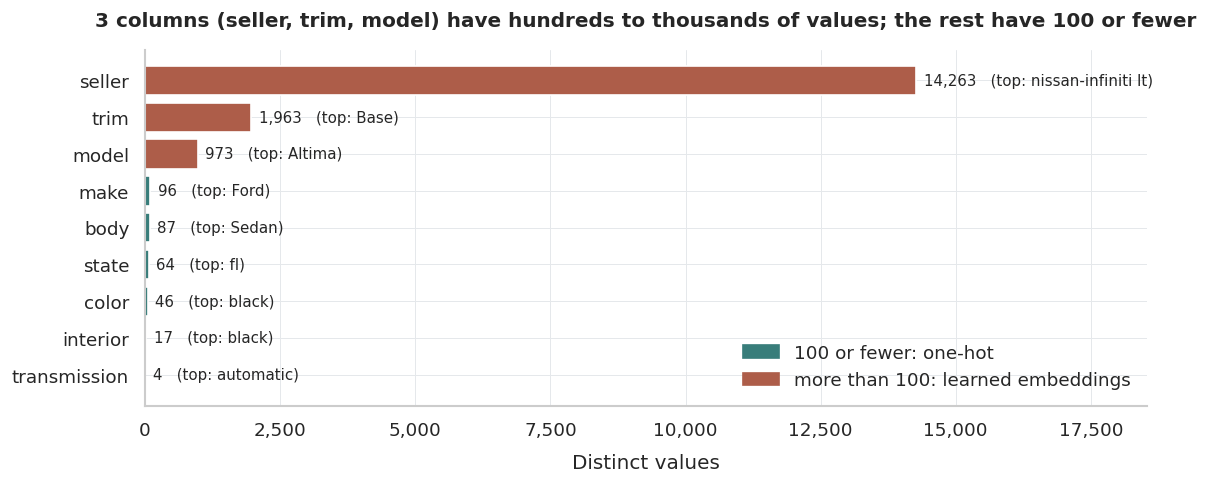

In [25]:
categorical_columns = [
    "make",
    "model",
    "trim",
    "body",
    "transmission",
    "state",
    "color",
    "interior",
    "seller",
]

category_rows = []
for column in categorical_columns:
    counts = cars[column].value_counts()
    category_rows.append(
        {
            "column": column,
            "distinct_values": len(counts),
            "most_common": counts.index[0],
            "most_common_share_pct": round(100 * counts.iloc[0] / counts.sum(), 1),
        }
    )

category_summary = pd.DataFrame(category_rows).set_index("column")
display(category_summary.sort_values("distinct_values", ascending=False))

# Chart: distinct values per column, colored by how we plan to encode it.
# Plain (linear) axis on purpose: on a log axis, bar lengths would hide that seller has
# about 150 times as many values as make.
ONE_HOT_LIMIT = 100  # at or under this many values, one-hot encoding stays manageable
distinct = category_summary["distinct_values"].sort_values()
bar_colors = [TEAL if count <= ONE_HOT_LIMIT else RUST for count in distinct]
many_values = distinct[distinct > ONE_HOT_LIMIT]

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.barh(distinct.index, distinct.values, color=bar_colors)
for position, column in enumerate(distinct.index):
    most_common = category_summary.loc[column, "most_common"]
    ax.text(
        distinct[column] + distinct.max() * 0.01,
        position,
        f"{distinct[column]:,}   (top: {most_common})",
        va="center",
        fontsize=9,
    )
ax.set_xlim(0, distinct.max() * 1.3)
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_xlabel("Distinct values")
ax.set_title(
    f"{len(many_values)} columns ({', '.join(many_values.index[::-1])}) have hundreds to "
    f"thousands of values; the rest have {ONE_HOT_LIMIT} or fewer"
)
ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color=TEAL),
        plt.Rectangle((0, 0), 1, 1, color=RUST),
    ],
    labels=[
        f"{ONE_HOT_LIMIT} or fewer: one-hot",
        f"more than {ONE_HOT_LIMIT}: learned embeddings",
    ],
    loc="lower right",
)
plt.tight_layout()
plt.show()

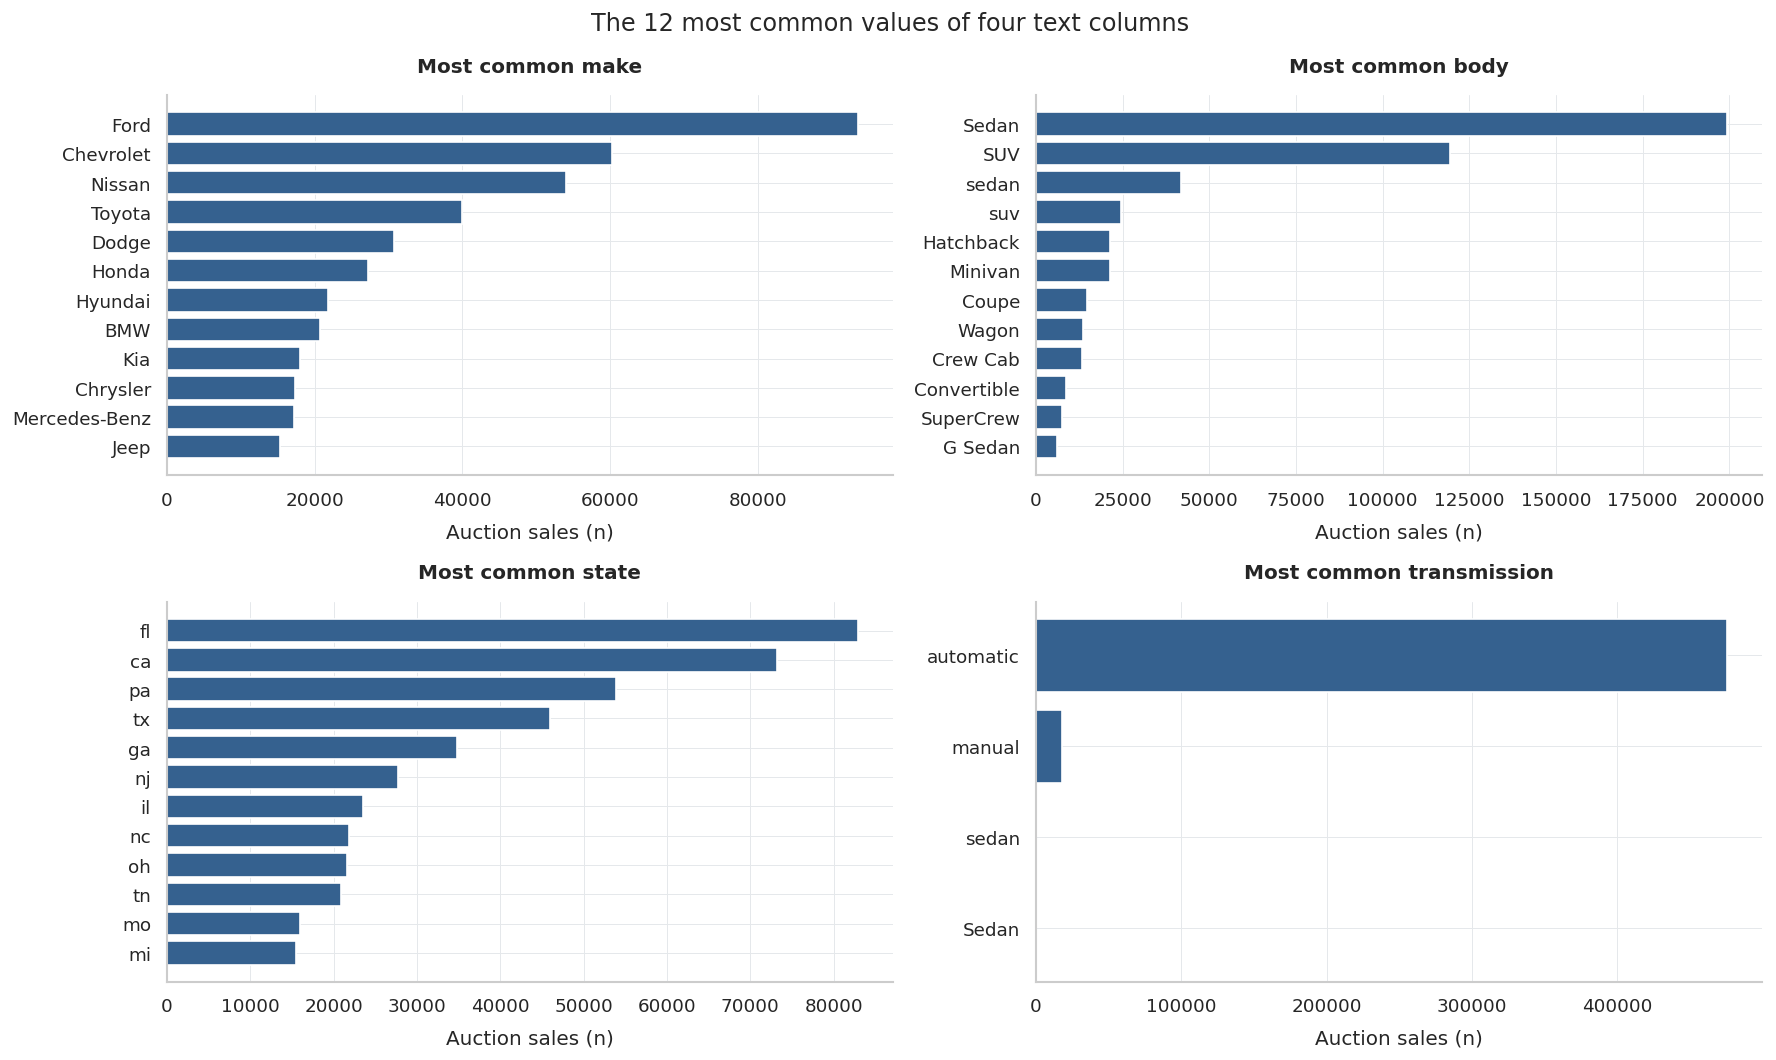

In [26]:
TOP_N = 12

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, column in zip(axes.ravel(), ["make", "body", "state", "transmission"], strict=True):
    top_values = cars[column].value_counts().head(TOP_N)
    ax.barh(top_values.index, top_values.values, color=BLUE)
    ax.invert_yaxis()  # most common on top
    ax.set_title(f"Most common {column}")
    ax.set_xlabel("Auction sales (n)")

fig.suptitle(f"The {TOP_N} most common values of four text columns")
plt.tight_layout()
plt.show()

**The raw labels are messy:**
- `body` has both `Sedan` and `sedan`.
- `transmission` contains body styles (`sedan`, `Sedan`), so a few rows look shifted.

**Is it just `body`?** The next table checks every text column: how many labels it has as written vs. once case and spaces are ignored.

*Nothing is changed here. These checks only count; the data stays exactly as recorded. Lowercasing is a Stage 4 step.*

,labels_as_written,labels_ignoring_case,labels_merged
column,,,
model,973,851,122
trim,1963,1888,75
body,87,46,41
make,96,66,30
transmission,4,3,1
state,64,64,0
color,46,46,0
interior,17,17,0
seller,14263,14263,0


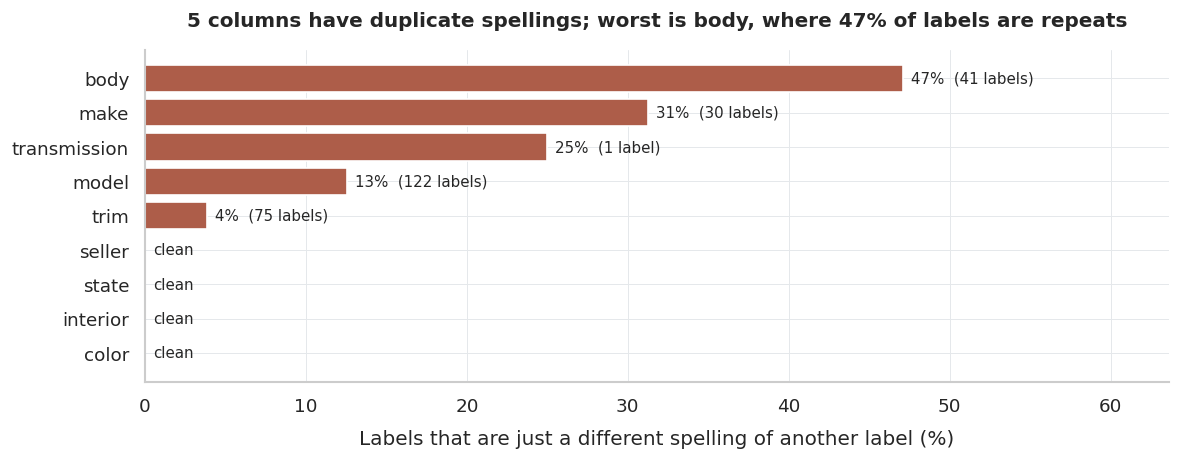

In [27]:
# How many distinct labels does each column lose once case and stray spaces are ignored?
casing_rows = []
for column in categorical_columns:
    labels = cars[column].dropna().astype(str)
    labels_as_written = labels.nunique()
    labels_ignoring_case = labels.str.strip().str.lower().nunique()
    casing_rows.append(
        {
            "column": column,
            "labels_as_written": labels_as_written,
            "labels_ignoring_case": labels_ignoring_case,
            "labels_merged": labels_as_written - labels_ignoring_case,
        }
    )

casing_table = pd.DataFrame(casing_rows).set_index("column")
display(casing_table.sort_values("labels_merged", ascending=False))

# Chart: what share of each column's labels are just another spelling of an existing label.
casing_table["merged_pct"] = (
    100 * casing_table["labels_merged"] / casing_table["labels_as_written"]
)
merged_pct = casing_table["merged_pct"].sort_values()
worst_column = merged_pct.idxmax()

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(
    merged_pct.index,
    merged_pct.values,
    color=[RUST if pct > 0 else LIGHT_GRAY for pct in merged_pct],
)
for position, column in enumerate(merged_pct.index):
    merged = casing_table.loc[column, "labels_merged"]
    label = (
        f"{merged_pct[column]:.0f}%  ({merged} label{'s' if merged != 1 else ''})"
        if merged
        else "clean"
    )
    ax.text(merged_pct[column] + 0.5, position, label, va="center", fontsize=9)
ax.set_xlim(0, merged_pct.max() * 1.35)
ax.set_xlabel("Labels that are just a different spelling of another label (%)")
ax.set_title(
    f"{merged_pct.gt(0).sum()} columns have duplicate spellings; worst is {worst_column}, "
    f"where {merged_pct.max():.0f}% of labels are repeats"
)
plt.tight_layout()
plt.show()

**Takeaway: four columns spell the same thing more than one way.** `model`, `trim`, `body` and `make` all lose labels once case is ignored.

- **Why it matters:** a model treats `Sedan` and `sedan` as two unrelated things.
- **And it gets worse over time:** early sales say `Sedan`, late sales say `sedan`, so the test sales look "new" to a model trained on early ones (Section 10 shows this).
- **Fix in Stage 4:** lowercase and trim every text column before encoding.

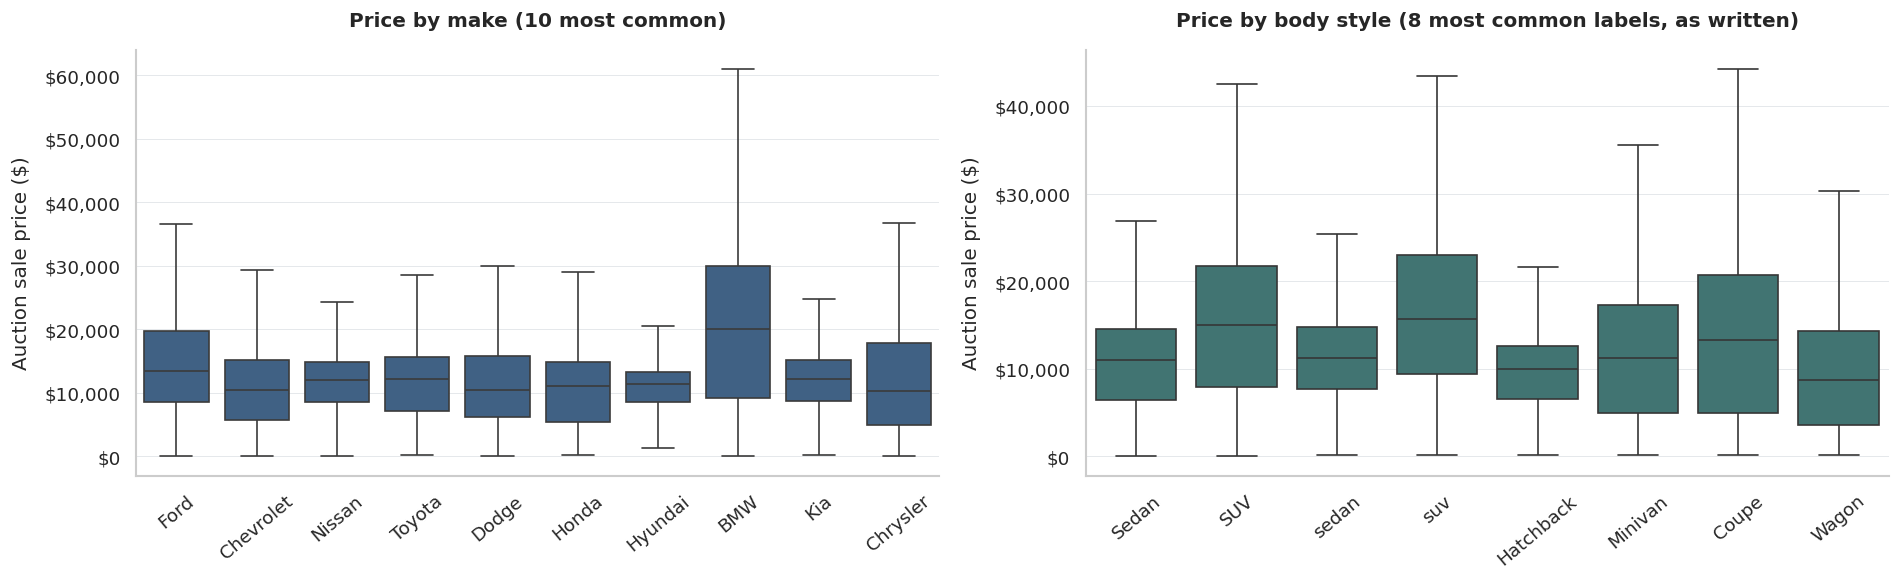

In [28]:
# Both panels are ordered by number of sales, most common first, like the bar charts above.
top_makes = cars["make"].value_counts().head(10).index
top_bodies = cars["body"].value_counts().head(8).index

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(
    data=cars[cars["make"].isin(top_makes)],
    x="make",
    y="sellingprice",
    order=top_makes,
    showfliers=False,
    color=BLUE,
    ax=axes[0],
)
axes[0].set_title("Price by make (10 most common)")

sns.boxplot(
    data=cars[cars["body"].isin(top_bodies)],
    x="body",
    y="sellingprice",
    order=top_bodies,
    showfliers=False,
    color=TEAL,
    ax=axes[1],
)
axes[1].set_title("Price by body style (8 most common labels, as written)")

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Auction sale price ($)")
    ax.tick_params(axis="x", rotation=40)
    format_dollar_axis(ax)

plt.tight_layout()
plt.show()

**Takeaway: the number of distinct values decides how we encode each column.**

| Columns | Distinct values | Encoding |
|---|---|---|
| `body`, `transmission`, `state` | small | one-hot |
| `make` | borderline | one-hot or embedding |
| `model`, `trim`, `seller` | hundreds to thousands | learned embeddings in the neural network |

`seller` is big but worth keeping: different sellers may sell different kinds of cars, so it could explain some of MMR's error. Section 7 looks.

## 6. MMR as a benchmark

In [29]:
# Compare every sale with its MMR guide value. A positive error means the car sold above guide.
benchmark = cars.dropna(subset=["sellingprice", "mmr"]).copy()
benchmark["error"] = benchmark["sellingprice"] - benchmark["mmr"]
benchmark["abs_error"] = benchmark["error"].abs()
benchmark["pct_error"] = 100 * benchmark["error"] / benchmark["mmr"]

total_ratio = benchmark["sellingprice"].sum() / benchmark["mmr"].sum()

print(f"Auction sales compared:   {len(benchmark):,}")
print(f"Mean absolute error:      ${benchmark['abs_error'].mean():,.0f}")
print(f"Median absolute error:    ${benchmark['abs_error'].median():,.0f}")
print(f"Mean signed error:        ${benchmark['error'].mean():,.0f}")
print(f"Total sold / total MMR:   {total_ratio:.1%}")
print(f"Sold above MMR:           {(benchmark['error'] > 0).mean():.1%}")
print(f"Sold below MMR:           {(benchmark['error'] < 0).mean():.1%}")
print()
for threshold in [500, 1_000, 2_000, 5_000]:
    share_missed = (benchmark["abs_error"] > threshold).mean()
    print(f"Off by more than ${threshold:,}: {share_missed:.1%} of sales")

Auction sales compared:   558,799
Mean absolute error:      $1,087
Median absolute error:    $700
Mean signed error:        $-158
Total sold / total MMR:   98.9%
Sold above MMR:           46.7%
Sold below MMR:           51.3%

Off by more than $500: 60.8% of sales
Off by more than $1,000: 36.6% of sales
Off by more than $2,000: 13.5% of sales
Off by more than $5,000: 1.7% of sales


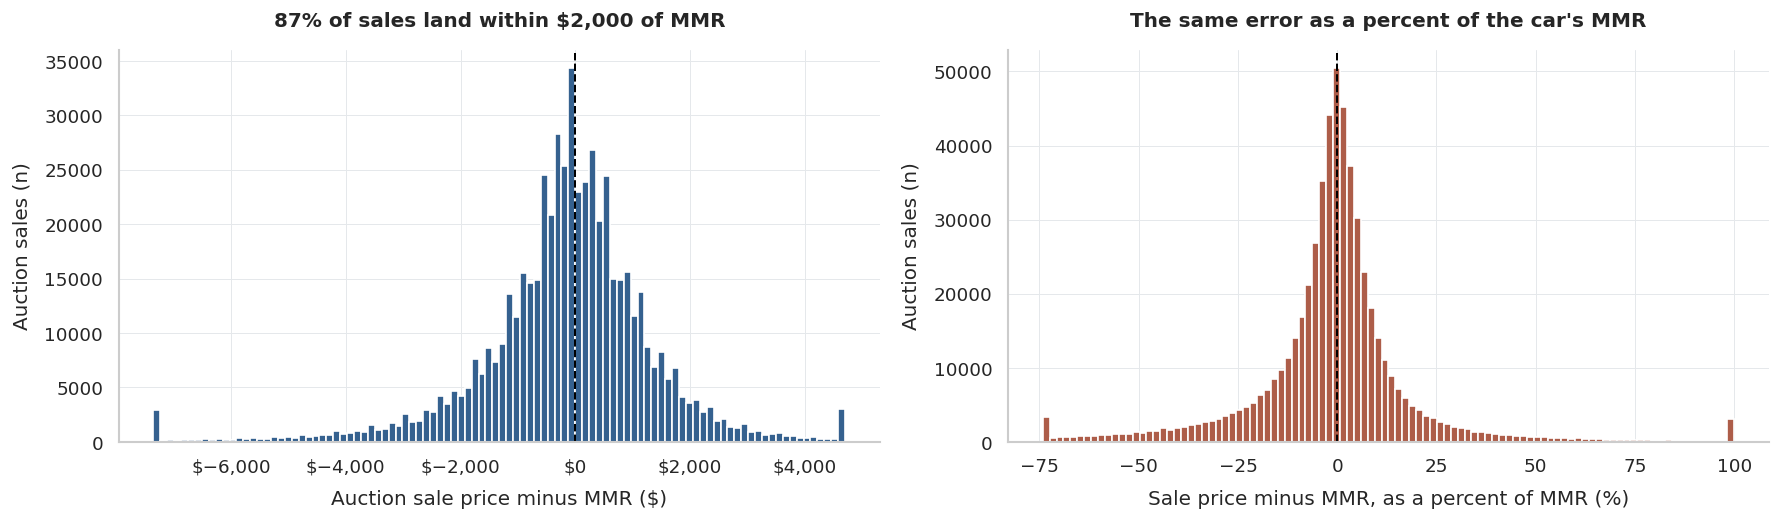

In [30]:
# Clip to the 0.5th-99.5th percentiles so the long tails don't flatten the histograms.
# The clipped values pile up in the two edge bins.
dollar_low, dollar_high = benchmark["error"].quantile([0.005, 0.995])
pct_low, pct_high = benchmark["pct_error"].quantile([0.005, 0.995])
share_within_2000 = (benchmark["abs_error"] <= 2_000).mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

axes[0].hist(
    benchmark["error"].clip(dollar_low, dollar_high),
    bins=100,
    color=BLUE,
    edgecolor="white",
)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1.2)
axes[0].set_xlabel("Auction sale price minus MMR ($)")
axes[0].set_ylabel("Auction sales (n)")
axes[0].set_title(f"{share_within_2000:.0%} of sales land within $2,000 of MMR")
format_dollar_axis(axes[0], which="x")

axes[1].hist(
    benchmark["pct_error"].clip(pct_low, pct_high), bins=100, color=RUST, edgecolor="white"
)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Sale price minus MMR, as a percent of MMR (%)")
axes[1].set_ylabel("Auction sales (n)")
axes[1].set_title("The same error as a percent of the car's MMR")

plt.tight_layout()
plt.show()

To keep the long tails from flattening the histograms, values beyond the 0.5th and 99.5th percentiles are drawn in the two edge bins.

,auction_sales,mean_abs_error,median_mmr,error_pct_of_median_mmr
mmr_band,,,,
cheapest 20%,111978,786.3,3075.0,25.6
20–40%,112056,1033.6,8475.0,12.2
40–60%,111523,969.6,12300.0,7.9
60–80%,112397,1121.3,16750.0,6.7
priciest 20%,110845,1525.7,25600.0,6.0


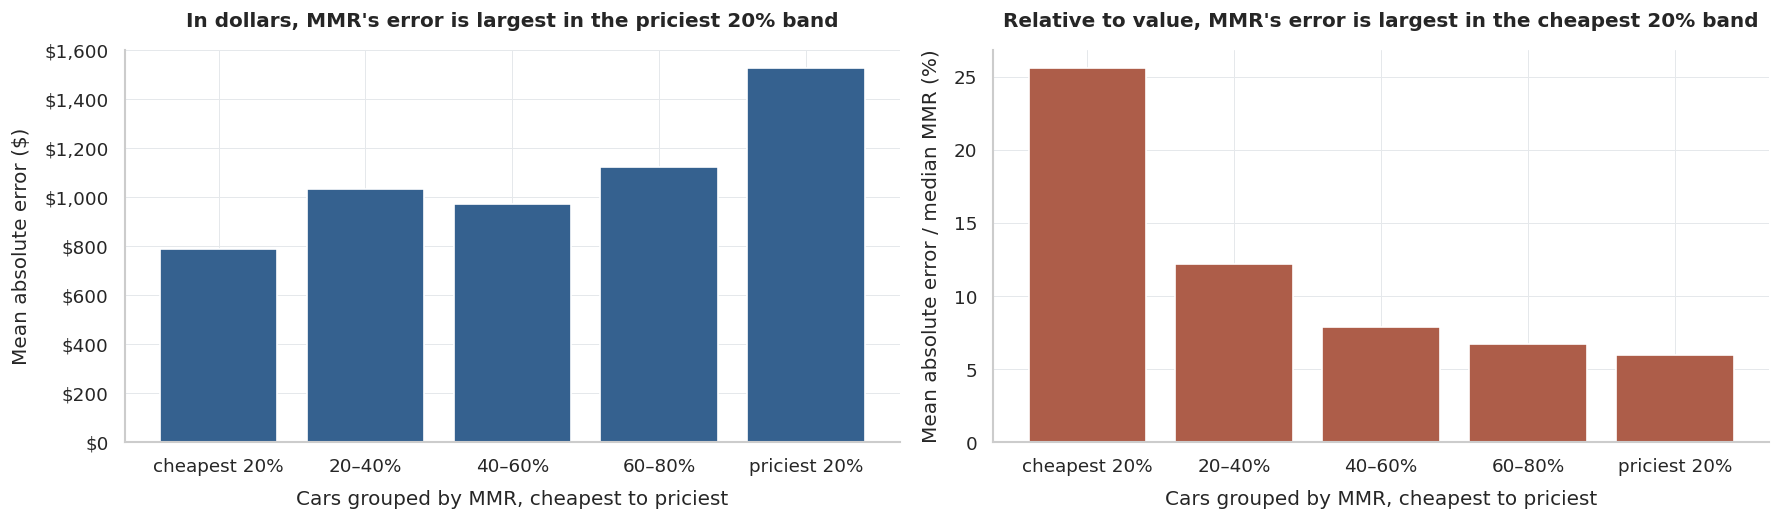

In [31]:
# Five equal-sized groups of cars, from cheapest to most expensive by MMR.
band_labels = ["cheapest 20%", "20–40%", "40–60%", "60–80%", "priciest 20%"]
benchmark["mmr_band"] = pd.qcut(benchmark["mmr"], q=5, labels=band_labels)

by_band = benchmark.groupby("mmr_band", observed=True).agg(
    auction_sales=("abs_error", "size"),
    mean_abs_error=("abs_error", "mean"),
    median_mmr=("mmr", "median"),
)
# Each band's average dollar error divided by its typical MMR.
by_band["error_pct_of_median_mmr"] = 100 * by_band["mean_abs_error"] / by_band["median_mmr"]
display(by_band.round(1))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

axes[0].bar(by_band.index.astype(str), by_band["mean_abs_error"], color=BLUE)
axes[0].set_ylabel("Mean absolute error ($)")
axes[0].set_title(
    f"In dollars, MMR's error is largest in the {by_band['mean_abs_error'].idxmax()} band"
)
format_dollar_axis(axes[0])

axes[1].bar(by_band.index.astype(str), by_band["error_pct_of_median_mmr"], color=RUST)
axes[1].set_ylabel("Mean absolute error / median MMR (%)")
axes[1].set_title(
    f"Relative to value, MMR's error is largest in the {by_band['error_pct_of_median_mmr'].idxmax()} band"
)

for ax in axes:
    ax.set_xlabel("Cars grouped by MMR, cheapest to priciest")

plt.tight_layout()
plt.show()

Each band is one fifth of the cars, ordered from cheapest to most expensive by MMR. The right panel divides each band's average dollar error by that band's typical MMR, so it shows the error relative to the car's value.

### Condition codes, all in one view
Four questions about `condition`, answered side by side. Read them in order:
1. **How common is each code?**
2. **What do those cars sell for?**
3. **How far off is MMR?**
4. **Which way is MMR off?**

HOW TO READ THE FOUR CHARTS (each bar = one condition code)
  1. Sales:     how many cars had that code. Codes come in two clumps (1-5 and ~19-49).
  2. Price:     the typical sale price for that code.
  3. Error size: how far off MMR was, on average (taller = worse).
  4. Direction: red = cars usually sold UNDER MMR, teal = OVER.
  Furthest under: code 1, typically $1,650 under.
  Furthest over:  code 5, typically $400 over.


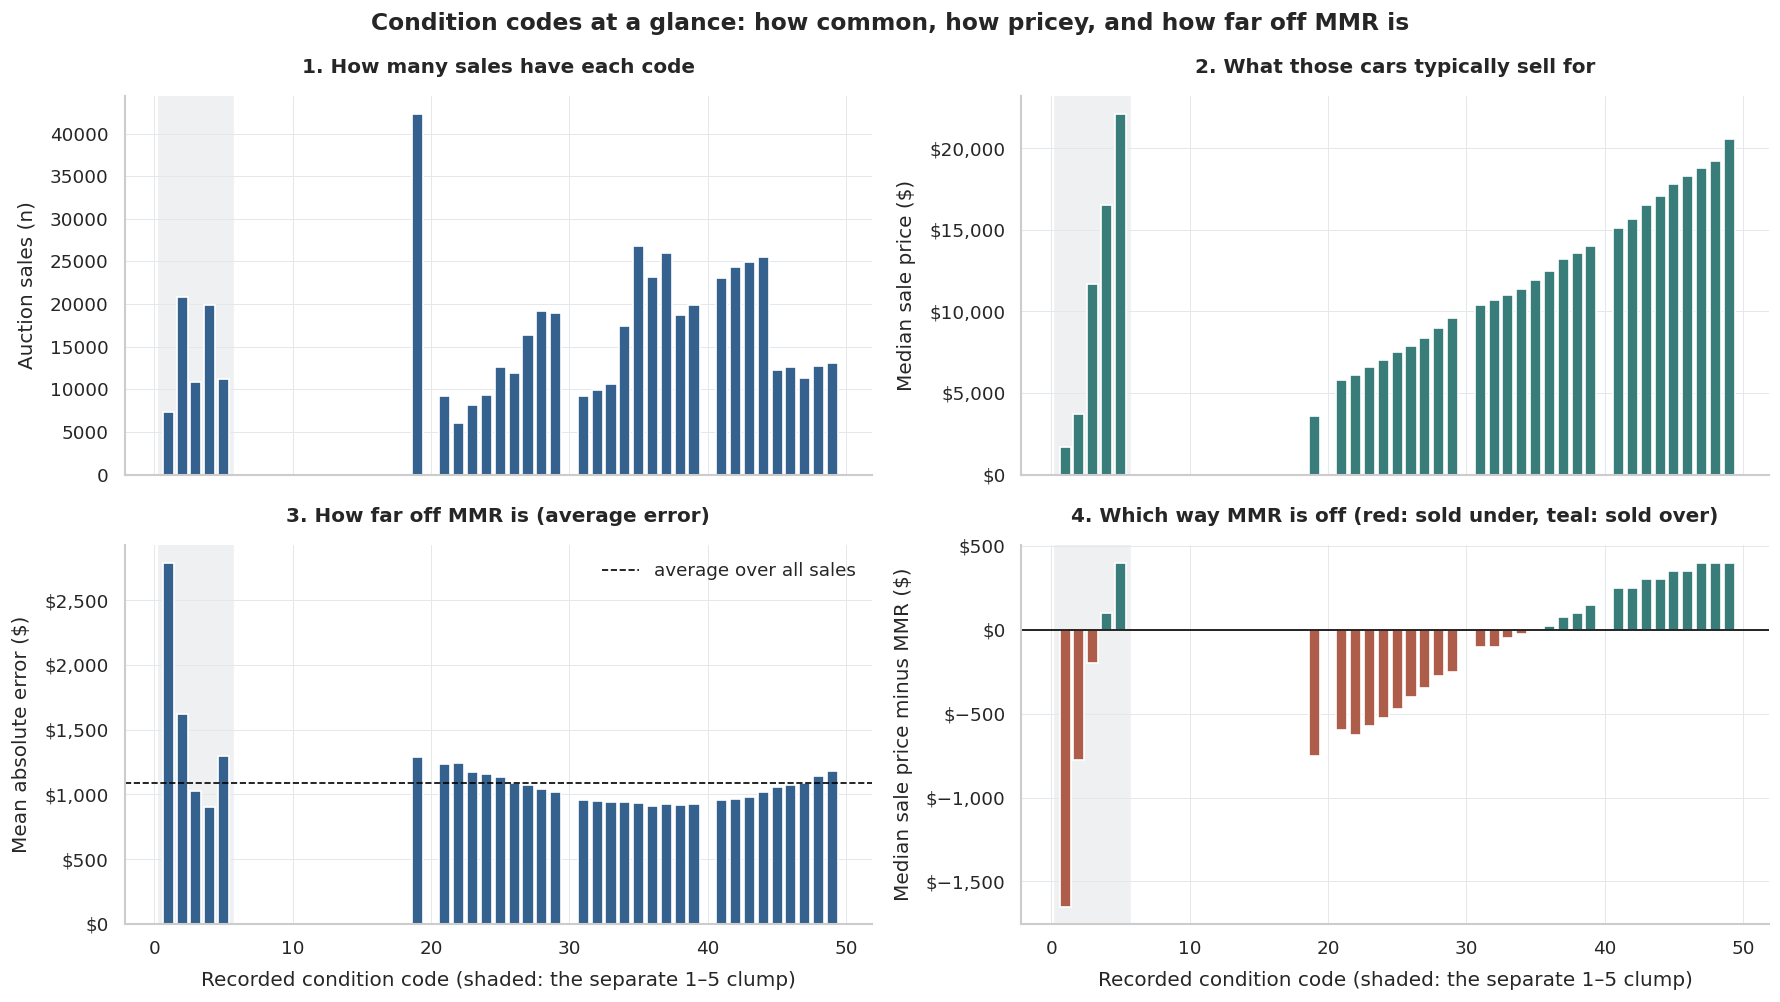

,mean_abs_error,auction_sales
condition_range,,
1–10,"$1,396","70,100"
11–20,"$1,310","43,562"
21–29,"$1,103","111,695"
30–39,$930,"161,675"
40–49,"$1,030","159,973"


In [32]:
# One row per condition code with 500+ sales. 500 is our judgment call, not a magic number.
MIN_SALES_PER_CODE = 500

by_code = (
    benchmark.dropna(subset=["condition"])
    .groupby("condition")
    .agg(
        sales=("error", "size"),
        median_price=("sellingprice", "median"),
        mean_abs_error=("abs_error", "mean"),
        median_signed_error=("error", "median"),
    )
)
by_code = by_code[by_code["sales"] >= MIN_SALES_PER_CODE]

worst_code = by_code["median_signed_error"].idxmin()
best_code = by_code["median_signed_error"].idxmax()
print("HOW TO READ THE FOUR CHARTS (each bar = one condition code)")
print(
    "  1. Sales:     how many cars had that code. Codes come in two clumps (1-5 and ~19-49)."
)
print("  2. Price:     the typical sale price for that code.")
print("  3. Error size: how far off MMR was, on average (taller = worse).")
print("  4. Direction: red = cars usually sold UNDER MMR, teal = OVER.")
print(
    f"  Furthest under: code {worst_code:g}, typically ${abs(by_code.loc[worst_code, 'median_signed_error']):,.0f} under."
)
print(
    f"  Furthest over:  code {best_code:g}, typically ${by_code.loc[best_code, 'median_signed_error']:,.0f} over."
)

fig, axes = plt.subplots(2, 2, figsize=(15, 8.5), sharex=True)
codes = by_code.index

axes[0, 0].bar(codes, by_code["sales"], color=BLUE, width=0.8)
axes[0, 0].set_title("1. How many sales have each code")
axes[0, 0].set_ylabel("Auction sales (n)")

axes[0, 1].bar(codes, by_code["median_price"], color=TEAL, width=0.8)
axes[0, 1].set_title("2. What those cars typically sell for")
axes[0, 1].set_ylabel("Median sale price ($)")
format_dollar_axis(axes[0, 1])

axes[1, 0].bar(codes, by_code["mean_abs_error"], color=BLUE, width=0.8)
axes[1, 0].axhline(
    benchmark["abs_error"].mean(),
    color="black",
    linestyle="--",
    linewidth=1,
    label="average over all sales",
)
axes[1, 0].set_title("3. How far off MMR is (average error)")
axes[1, 0].set_ylabel("Mean absolute error ($)")
axes[1, 0].legend(loc="upper right")
format_dollar_axis(axes[1, 0])

direction_colors = np.where(by_code["median_signed_error"] < 0, RUST, TEAL)
axes[1, 1].bar(codes, by_code["median_signed_error"], color=direction_colors, width=0.8)
axes[1, 1].axhline(0, color="black", linewidth=1)
axes[1, 1].set_title("4. Which way MMR is off (red: sold under, teal: sold over)")
axes[1, 1].set_ylabel("Median sale price minus MMR ($)")
format_dollar_axis(axes[1, 1])

# Shade the 1-5 clump on every panel; the documentation we have doesn't define the codes.
for ax in axes.ravel():
    ax.axvspan(0.3, 5.7, color="#EEF0F2", zorder=0)
for ax in axes[1]:
    ax.set_xlabel("Recorded condition code (shaded: the separate 1–5 clump)")

fig.suptitle(
    "Condition codes at a glance: how common, how pricey, and how far off MMR is",
    fontsize=14,
    fontweight="semibold",
)
plt.tight_layout()
plt.show()

# The five-range summary quoted in the text below.
with_condition = benchmark.dropna(subset=["condition"]).copy()
with_condition["condition_range"] = pd.cut(with_condition["condition"], bins=5)
range_labels = {
    interval: f"{int(np.ceil(interval.left))}–{int(np.floor(interval.right))}"
    for interval in with_condition["condition_range"].cat.categories
}
with_condition["condition_range"] = with_condition["condition_range"].map(range_labels)
by_range = (
    with_condition.groupby("condition_range", observed=True)["abs_error"]
    .agg(mean_abs_error="mean", auction_sales="size")
    .reindex(range_labels.values())
)
display(by_range.style.format({"mean_abs_error": "${:,.0f}", "auction_sales": "{:,}"}))

**Takeaway: low condition codes sell under MMR; high codes sell over it.**

| Condition code | Typical sale vs MMR |
|---|---|
| 1 | about \$1,650 **under** |
| 20s | \$250 to \$750 **under** |
| 40s | a few hundred dollars **over** |

- The small 1–5 group shows the same low-to-high pattern on its own.
- **Careful:** this is a pattern, not proof that MMR ignores condition. Cars with different codes also differ in make, age and sale date.
- **So what:** `condition` is worth testing as a model input. Stage 4 checks whether it actually improves predictions on held-out sales.

### The main finding: MMR is right on average, but often wrong for a single car

**1. On average, the errors cancel out.**
- All cars together sold for **98.9%** of their combined MMR; the average car sold just **\$158 under**.
- That's only because cars sold above MMR offset cars sold below it.

**2. Car by car, MMR's error is large.**
- Typical error: **\$700** (median). Average error: **\$1,087**.
- **61%** of cars sold more than \$500 away from MMR, **37%** more than \$1,000 away, **14%** more than \$2,000 away.

**3. The error isn't spread evenly.**

| Group | Average error |
|---|---|
| Cheapest fifth of cars | \$786, or **26%** of the car's value |
| Priciest fifth of cars | **\$1,526**, or 6% of the car's value |
| Condition codes 1–10 | **\$1,396** |
| Condition codes 30–39 | \$930 |

**Caveat:** the file doesn't say when each MMR value was published, so we can't be sure a buyer saw this exact number before bidding.

## 7. How does MMR error vary by seller?
Mean absolute error measures the size of MMR's misses. Mean signed error shows whether a seller's cars tend to sell above or below guide in this file. First look at all eligible sellers, then at the largest observed gaps.


In [33]:
# Skip sellers with fewer than 200 sales; their averages bounce around too much to compare.
MIN_SALES_PER_SELLER = 200

seller_stats = benchmark.groupby("seller").agg(
    sales=("abs_error", "size"),
    mean_abs_error=("abs_error", "mean"),
    mean_signed_error=("error", "mean"),
    median_mmr=("mmr", "median"),
)
big_sellers = seller_stats[seller_stats["sales"] >= MIN_SALES_PER_SELLER]
share_of_sales = big_sellers["sales"].sum() / len(benchmark)

print(f"Sellers in the data:                 {len(seller_stats):,}")
print(f"Sellers with {MIN_SALES_PER_SELLER}+ sales:             {len(big_sellers):,}")
print(f"Share of all sales they account for:    {share_of_sales:.1%}")
print()
print(f"Lowest mean absolute error:   ${big_sellers['mean_abs_error'].min():,.0f}")
print(f"Median mean absolute error:   ${big_sellers['mean_abs_error'].median():,.0f}")
print(f"Highest mean absolute error:  ${big_sellers['mean_abs_error'].max():,.0f}")

Sellers in the data:                 14,260
Sellers with 200+ sales:             313
Share of all sales they account for:    69.5%

Lowest mean absolute error:   $329
Median mean absolute error:   $1,089
Highest mean absolute error:  $6,961


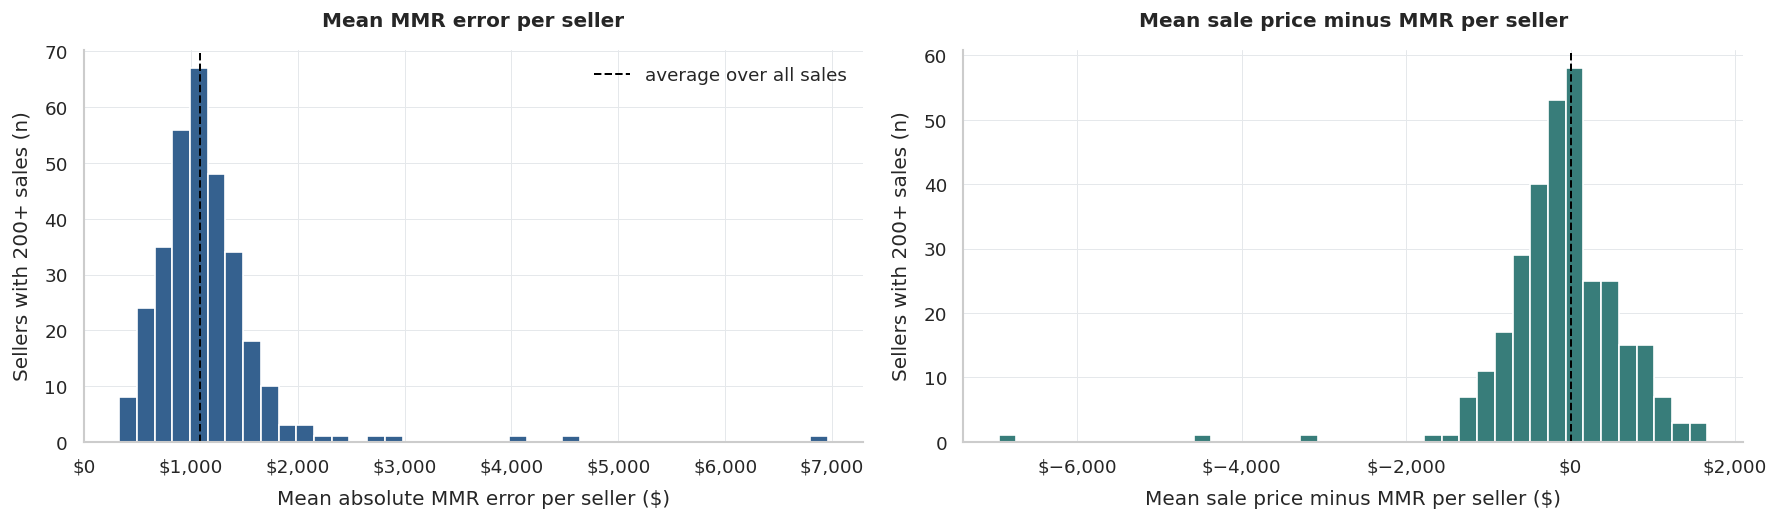

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

axes[0].hist(big_sellers["mean_abs_error"], bins=40, color=BLUE, edgecolor="white")
axes[0].axvline(
    benchmark["abs_error"].mean(),
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="average over all sales",
)
axes[0].set_xlabel("Mean absolute MMR error per seller ($)")
axes[0].set_title("Mean MMR error per seller")
axes[0].legend()
format_dollar_axis(axes[0], which="x")

axes[1].hist(big_sellers["mean_signed_error"], bins=40, color=TEAL, edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Mean sale price minus MMR per seller ($)")
axes[1].set_title("Mean sale price minus MMR per seller")
format_dollar_axis(axes[1], which="x")

for ax in axes:
    ax.set_ylabel(f"Sellers with {MIN_SALES_PER_SELLER}+ sales (n)")

plt.tight_layout()
plt.show()



### Which sellers sit at the ends of that distribution?
**The largest observed gaps are below guide.** Here are the five lowest and five highest seller averages, using the same 200-record cutoff. The zero line is MMR; each label includes the number of observed auction records.


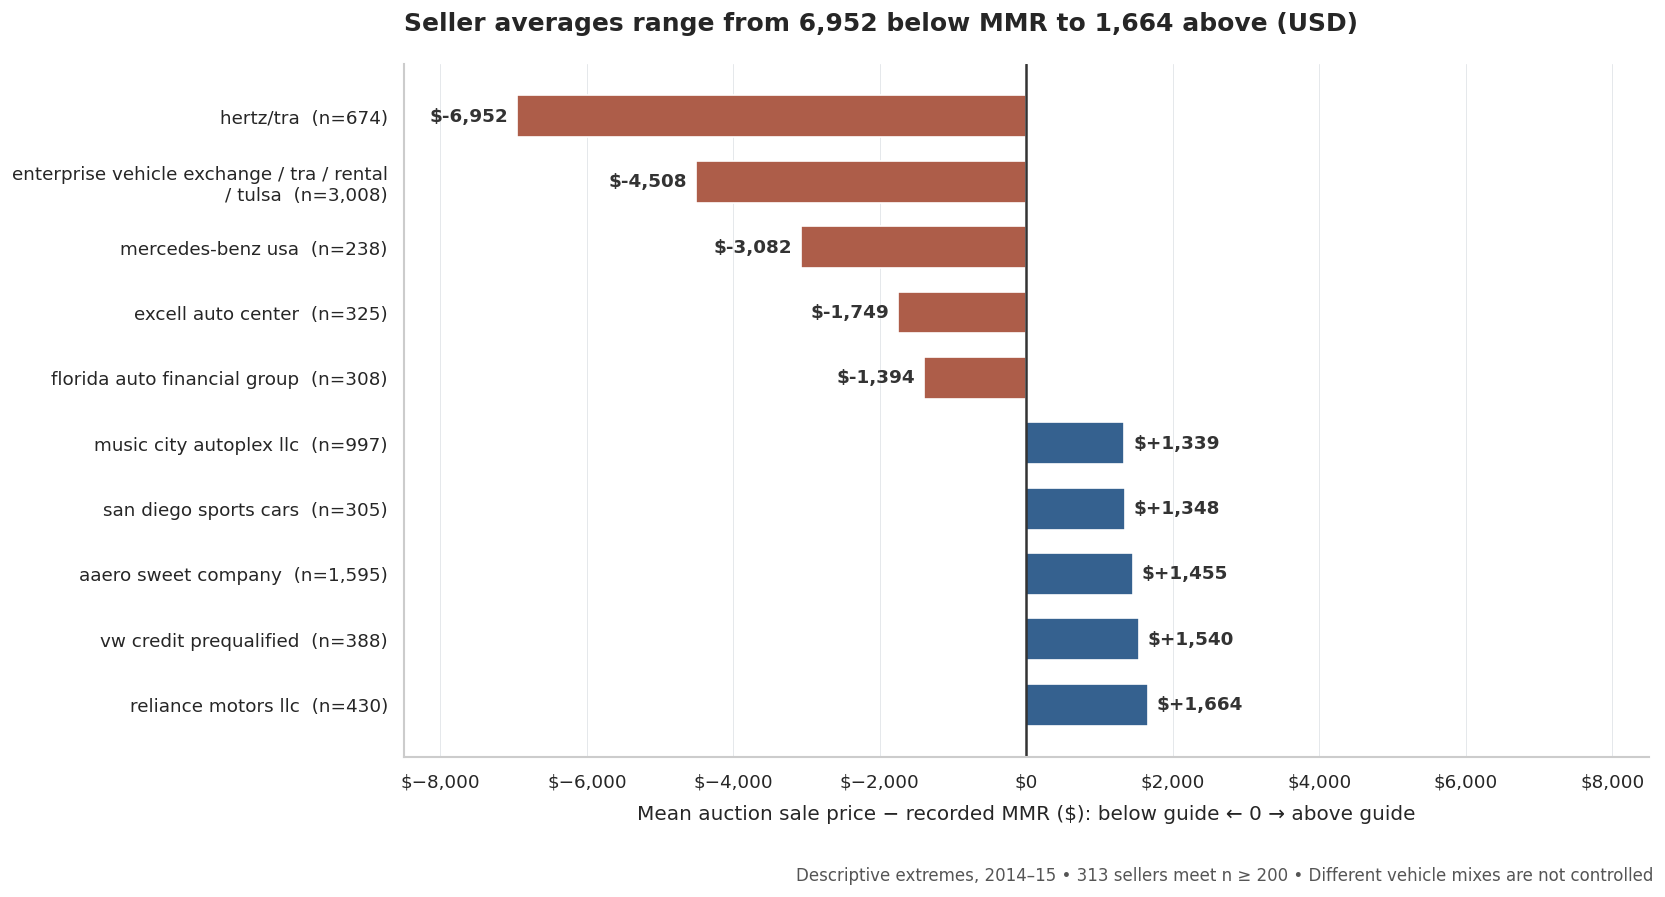

In [35]:
from textwrap import fill

seller_extremes = pd.concat([
    big_sellers.nsmallest(5, "mean_signed_error"),
    big_sellers.nlargest(5, "mean_signed_error"),
]).sort_values("mean_signed_error")
labels = [fill(name, width=43) + f"  (n={count:,})"
          for name, count in zip(seller_extremes.index, seller_extremes["sales"])]
gaps = seller_extremes["mean_signed_error"]
colors = [RUST if value < 0 else BLUE for value in gaps]

fig, ax = plt.subplots(figsize=(14, 7.5))
ax.barh(np.arange(len(gaps)), gaps, color=colors, height=.64)
ax.set_yticks(np.arange(len(gaps)), labels)
ax.invert_yaxis()
ax.axvline(0, color="#333333", linewidth=1.5)
for position, value in enumerate(gaps):
    offset = -120 if value < 0 else 120
    alignment = "right" if value < 0 else "left"
    ax.text(value + offset, position, f"${value:+,.0f}", va="center", ha=alignment,
            fontweight="semibold", fontsize=11, color="#333333")
limit = np.ceil(gaps.abs().max() / 1000) * 1000 + 1500
ax.set_xlim(-limit, limit)
ax.xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
ax.grid(axis="y", visible=False)
ax.set_xlabel("Mean auction sale price − recorded MMR ($): below guide ← 0 → above guide")
ax.set_title(
    f"Seller averages range from {abs(gaps.min()):,.0f} below MMR to {gaps.max():,.0f} above (USD)",
    loc="left", fontsize=15, pad=20,
)
ax.title.set_parse_math(False)
fig.text(.99, .01,
         f"Descriptive extremes, 2014–15 • {len(big_sellers):,} sellers meet n ≥ {MIN_SALES_PER_SELLER} • Different vehicle mixes are not controlled",
         ha="right", fontsize=10, color="#555555")
plt.tight_layout(rect=[0, .05, 1, 1])
plt.show()


**Takeaway: seller groups have different observed price gaps, especially below MMR.**
- There are **313 sellers with 200+ records**, covering about 70% of benchmark records. Their mean absolute errors range from **$329 to $6,961**.
- The chart's signed gap shows direction; the histograms also show error size. A near-zero average signed gap can still hide large errors in both directions.
- Differences in vehicle condition, age, price band and sale timing may explain part of the spread. This chart does not establish a seller effect or a profit opportunity.

`seller` remains a proposed Stage 4 input to test. It was excluded from the completed historical price model.


### Where were the cars sold?
Each square is one state, placed roughly where it sits on a US map (all states drawn the same size, so small ones stay visible). Left: how many sales. Right: MMR's average error there.

Not on the map (5 codes, 8,401 sales): ON 3,442, PR 2,725, QC 1,245, AB 928, NS 61


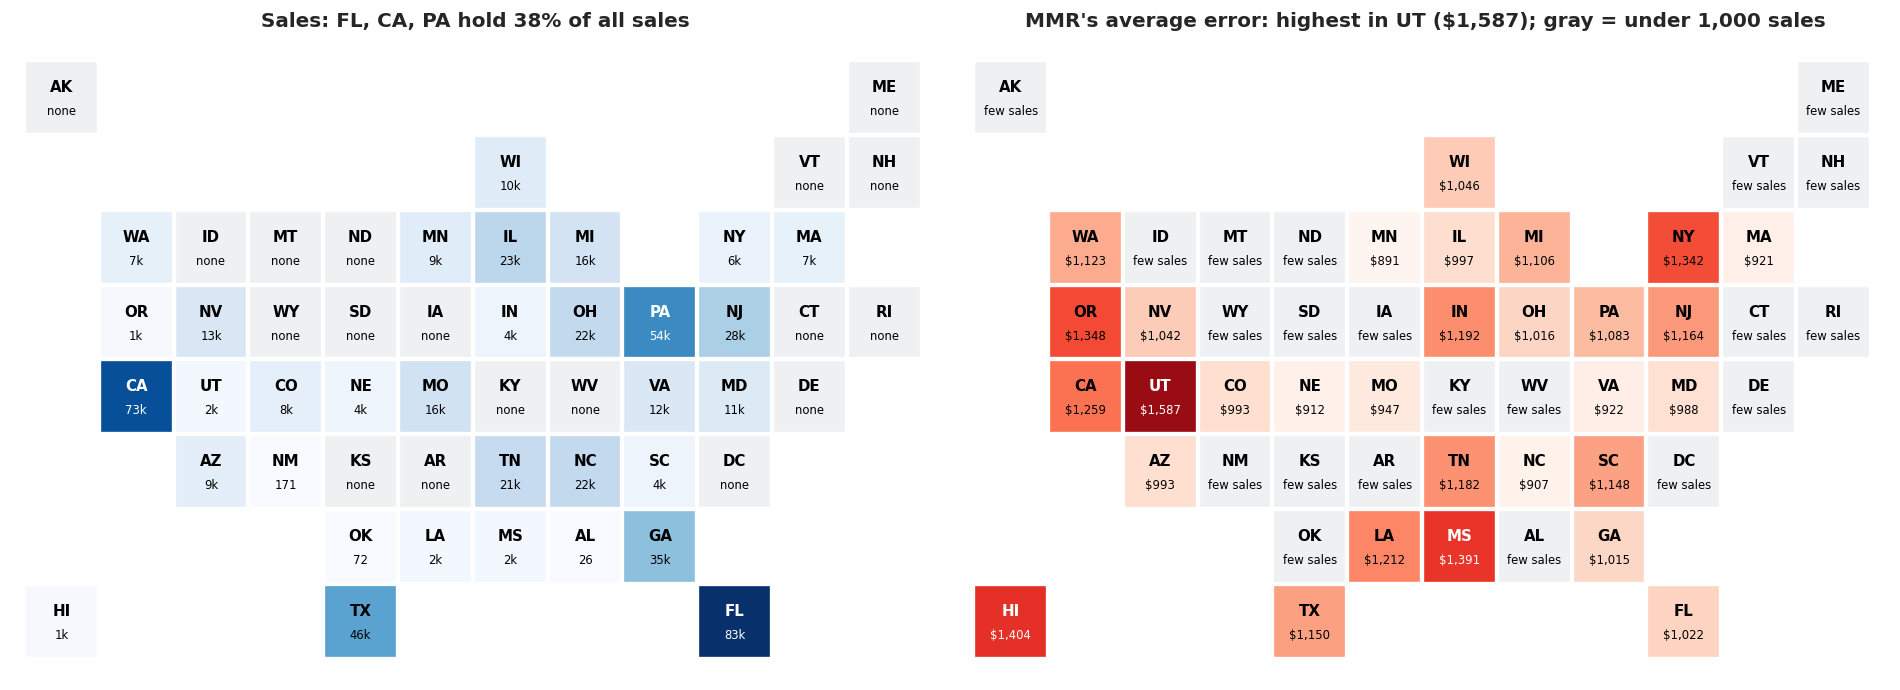

In [36]:
# Tile-grid map: (column, row) for each state, roughly matching US geography.
STATE_TILES = {
    "AK": (0, 0),
    "ME": (11, 0),
    "WI": (6, 1),
    "VT": (10, 1),
    "NH": (11, 1),
    "WA": (1, 2),
    "ID": (2, 2),
    "MT": (3, 2),
    "ND": (4, 2),
    "MN": (5, 2),
    "IL": (6, 2),
    "MI": (7, 2),
    "NY": (9, 2),
    "MA": (10, 2),
    "OR": (1, 3),
    "NV": (2, 3),
    "WY": (3, 3),
    "SD": (4, 3),
    "IA": (5, 3),
    "IN": (6, 3),
    "OH": (7, 3),
    "PA": (8, 3),
    "NJ": (9, 3),
    "CT": (10, 3),
    "RI": (11, 3),
    "CA": (1, 4),
    "UT": (2, 4),
    "CO": (3, 4),
    "NE": (4, 4),
    "MO": (5, 4),
    "KY": (6, 4),
    "WV": (7, 4),
    "VA": (8, 4),
    "MD": (9, 4),
    "DE": (10, 4),
    "AZ": (2, 5),
    "NM": (3, 5),
    "KS": (4, 5),
    "AR": (5, 5),
    "TN": (6, 5),
    "NC": (7, 5),
    "SC": (8, 5),
    "DC": (9, 5),
    "OK": (4, 6),
    "LA": (5, 6),
    "MS": (6, 6),
    "AL": (7, 6),
    "GA": (8, 6),
    "HI": (0, 7),
    "TX": (4, 7),
    "FL": (9, 7),
}
MIN_SALES_FOR_ERROR = (
    1_000  # fewer sales than this and a state's average error is too shaky to show
)


def draw_tile_map(ax, values, colormap, label_format, missing_text):
    """Color each state's tile by its value; states with no value stay gray."""
    known = values.dropna()
    norm = plt.Normalize(known.min(), known.max())
    cmap = plt.get_cmap(colormap)
    for state, (column, row) in STATE_TILES.items():
        value = values.get(state)
        has_value = value is not None and pd.notna(value)
        color = cmap(norm(value)) if has_value else "#EEF0F2"
        ax.add_patch(plt.Rectangle((column, -row), 0.92, 0.92, color=color))
        dark_tile = has_value and norm(value) > 0.6
        text_color = "white" if dark_tile else "black"
        ax.text(
            column + 0.46,
            -row + 0.6,
            state,
            ha="center",
            va="center",
            fontsize=9,
            fontweight="semibold",
            color=text_color,
        )
        ax.text(
            column + 0.46,
            -row + 0.28,
            label_format(value) if has_value else missing_text,
            ha="center",
            va="center",
            fontsize=7,
            color=text_color,
        )
    ax.set_xlim(-0.2, 12.2)
    ax.set_ylim(-7.3, 1.1)
    ax.set_aspect("equal")
    ax.axis("off")


state_codes = benchmark["state"].str.upper()
sales_by_state = state_codes.value_counts()
error_by_state = benchmark.groupby(state_codes)["abs_error"].mean()
error_by_state = error_by_state[
    sales_by_state.reindex(error_by_state.index) >= MIN_SALES_FOR_ERROR
]

top_states = sales_by_state[sales_by_state.index.isin(STATE_TILES)].head(3)
top_share = top_states.sum() / len(benchmark)
worst_state = error_by_state[error_by_state.index.isin(STATE_TILES)].idxmax()

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
draw_tile_map(
    axes[0],
    sales_by_state,
    "Blues",
    lambda n: f"{n / 1000:.0f}k" if n >= 1000 else f"{n:,}",
    "none",
)
axes[0].set_title(f"Sales: {', '.join(top_states.index)} hold {top_share:.0%} of all sales")
draw_tile_map(axes[1], error_by_state, "Reds", lambda e: f"${e:,.0f}", "few sales")
axes[1].set_title(
    f"MMR's average error: highest in {worst_state} "
    f"(${error_by_state[worst_state]:,.0f}); gray = under {MIN_SALES_FOR_ERROR:,} sales"
)
plt.tight_layout()
plt.show()

# Codes that aren't on the US tile map (Canadian provinces, Puerto Rico) are listed, not dropped.
other_codes = sales_by_state[~sales_by_state.index.isin(STATE_TILES)]
print(
    f"Not on the map ({len(other_codes)} codes, {other_codes.sum():,} sales): "
    + ", ".join(f"{code} {count:,}" for code, count in other_codes.items())
)

## 8. Calendar coverage and time-based comparisons
**Why the time charts can look odd:** most observations are in two dense blocks, surrounded by sparse periods and unobserved dates. Large empty spans compress the informative part of the axis; a few-record median is unstable; changing vehicle mix and missing attributes also change aggregate prices. The charts below separate those issues.


In [37]:
def parse_sale_dates(raw_dates):
    """Preserve the calendar day written in the source; do not shift it to UTC."""
    calendar_part = raw_dates.astype("string").str.extract(
        r"^(\w{3}\s+\w{3}\s+\d{1,2}\s+\d{4})", expand=False
    )
    return pd.to_datetime(calendar_part, format="%a %b %d %Y", errors="coerce")


sale_day = parse_sale_dates(cars["saledate"])
parse_status = pd.Series("parsed", index=cars.index)
parse_status[cars["saledate"].isna()] = "missing source date"
parse_status[cars["saledate"].notna() & sale_day.isna()] = "malformed source date"
display(parse_status.value_counts().rename_axis("status").to_frame("raw records"))

dated = cars.loc[sale_day.notna()].copy()
dated["sale_dt"] = sale_day.loc[dated.index]
first_sale = dated["sale_dt"].min()
last_sale = dated["sale_dt"].max()
calendar_days = pd.date_range(first_sale, last_sale, freq="D")
daily_records = dated.groupby("sale_dt").size().reindex(calendar_days, fill_value=0)
print(f"Source days: {first_sale:%Y-%m-%d} to {last_sale:%Y-%m-%d}, inclusive.")
print(f"{daily_records.gt(0).sum():,} observed days / {len(calendar_days):,} calendar days.")
print(f"{daily_records.eq(0).sum():,} days have no records in this file; market activity is unknown.")


Source days: 2014-01-01 to 2015-07-21, inclusive.
172 observed days / 567 calendar days.
395 days have no records in this file; market activity is unknown.


,raw records
status,
parsed,558799
malformed source date,26
missing source date,12


In [38]:
# Check the calendar parser against the full timestamp without changing split dates.
raw_dates = cars["saledate"].astype("string")
source_weekday = raw_dates.str.extract(r"^(\w{3})\s", expand=False)
weekday_mismatch = sale_day.notna() & source_weekday.ne(sale_day.dt.day_name().str[:3])
timestamp_text = raw_dates.str.replace(r"\s*\([^)]*\)\s*$", "", regex=True)
utc_timestamp = pd.to_datetime(
    timestamp_text, format="%a %b %d %Y %H:%M:%S GMT%z", errors="coerce", utc=True
)
utc_day = utc_timestamp.dt.tz_localize(None).dt.normalize()
shifted_day = sale_day.notna() & utc_day.notna() & sale_day.ne(utc_day)
print(f"Source weekday disagreements: {weekday_mismatch.sum():,}.")
print(f"UTC conversion would move {shifted_day.sum():,} records to another day; not applied.")
display(raw_dates.str.extract(r"(GMT[+-]\d{4})", expand=False)
        .value_counts(dropna=False).rename_axis("source offset").to_frame("records"))
# These malformed values are reported, not repaired by guessing the shifted columns.
display(raw_dates[parse_status.eq("malformed source date")].value_counts()
        .rename_axis("raw date value").to_frame("records"))


Source weekday disagreements: 0.
UTC conversion would move 4,952 records to another day; not applied.


,records
source offset,
GMT-0800,395489
GMT-0700,163310
<NA>,38


,records
raw date value,
13500,4
13600,2
12900,2
10500,1
16500,1
14300,1
8250,1
12700,1
14500,1


In [39]:
early = dated.loc[dated["sale_dt"] < "2014-12-01"]
early_by_day = early.groupby("sale_dt").size().rename("records")
display(early_by_day.to_frame())
print(f"Early-2014 records: {len(early):,}; source years and weekdays agree with parsing.")
print("Their provenance is undocumented. Keep them in the historical split; do not rewrite dates.")

empty_day = daily_records.eq(0)
gap_group = empty_day.ne(empty_day.shift()).cumsum()
gap_rows = []
for _, gap in daily_records[empty_day].groupby(gap_group):
    gap_rows.append({"first day": gap.index.min().date(),
                     "last day": gap.index.max().date(), "days": len(gap)})
calendar_gaps = pd.DataFrame(gap_rows).sort_values("days", ascending=False)
display(calendar_gaps.head(5))


Early-2014 records: 207; source years and weekdays agree with parsing.
Their provenance is undocumented. Keep them in the historical split; do not rewrite dates.


,records
sale_dt,
2014-01-01,53
2014-01-02,18
2014-01-05,3
2014-01-06,48
2014-01-07,41
2014-01-08,15
2014-01-12,21
2014-01-13,3
2014-01-14,2


,first day,last day,days
4,2014-02-15,2014-12-15,304
3,2014-01-30,2014-02-13,15
2,2014-01-16,2014-01-28,13
35,2015-07-15,2015-07-20,6
34,2015-07-11,2015-07-13,3


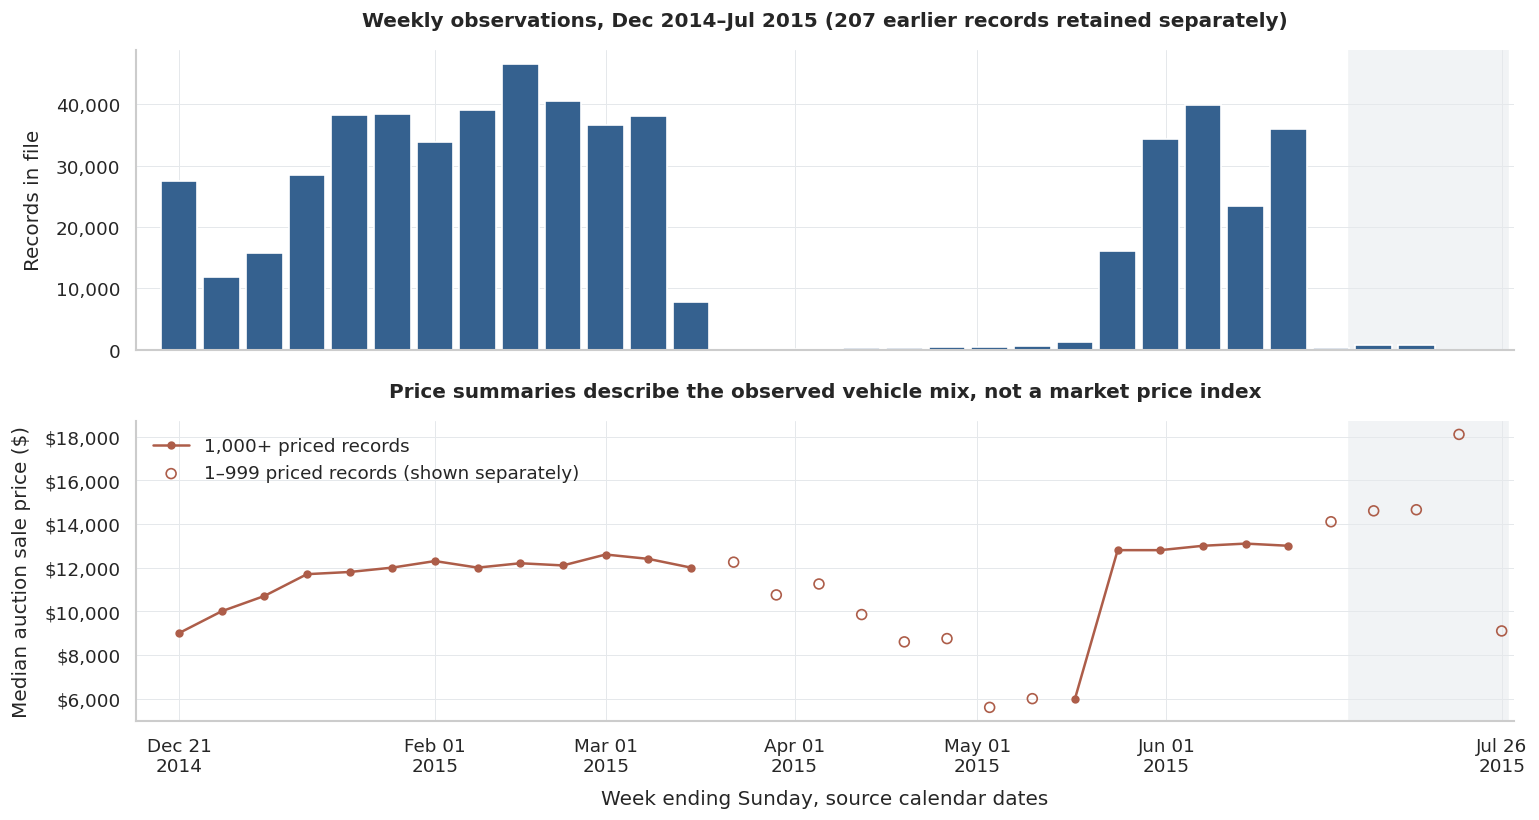

In [40]:
# Full monthly coverage first, then a focused view of the dense observation window.
MIN_SALES_PER_WEEK = 1_000  # display rule, not a statistical reliability guarantee
weekly = dated.set_index("sale_dt").resample("W-SUN").agg(
    records=("sellingprice", "size"), priced_records=("sellingprice", "count"),
    median_price=("sellingprice", "median")
)
monthly_coverage = dated.set_index("sale_dt").resample("MS").agg(
    records=("sellingprice", "size"), priced_records=("sellingprice", "count"),
    observed_days=("saledate", lambda s: s.index.normalize().nunique())
)
monthly_sales = monthly_coverage["records"]
is_busy_week = weekly["priced_records"] >= MIN_SALES_PER_WEEK
focus = weekly.loc["2014-12-01":].copy()
focus_busy = focus["priced_records"] >= MIN_SALES_PER_WEEK

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].bar(focus.index, focus["records"], width=6, color=BLUE)
axes[0].set_ylabel("Records in file")
axes[0].set_title("Weekly observations, Dec 2014–Jul 2015 (207 earlier records retained separately)")
axes[0].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axes[1].plot(focus.index, focus["median_price"].where(focus_busy),
             marker="o", markersize=4, color=RUST, label="1,000+ priced records")
quiet = focus.loc[~focus_busy & focus["priced_records"].gt(0)]
axes[1].scatter(quiet.index, quiet["median_price"], facecolors="none", edgecolors=RUST,
                s=35, label="1–999 priced records (shown separately)")
axes[1].set_ylabel("Median auction sale price ($)")
axes[1].set_xlabel("Week ending Sunday, source calendar dates")
axes[1].set_title("Price summaries describe the observed vehicle mix, not a market price index")
axes[1].legend(loc="upper left")
format_dollar_axis(axes[1])
for ax in axes:
    ax.set_xlim(pd.Timestamp("2014-12-14"), pd.Timestamp("2015-07-27"))
    ax.axvspan(pd.Timestamp("2015-07-01"), pd.Timestamp("2015-07-27"), color="#F1F3F5", zorder=0)
time_ticks = pd.to_datetime(["2014-12-21", "2015-02-01", "2015-03-01", "2015-04-01", "2015-05-01", "2015-06-01", "2015-07-26"])
axes[-1].set_xlim(pd.Timestamp("2014-12-14"), pd.Timestamp("2015-07-28"))
axes[-1].set_xticks(time_ticks, time_ticks.strftime("%b %d\n%Y"))
plt.tight_layout()
plt.show()


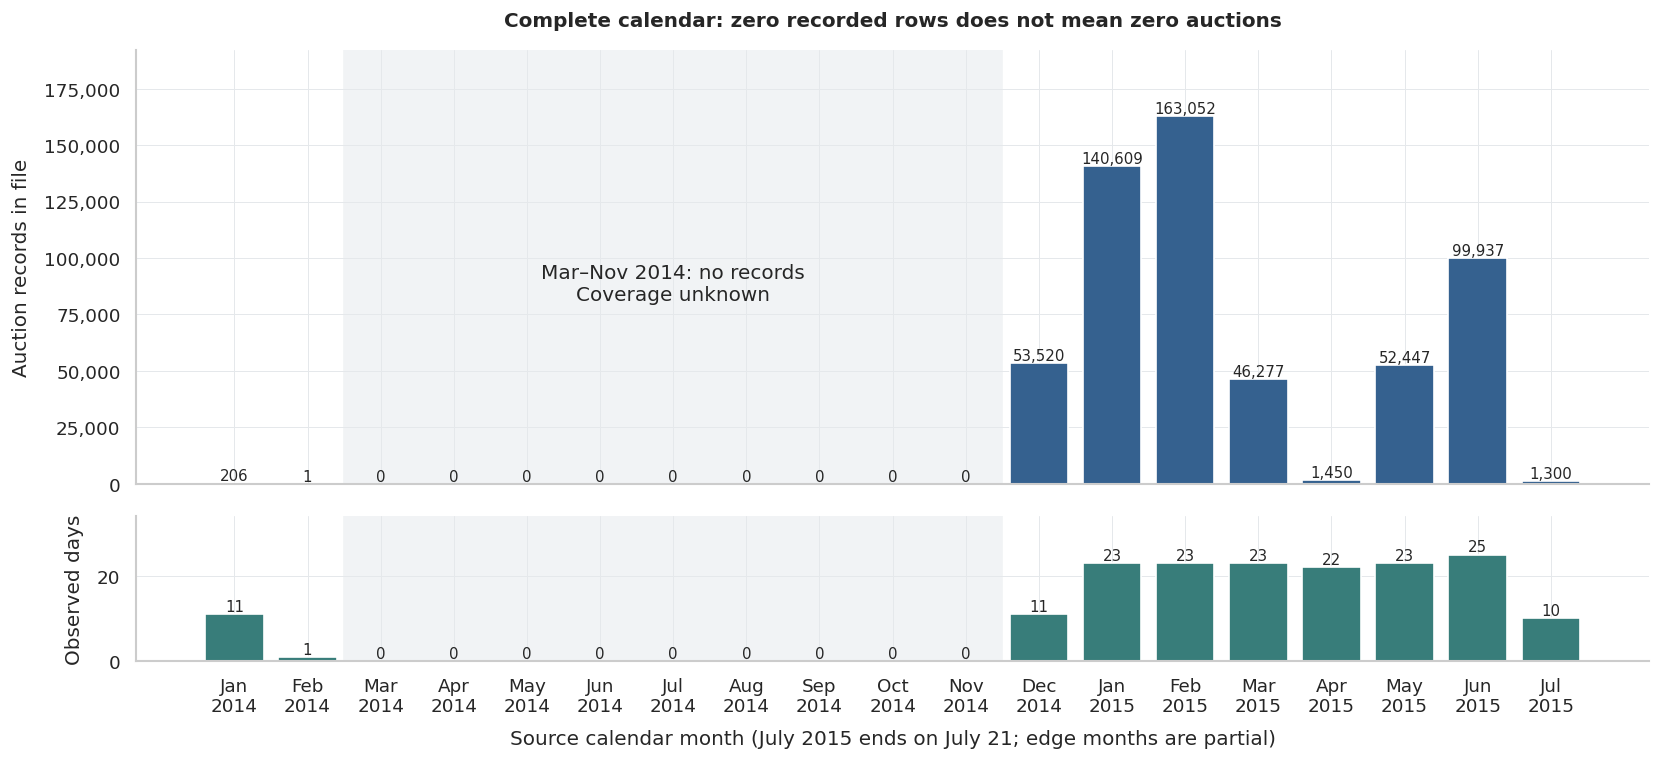

,records,priced_records,observed_days
sale_dt,,,
2014-01-01,206,206,11
2014-02-01,1,1,1
2014-03-01,0,0,0
2014-04-01,0,0,0
2014-05-01,0,0,0
2014-06-01,0,0,0
2014-07-01,0,0,0
2014-08-01,0,0,0
2014-09-01,0,0,0


In [41]:
# A full-domain record count exposes missing coverage without flattening the detail chart.
fig, axes = plt.subplots(2, 1, figsize=(14, 6.5), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})
positions = np.arange(len(monthly_coverage))
counts = monthly_coverage["records"]
axes[0].bar(positions, counts, color=BLUE)
for position, count in enumerate(counts):
    axes[0].text(position, count, f"{count:,}", ha="center", va="bottom", fontsize=9)
axes[0].set_ylim(0, counts.max() * 1.18)
axes[0].set_ylabel("Auction records in file")
axes[0].set_title("Complete calendar: zero recorded rows does not mean zero auctions")
axes[0].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axes[1].bar(positions, monthly_coverage["observed_days"], color=TEAL)
for position, count in enumerate(monthly_coverage["observed_days"]):
    axes[1].text(position, count, str(count), ha="center", va="bottom", fontsize=9)
axes[1].set_ylim(0, 34)
axes[1].set_ylabel("Observed days")
axes[1].set_xticks(positions, monthly_coverage.index.strftime("%b\n%Y"))
for ax in axes:
    ax.axvspan(1.5, 10.5, color="#F1F3F5", zorder=0)
axes[0].text(6, counts.max() * .5, "Mar–Nov 2014: no records\nCoverage unknown", ha="center")
axes[1].set_xlabel("Source calendar month (July 2015 ends on July 21; edge months are partial)")
plt.tight_layout()
plt.show()
display(monthly_coverage)


**The unusual timeline is a coverage issue, not evidence that the market stopped.**
- 207 records appear in Jan–Feb 2014; the next record is Dec 16, after **304 consecutive no-record days**. Nine whole months contain no records.
- April 2015 has **1,450 records over 22 observed days**. It is sparse, not empty. July is a partial edge month: 1,300 records over 10 days, ending July 21.
- We do not know the collection mechanism or why these periods are sparse. No-record bins show zero file rows; prices, missingness rates and market activity remain unknown there.
- The 1,000-record weekly rule controls line display only. Hollow points preserve smaller samples, gaps are not interpolated, and the detailed plot focuses on the months with observations.
- A changing mix of makes, conditions, ages, sellers and missing attributes can move a median without a change in like-for-like vehicle value. There is no repeated seasonal cycle here.


### Missing attributes also change over time
The denominator is all dated raw records in each month. Empty months remain missing rates, never 0%. Case changes are measured separately from genuinely missing values.


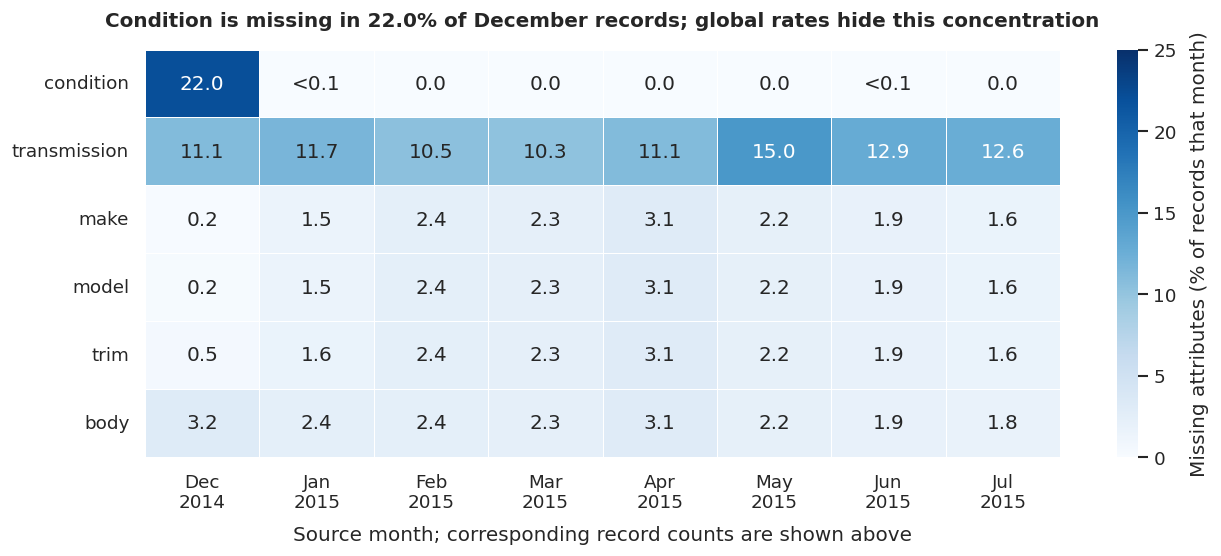

,condition,transmission,make,model,trim,body,records
sale_dt,,,,,,,
2014-01-01,0.000e+00,6.796,0.000,0.000,0.000,1.942,206
2014-02-01,0.000e+00,0.000,0.000,0.000,0.000,0.000,1
2014-03-01,NaN,NaN,NaN,NaN,NaN,NaN,0
2014-04-01,NaN,NaN,NaN,NaN,NaN,NaN,0
2014-05-01,NaN,NaN,NaN,NaN,NaN,NaN,0
2014-06-01,NaN,NaN,NaN,NaN,NaN,NaN,0
2014-07-01,NaN,NaN,NaN,NaN,NaN,NaN,0
2014-08-01,NaN,NaN,NaN,NaN,NaN,NaN,0
2014-09-01,NaN,NaN,NaN,NaN,NaN,NaN,0


In [42]:
missing_columns = ["condition", "transmission", "make", "model", "trim", "body"]
monthly_missing = dated.set_index("sale_dt")[missing_columns].isna().resample("MS").mean() * 100
monthly_missing.loc[monthly_coverage["records"].eq(0)] = np.nan
missing_display = monthly_missing.loc["2014-12-01":]

fig, ax = plt.subplots(figsize=(11, 4.8))
rate_labels = missing_display.T.map(lambda value: "<0.1" if 0 < value < .05 else f"{value:.1f}")
sns.heatmap(missing_display.T, annot=rate_labels, fmt="", cmap="Blues", vmin=0, vmax=25,
            linewidths=.5, cbar_kws={"label": "Missing attributes (% of records that month)"}, ax=ax)
ax.set_xticklabels(missing_display.index.strftime("%b\n%Y"), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_xlabel("Source month; corresponding record counts are shown above")
ax.set_ylabel("")
ax.set_title("Condition is missing in 22.0% of December records; global rates hide this concentration")
plt.tight_layout()
plt.show()
display(monthly_missing.join(monthly_coverage[["records"]]))


In [43]:
condition_absent = dated["condition"].isna()
condition_by_day = dated.assign(condition_missing=condition_absent).groupby("sale_dt").agg(
    records=("condition_missing", "size"), missing_condition=("condition_missing", "sum")
)
condition_by_day["missing_pct"] = 100 * condition_by_day["missing_condition"] / condition_by_day["records"]
display(condition_by_day.nlargest(7, "missing_condition").round(2))
december = dated["sale_dt"].between("2014-12-01", "2014-12-31")
print(f"December contains {(condition_absent & december).sum():,} of {condition_absent.sum():,} date-valid missing-condition records.")
print("The 26 malformed-date rows also have missing condition and MMR; they are excluded by the existing cleaning rules.")
malformed = cars.loc[parse_status.eq("malformed source date")]
schema_check = pd.Series({
    "malformed date records": len(malformed),
    "numeric date strings": malformed["saledate"].astype("string").str.fullmatch(r"\d+").sum(),
    "missing MMR": malformed["mmr"].isna().sum(),
    "missing condition": malformed["condition"].isna().sum(),
    "17-character identifiers in state field": malformed["state"].astype("string").str.fullmatch(r"[A-HJ-NPR-Za-hj-npr-z0-9]{17}").sum(),
})
display(schema_check.to_frame("records"))
print("These values are consistent with shifted fields, not ordinary random blanks. No guessed repair is applied.")


December contains 11,792 of 11,794 date-valid missing-condition records.
The 26 malformed-date rows also have missing condition and MMR; they are excluded by the existing cleaning rules.
These values are consistent with shifted fields, not ordinary random blanks. No guessed repair is applied.


,records,missing_condition,missing_pct
sale_dt,,,
2014-12-18,17065,7038,41.24
2014-12-17,4799,2566,53.47
2014-12-19,4037,1308,32.40
2014-12-23,10120,464,4.58
2014-12-22,1512,251,16.60
2014-12-16,1574,156,9.91
2014-12-31,6013,9,0.15


,records
malformed date records,26
numeric date strings,26
missing MMR,26
missing condition,26
17-character identifiers in state field,26


**Observed pattern, not a proven cause:** 11,792 of 11,794 date-valid missing-condition records fall in December; most occur on Dec 17–19. The other 26 raw missing-condition records belong to malformed-date rows. Neither this concentration nor seller associations identify MAR/MNAR. A source audit is needed before claiming why an attribute is absent.


### Could another record supply the missing information?
This checks **recovery feasibility**, not imputation. A syntactically valid VIN is not a verified VIN or correct source record. “Earlier-day evidence” below rejects VINs with any conflicting observed value anywhere in this file, then requires an earlier non-null record. Because future rows were consulted to reject conflicts, this is not an as-of modeling transform.


In [44]:
vin_text = cars["vin"].astype("string").str.strip().str.upper()
valid_vin = vin_text.str.fullmatch(r"[A-HJ-NPR-Z0-9]{17}").fillna(False)
missing_identity = cars[["make", "model", "trim", "body"]].isna().all(axis=1)
print(f"All-four-description blanks with a valid VIN pattern: {(missing_identity & valid_vin).sum():,} / {missing_identity.sum():,}")
print("This internal-match check uses VIN patterns only. The external NHTSA recovery section applies stricter checks.")

recovery_rows = []
for field in ["make", "model", "trim", "body", "transmission", "condition", "odometer"]:
    values = cars[field].astype("string").str.strip().str.casefold()
    evidence = pd.DataFrame({"vin": vin_text, "value": values, "day": sale_day})
    evidence = evidence.loc[valid_vin & cars[field].notna()]
    variation = evidence.groupby("vin")["value"].nunique()
    consistent_vins = variation.index[variation.eq(1)]
    earliest_day = evidence.groupby("vin")["day"].min()
    absent = cars[field].isna() & valid_vin
    candidate = absent & vin_text.isin(consistent_vins)
    prior = candidate & vin_text.map(earliest_day).lt(sale_day)
    recovery_rows.append({"field": field, "raw missing": int(cars[field].isna().sum()),
                          "same-VIN evidence, any date": int(candidate.sum()),
                          "earlier-day evidence": int(prior.sum())})
display(pd.DataFrame(recovery_rows).set_index("field"))
print("No values were filled. Review correctness, timing and source agreement before any recovery.")


All-four-description blanks with a valid VIN pattern: 10,301 / 10,301
This internal-match check uses VIN patterns only. The external NHTSA recovery section applies stricter checks.
No values were filled. Review correctness, timing and source agreement before any recovery.


,raw missing,"same-VIN evidence, any date",earlier-day evidence
field,,,
make,10301,69,68
model,10399,69,68
trim,10651,56,55
body,13195,1,1
transmission,65352,1163,478
condition,11820,279,0
odometer,94,16,6


**The older notebook had more data, but had not repaired these auction fields.**
- Within this same CSV, consistent same-VIN evidence exists for **69 missing make/model records**, with 68 having earlier-day evidence; trim has 56 candidates (55 earlier), body 1 (1 earlier), transmission 1,163 (478 earlier). These counts are field-specific and must not be added as distinct vehicles.
- For missing condition, **279 records have a consistent value elsewhere, but none has earlier-day evidence**. A later condition observation cannot establish the car's condition at the missing auction.
- Six missing-odometer rows have earlier evidence, but mileage changes over time. Even an earlier mileage is not an exact replacement for auction-day mileage.
- The external NHTSA lookup earlier in this notebook goes beyond these internal matches: it recovered manufacturer specifications alongside the raw columns. Neither check establishes historical condition or mileage.


,records,mean_abs_error,median_signed_error
sale_dt,,,
2015-03-22,188,5464.0,-1225.0
2015-04-05,193,4552.5,-825.0
2015-03-29,187,4038.4,-1225.0
2015-04-12,244,3912.1,-1175.0
2015-06-28,267,3834.8,-200.0


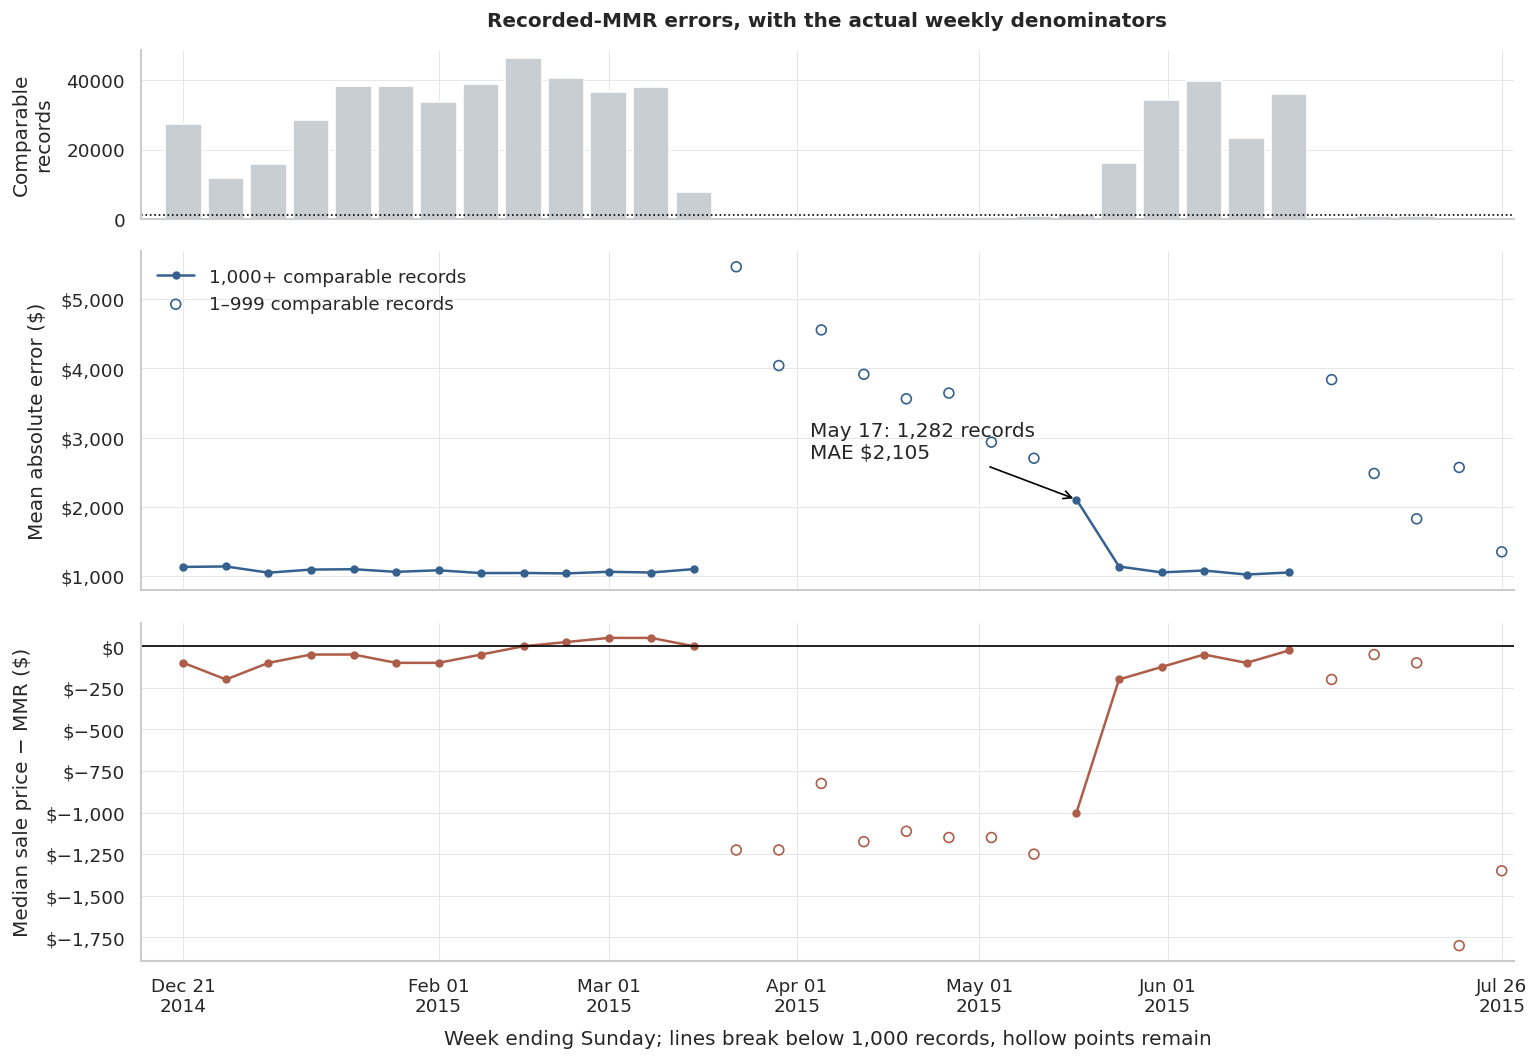

In [45]:
dated_benchmark = benchmark.assign(sale_dt=parse_sale_dates(benchmark["saledate"]))
dated_benchmark = dated_benchmark.dropna(subset=["sale_dt"])
weekly_error = dated_benchmark.set_index("sale_dt").resample("W-SUN").agg(
    records=("error", "size"), mean_abs_error=("abs_error", "mean"),
    median_signed_error=("error", "median")
)
error_focus = weekly_error.loc["2014-12-01":].copy()
error_busy = error_focus["records"] >= MIN_SALES_PER_WEEK
worst_week = error_focus.loc[error_busy, "mean_abs_error"].idxmax()
display(error_focus.sort_values("mean_abs_error", ascending=False).head(5).round(1))

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True,
                         gridspec_kw={"height_ratios": [1, 2, 2]})
axes[0].bar(error_focus.index, error_focus["records"], width=6, color=LIGHT_GRAY)
axes[0].axhline(MIN_SALES_PER_WEEK, color="black", linestyle=":", linewidth=1)
axes[0].set_ylabel("Comparable\nrecords")
axes[0].set_title("Recorded-MMR errors, with the actual weekly denominators")
for ax, metric, label, color in [
    (axes[1], "mean_abs_error", "Mean absolute error ($)", BLUE),
    (axes[2], "median_signed_error", "Median sale price − MMR ($)", RUST),
]:
    ax.plot(error_focus.index, error_focus[metric].where(error_busy),
            marker="o", markersize=4, color=color, label="1,000+ comparable records")
    sparse = error_focus.loc[~error_busy & error_focus["records"].gt(0)]
    ax.scatter(sparse.index, sparse[metric], facecolors="none", edgecolors=color,
               s=35, label="1–999 comparable records")
    ax.set_ylabel(label)
    format_dollar_axis(ax)
axes[1].annotate("May 17: 1,282 records\nMAE $2,105", xy=(worst_week, 2105),
                 xytext=(-160, 25), textcoords="offset points",
                 arrowprops={"arrowstyle": "->", "color": "black"})
axes[1].legend(loc="upper left")
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_xlabel("Week ending Sunday; lines break below 1,000 records, hollow points remain")
time_ticks = pd.to_datetime(["2014-12-21", "2015-02-01", "2015-03-01", "2015-04-01", "2015-05-01", "2015-06-01", "2015-07-26"])
axes[-1].set_xlim(pd.Timestamp("2014-12-14"), pd.Timestamp("2015-07-28"))
axes[-1].set_xticks(time_ticks, time_ticks.strftime("%b %d\n%Y"))
plt.tight_layout()
plt.show()


**Weekly error is descriptive; it is not a prediction interval.**
- The busy week ending May 17 has 1,282 comparable records, MAE **$2,105**, median signed error **−$1,000**, and a low median auction sale price. That merits a vehicle-mix check, not an automatic “market shock” explanation.
- Hollow points show lower-volume weeks. Their denominators remain visible; 1,000 is a display threshold, not proof that one week is trustworthy and another is not.
- Aggregate MAE cannot be turned into “a $10,000 car should sell within ±MAE.” Conditional prediction requires a fitted model, and a 90% interval must be evaluated using actual coverage and width.
- No-record weeks do not supply errors, labels or an adaptive-calibration update. A quieter observed week and an unobserved week are different states.


## 9. Cleaning decisions

In [46]:
def drop_records(frame, mask, rule, audit_log):
    """Remove the records where mask is True and note how many went, and why."""
    kept = frame.loc[~mask]
    audit_log.append(
        {
            "rule": rule,
            "records_removed": len(frame) - len(kept),
            "records_remaining": len(kept),
        }
    )
    return kept


def clean_auction_data(raw):
    """Apply our cleaning rules in order and add sale_dt and age_at_sale."""
    audit_log = []
    clean = raw.copy()

    # These are our rules, not proof the dropped records are wrong.
    # Without the price or MMR, a sale can't be used or compared with the benchmark.
    clean = drop_records(
        clean,
        clean["sellingprice"].isna() | clean["mmr"].isna(),
        "missing sellingprice or mmr",
        audit_log,
    )
    clean = drop_records(
        clean,
        clean["make"].isna() & clean["model"].isna(),
        "missing both make and model",
        audit_log,
    )
    clean = drop_records(clean, clean["saledate"].isna(), "missing saledate", audit_log)

    # Values we don't believe: a car sold for $100 or less, or over 500,000 miles.
    clean = drop_records(
        clean, clean["sellingprice"] <= 100, "sale price at or below $100", audit_log
    )
    clean = drop_records(clean, clean["mmr"] <= 100, "MMR at or below $100", audit_log)
    clean = drop_records(
        clean, clean["odometer"] > 500_000, "odometer above 500,000 miles", audit_log
    )

    # Same VIN on the same date shows up more than once. We keep the first one; the file
    # can't tell us whether the others are double entries or something else.
    repeated = clean.duplicated(subset=["vin", "saledate"], keep="first")
    clean = drop_records(clean, repeated, "same VIN on the same sale date", audit_log)

    clean = clean.copy()
    clean["transmission"] = clean["transmission"].fillna("unknown")
    clean["sale_dt"] = parse_sale_dates(clean["saledate"])
    clean = drop_records(
        clean, clean["sale_dt"].isna(), "sale date not parseable", audit_log
    )

    # Age at sale; -1 is allowed because a 2015 model year can be sold in 2014.
    clean = clean.copy()
    clean["age_at_sale"] = clean["sale_dt"].dt.year - clean["year"]
    clean = drop_records(
        clean,
        ~clean["age_at_sale"].between(-1, 50),
        "age at sale outside -1 to 50 years",
        audit_log,
    )

    return clean, pd.DataFrame(audit_log)

Kept 548,202 of 558,837 auction sales. A few cleaned rows:


rule,records_removed,records_remaining
missing sellingprice or mmr,38,"558,799"
missing both make and model,"10,301","548,498"
missing saledate,0,"548,498"
sale price at or below $100,21,"548,477"
MMR at or below $100,120,"548,357"
"odometer above 500,000 miles",72,"548,285"
same VIN on the same sale date,83,"548,202"
sale date not parseable,0,"548,202"
age at sale outside -1 to 50 years,0,"548,202"


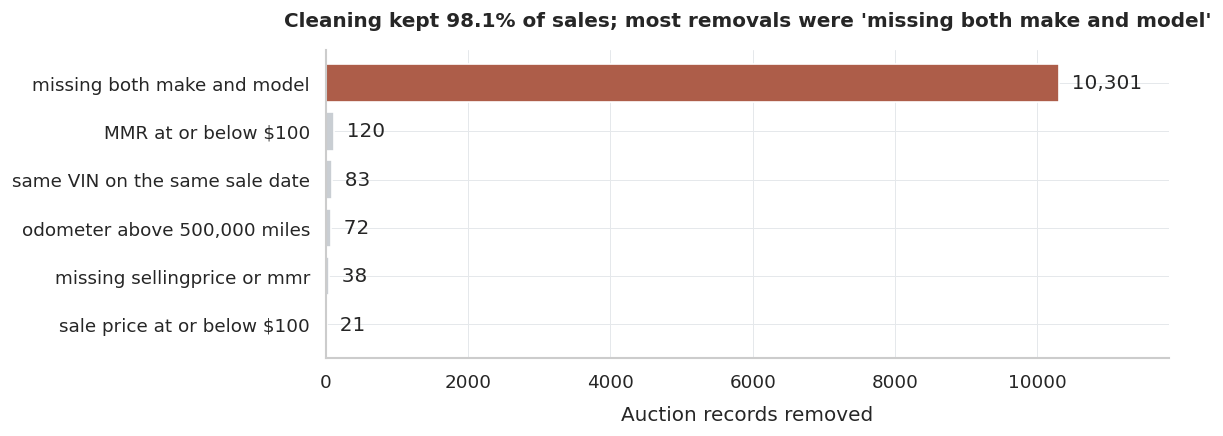

year,age_at_sale,odometer,condition,mmr,sellingprice,sale_dt
2015,-1,"16,639",5,"$20,500","$21,500",2014-12-16
2015,-1,"9,393",5,"$20,800","$21,500",2014-12-16
2014,1,"1,331",45,"$31,900","$30,000",2015-01-15
2015,0,"14,282",41,"$27,500","$27,750",2015-01-29
2014,0,"2,641",43,"$66,000","$67,000",2014-12-18


In [47]:
clean, cleaning_audit = clean_auction_data(cars)

# Every removed record must be accounted for by exactly one rule.
assert cleaning_audit["records_removed"].sum() + len(clean) == len(cars)

display(
    cleaning_audit.style.hide(axis="index").format(
        {"records_removed": "{:,}", "records_remaining": "{:,}"}
    )
)

# Chart: how many sales each rule removed (rules that removed nothing are left out).
removed = cleaning_audit[cleaning_audit["records_removed"] > 0].set_index("rule")[
    "records_removed"
]
removed = removed.sort_values()
biggest_rule = removed.idxmax()

fig, ax = plt.subplots(figsize=(10, 3.8))
bar_colors = [RUST if rule == biggest_rule else LIGHT_GRAY for rule in removed.index]
ax.barh(removed.index, removed.values, color=bar_colors)
for position, count in enumerate(removed.values):
    ax.text(count, position, f"  {count:,}", va="center")
ax.set_xlim(0, removed.max() * 1.15)
ax.set_xlabel("Auction records removed")
ax.set_title(
    f"Cleaning kept {len(clean) / len(cars):.1%} of sales; "
    f"most removals were '{biggest_rule}'"
)
plt.tight_layout()
plt.show()

print(f"Kept {len(clean):,} of {len(cars):,} auction sales. A few cleaned rows:")
preview_columns = [
    "year",
    "age_at_sale",
    "odometer",
    "condition",
    "mmr",
    "sellingprice",
    "sale_dt",
]
display(
    clean[preview_columns]
    .head()
    .style.hide(axis="index")
    .format(
        {
            "odometer": "{:,.0f}",
            "condition": "{:.0f}",
            "mmr": "${:,.0f}",
            "sellingprice": "${:,.0f}",
            "sale_dt": "{:%Y-%m-%d}",
        }
    )
)

**Takeaway: cleaning kept 548,202 of 558,837 auction records (98.1%). Almost everything removed was missing make and model.**

What each rule does, and why:

| Rule | Why |
|---|---|
| Missing price or MMR | Can't use or score a sale without them |
| Missing both make and model | Missing descriptive identity; external VIN evidence above is kept separate from this baseline |
| Price or MMR of \$100 or less, odometer over 500,000 | Our call about what's believable, not proof the records are wrong |
| Same VIN on the same sale date | Keep the first; the file can't tell us if the rest are double entries |

- Missing `transmission` isn't dropped; it becomes **"unknown"**.
- **New column, `age_at_sale`** = sale year minus model year. A 2010 car means something different in a 2014 sale than a 2015 one; age is what drives depreciation. An age of −1 is next year's model sold early.

## 10. Train, validation and test split
**Takeaway: we split by date, so the model is always tested on sales that happened later.**

| Partition | Share of sales | Used for |
|---|---|---|
| Train | oldest ~70% | fitting the model |
| Validation | next ~15% | model selection, with a separate untouched calibration block for intervals |
| Test | newest ~15% | historical evaluation; already inspected |

- **Why not a random split?** It would let the model learn from sales *after* the ones it's tested on. No buyer has that information when bidding, so results would look better than they really are.
- **Whole days only:** each sale day stays in one partition; the cut falls on the day closest to 70% and 85% of sales.


In [48]:
def split_by_sale_day(frame, train_share=0.70, validation_end_share=0.85):
    """Split by date into train, validation and test without cutting any sale day in two."""
    sales_per_day = frame.groupby("sale_dt").size().sort_index()
    if len(sales_per_day) < 3:
        raise ValueError("Need at least three sale days to make three partitions.")
    cumulative_sales = sales_per_day.cumsum().to_numpy()
    total_sales = len(frame)

    # Training ends on the day closest to 70% of sales, leaving at least two later days.
    train_end_position = np.argmin(
        np.abs(cumulative_sales[:-2] - train_share * total_sales)
    )

    # Validation ends on the later day closest to 85%, leaving at least one day for test.
    later_positions = np.arange(train_end_position + 1, len(sales_per_day) - 1)
    distance_to_target = np.abs(
        cumulative_sales[later_positions] - validation_end_share * total_sales
    )
    validation_end_position = later_positions[np.argmin(distance_to_target)]

    train_end = sales_per_day.index[train_end_position]
    validation_end = sales_per_day.index[validation_end_position]

    return {
        "train": frame[frame["sale_dt"] <= train_end],
        "validation": frame[
            (frame["sale_dt"] > train_end) & (frame["sale_dt"] <= validation_end)
        ],
        "test": frame[frame["sale_dt"] > validation_end],
    }


split_frames = split_by_sale_day(clean)
train = split_frames["train"]
val = split_frames["validation"]
test = split_frames["test"]

# The partitions must not overlap in time and must account for every cleaned sale.
assert train["sale_dt"].max() < val["sale_dt"].min()
assert val["sale_dt"].max() < test["sale_dt"].min()
assert len(train) + len(val) + len(test) == len(clean)

In [49]:
split_rows = []
for split_name, frame in split_frames.items():
    span = (frame["sale_dt"].max() - frame["sale_dt"].min()).days + 1
    split_rows.append({
        "partition": split_name, "records": len(frame), "share_pct": 100 * len(frame) / len(clean),
        "first_day": frame["sale_dt"].min().date(), "last_day": frame["sale_dt"].max().date(),
        "observed_days": frame["sale_dt"].nunique(), "calendar_days": span,
        "median_price": frame["sellingprice"].median(),
        "MMR_MAE": (frame["sellingprice"] - frame["mmr"]).abs().mean(),
    })
split_table = pd.DataFrame(split_rows).set_index("partition")
display(split_table.round(2))


,records,share_pct,first_day,last_day,observed_days,calendar_days,median_price,MMR_MAE
partition,,,,,,,,
train,384673,70.17,2014-01-01,2015-03-05,73,429,11900.0,1069.23
validation,77205,14.08,2015-03-06,2015-06-02,66,89,12600.0,1172.76
test,86324,15.75,2015-06-03,2015-07-21,33,49,13300.0,1082.61


In [50]:
# Use raw rows so the old loader's transmission='unknown' fill does not erase the audit.
missing_split_rows = []
for name, frame in split_frames.items():
    raw_members = cars.loc[frame.index]
    for field in ["condition", "odometer", "transmission", "make", "model", "trim", "body"]:
        count = int(raw_members[field].isna().sum())
        missing_split_rows.append({"partition": name, "field": field,
                                   "missing records": count, "records": len(raw_members),
                                   "missing_pct": 100 * count / len(raw_members)})
missing_split = pd.DataFrame(missing_split_rows)
display(missing_split.pivot(index="field", columns="partition", values="missing records").reindex(columns=["train", "validation", "test"]))
display(missing_split.pivot(index="field", columns="partition", values="missing_pct").reindex(columns=["train", "validation", "test"]).round(3))
print("Nearly all condition gaps are in training. Tiny later missing-condition groups cannot establish generalization to missing-condition vehicles.")


Nearly all condition gaps are in training. Tiny later missing-condition groups cannot establish generalization to missing-condition vehicles.


partition,train,validation,test
field,,,
body,2865,1,22
condition,11685,0,1
make,0,0,0
model,64,20,14
odometer,79,3,7
transmission,41031,11035,11483
trim,328,1,20


partition,train,validation,test
field,,,
body,0.745,0.001,0.025
condition,3.038,0.000,0.001
make,0.000,0.000,0.000
model,0.017,0.026,0.016
odometer,0.021,0.004,0.008
transmission,10.666,14.293,13.302
trim,0.085,0.001,0.023


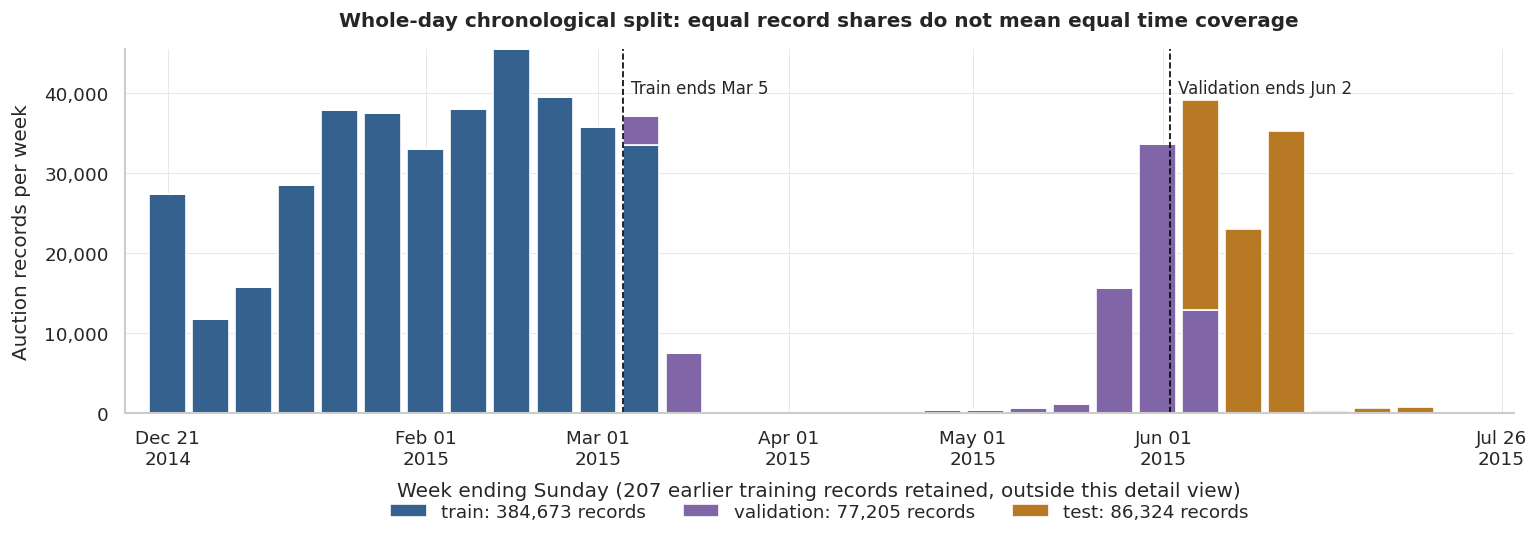

In [51]:
weekly_by_split = pd.DataFrame({
    name: frame.set_index("sale_dt").resample("W-SUN").size()
    for name, frame in split_frames.items()
}).fillna(0)
busy_period = weekly_by_split.loc["2014-12-01":]

fig, ax = plt.subplots(figsize=(13, 4.8))
stack_bottom = np.zeros(len(busy_period))
for split_name, frame in split_frames.items():
    ax.bar(busy_period.index, busy_period[split_name], width=6, bottom=stack_bottom,
           color=SPLIT_COLORS[split_name], label=f"{split_name}: {len(frame):,} records")
    stack_bottom += busy_period[split_name].to_numpy()
for boundary, label in [(train["sale_dt"].max(), "Train ends Mar 5"),
                         (val["sale_dt"].max(), "Validation ends Jun 2")]:
    ax.axvline(boundary, color="black", linestyle="--", linewidth=1)
    ax.annotate(label, (boundary, ax.get_ylim()[1] * .88), xytext=(5, 0),
                textcoords="offset points", rotation=0, fontsize=10)
ax.set_ylabel("Auction records per week")
ax.set_xlabel("Week ending Sunday (207 earlier training records retained, outside this detail view)")
ax.set_title("Whole-day chronological split: equal record shares do not mean equal time coverage")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=3)
time_ticks = pd.to_datetime(["2014-12-21", "2015-02-01", "2015-03-01", "2015-04-01", "2015-05-01", "2015-06-01", "2015-07-26"])
ax.set_xlim(pd.Timestamp("2014-12-14"), pd.Timestamp("2015-07-28"))
ax.set_xticks(time_ticks, time_ticks.strftime("%b %d\n%Y"))
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()
plt.show()


In [52]:
# A later sale date does not mean a different car. Count test sales whose VIN also appears in
# training; these may be resales, duplicate records, or VIN errors - the file cannot tell us which.
def normalize_vins(vins):
    """Uppercase and trim VINs so the same car always matches itself."""
    return vins.dropna().astype(str).str.strip().str.upper()


training_vins = set(normalize_vins(train["vin"]))
resold_in_test = normalize_vins(test["vin"]).isin(training_vins).sum()
print(
    f"Test sales whose VIN also appears in training: {resold_in_test:,} of {len(test):,} "
    f"({resold_in_test / len(test):.1%})"
)

Test sales whose VIN also appears in training: 494 of 86,324 (0.6%)


**The split is chronological and unchanged. Coverage still matters.**
- Train: **384,673 records**, 73 observed days / 429 calendar days, through Mar 5.
- Validation: **77,205 records**, 66 observed days / 89 calendar days, Mar 6–Jun 2. It includes the sparse spring interval; small bars are not missing assignments.
- Test: **86,324 records**, 33 observed days / 49 calendar days, Jun 3–Jul 21. Its median auction sale price is $13,300 versus $11,900 in training; the file does not establish why.
- **494 test records share a VIN with training.** VIN stays out of features; a VIN-disjoint sensitivity check can measure dependence without silently replacing this baseline.

The test has already been inspected. Corrections informed by this EDA are **post-holdout analyses**, not a fresh untouched final test. Preserve historical scores and report corrected runs separately. A later, newly acquired evaluation window is needed for an independent confirmation.


### Do the three partitions look alike?
Price, mileage and age for each partition on the same scale. When the three lines sit close together, the partitions contain similar cars.

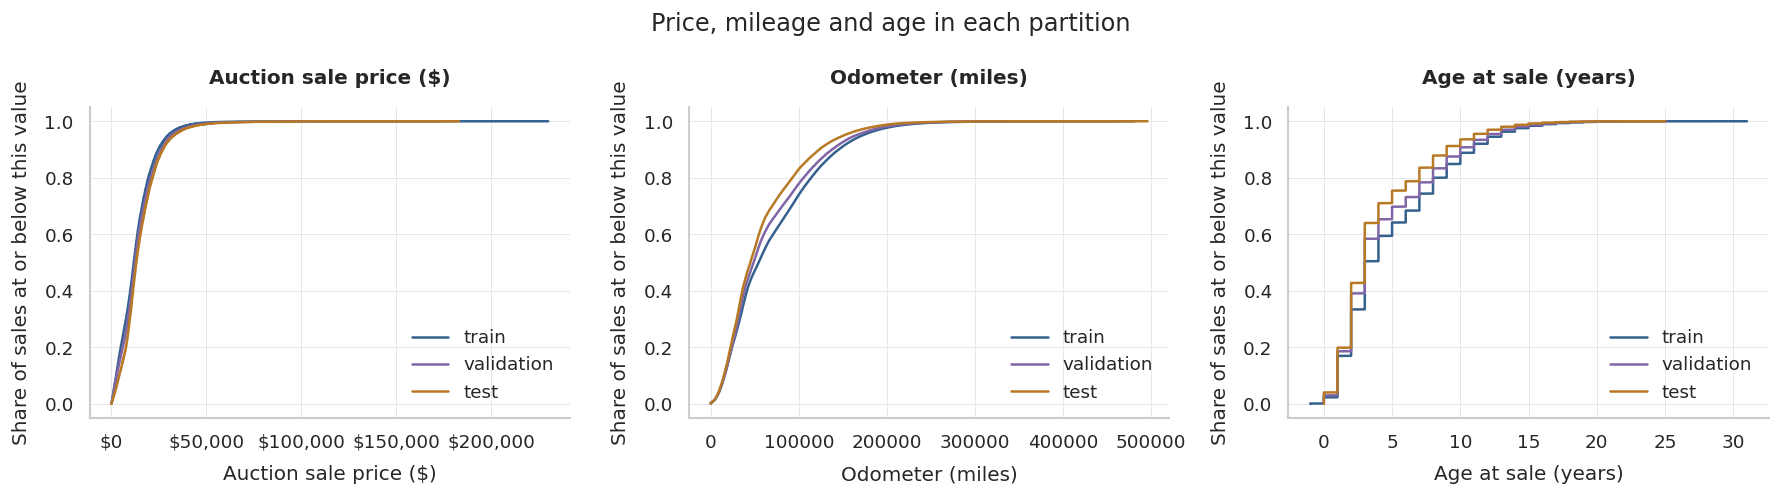

In [53]:
comparison_labels = {
    "sellingprice": "Auction sale price ($)",
    "odometer": "Odometer (miles)",
    "age_at_sale": "Age at sale (years)",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (column, label) in zip(axes, comparison_labels.items(), strict=True):
    for split_name, frame in split_frames.items():
        # Cumulative curve: for each value, the share of sales at or below it.
        values = np.sort(frame[column].dropna().to_numpy())
        share_at_or_below = np.arange(1, len(values) + 1) / len(values)
        ax.plot(values, share_at_or_below, color=SPLIT_COLORS[split_name], label=split_name)
    ax.set_xlabel(label)
    ax.set_ylabel("Share of sales at or below this value")
    ax.set_title(label)
    ax.legend()

format_dollar_axis(axes[0], which="x")
fig.suptitle("Price, mileage and age in each partition")
plt.tight_layout()
plt.show()

### Body-style labels change spelling over time
The file writes the same body style two ways: `Sedan` early on and `sedan` later. A model only knows the labels it saw in training, so to it `sedan` looks like a brand-new kind of car. The left chart shows the spelling switch; the right chart shows how many test sales that would trip up, before and after lowercasing.

In [54]:
CASE_COLORS = {
    "Capitalized (Sedan, SUV)": BLUE,
    "lowercase (sedan, suv)": RUST,
    "missing": LIGHT_GRAY,
}


def body_label_case(labels):
    """Label each sale's body style as Capitalized, lowercase, or missing."""
    case = pd.Series("Capitalized (Sedan, SUV)", index=labels.index)
    case[labels.fillna("").str.islower()] = "lowercase (sedan, suv)"
    case[labels.isna()] = "missing"
    return case


def share_unseen_in_training(test_labels, training_labels, lowercase):
    """Share of test sales whose body label never appears in training."""
    if lowercase:
        test_labels = test_labels.str.strip().str.lower()
        training_labels = training_labels.str.strip().str.lower()
    denominator = len(test_labels)
    observed = test_labels.dropna()
    if denominator == 0:
        return np.nan
    return 100 * (~observed.isin(set(training_labels.dropna()))).sum() / denominator


In [55]:
# Count casing and diagnostic unseen-label shares without altering raw values.
case_shares = (
    pd.DataFrame(
        {
            split_name: 100 * body_label_case(frame["body"]).value_counts(normalize=True)
            for split_name, frame in split_frames.items()
        }
    )
    .T.reindex(columns=list(CASE_COLORS))
    .fillna(0)
)

# Why it matters: a label never seen in training is "unknown" to the model.
unseen = pd.Series(
    {
        "as written": share_unseen_in_training(
            test["body"], train["body"], lowercase=False
        ),
        "after lowercasing": share_unseen_in_training(
            test["body"], train["body"], lowercase=True
        ),
    }
)


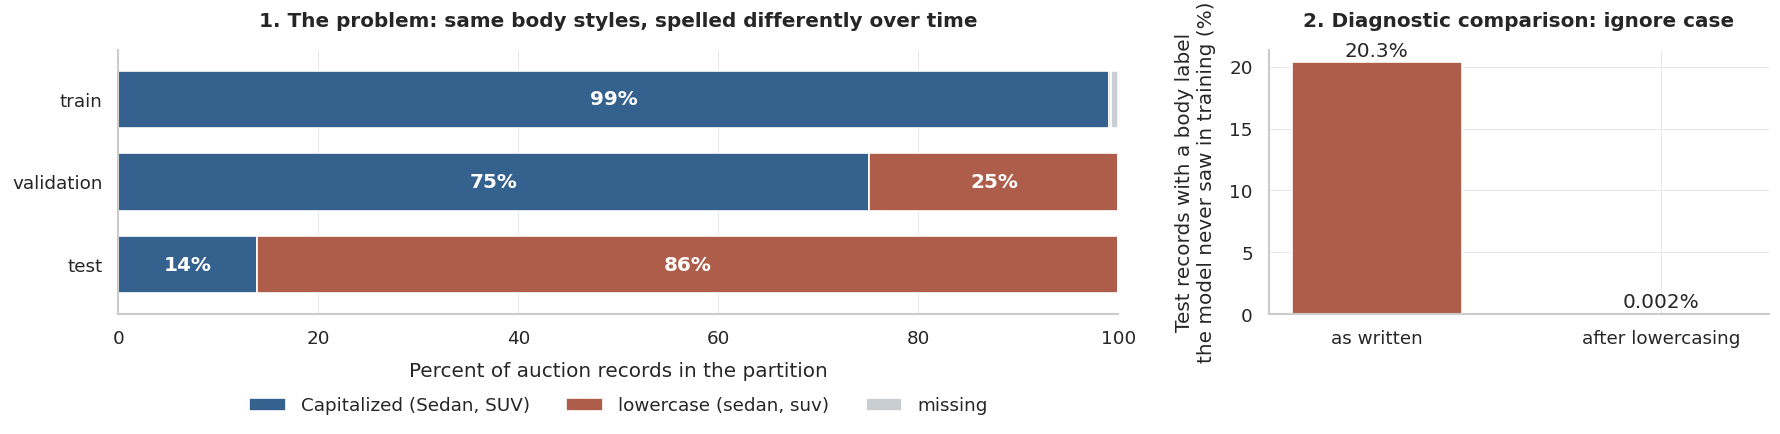

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4), gridspec_kw={"width_ratios": [2, 1]})

case_shares.plot.barh(stacked=True, color=list(CASE_COLORS.values()), width=0.7, ax=axes[0])
axes[0].invert_yaxis()  # train on top, in time order
axes[0].set_xlim(0, 100)
axes[0].set_xlabel("Percent of auction records in the partition")
axes[0].set_ylabel("")
axes[0].set_title("1. The problem: same body styles, spelled differently over time")
axes[0].legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.25))
for segment in axes[0].containers:
    segment_labels = [f"{value:.0f}%" if value >= 5 else "" for value in segment.datavalues]
    axes[0].bar_label(
        segment,
        labels=segment_labels,
        label_type="center",
        color="white",
        fontweight="semibold",
    )

axes[1].bar(unseen.index, unseen.values, color=[RUST, TEAL], width=0.6)
for position, value in enumerate(unseen.values):
    axes[1].text(
        position,
        value + 0.5,
        f"{value:.1f}%" if value >= 0.1 else f"{value:.3f}%",
        ha="center",
    )
axes[1].set_ylabel("Test records with a body label\nthe model never saw in training (%)")
axes[1].set_title("2. Diagnostic comparison: ignore case")

plt.tight_layout()
plt.show()


**Observed casing shift; proposed Stage 4 treatment.**
- As written, **20.3%** of test records have a body label absent from training. In the diagnostic lowercased comparison, that falls to **0.002%**.
- The earlier price model kept case. The Stage 4 plan is to normalize case and whitespace before encoding.
- These EDA comparisons do not alter the raw labels or fit an encoder.


### The benchmark to beat
Recorded MMR's error on the test sales. Models are chosen on validation; we report test results once at the end, compared with this number.

In [57]:
# We do not know whether MMR was published before bidding, so this is a retrospective benchmark.
test_errors = test["sellingprice"] - test["mmr"]
test_pct_error = 100 * test_errors.abs() / test["mmr"]

test_benchmark = pd.Series(
    {
        "Auction sales in the test partition": f"{len(test):,}",
        "Mean absolute error": f"${test_errors.abs().mean():,.0f}",
        "Median absolute error": f"${test_errors.abs().median():,.0f}",
        "Mean absolute error as a percent of MMR": f"{test_pct_error.mean():.1f}%",
    },
    name="Recorded MMR on test",
)
display(test_benchmark.to_frame())

,Recorded MMR on test
Auction sales in the test partition,"86,324"
Mean absolute error,"$1,083"
Median absolute error,$700
Mean absolute error as a percent of MMR,10.4%


## 11. What this data cannot tell us
Several boundaries shape what we can honestly claim at the end.

- **The prices are from 2014 and 2015.** The dollar amounts will not carry over to a sale today; the method does. A dealer would retrain the same pipeline on recent purchases.
- **There is no profit information.** The data records what a car sold for, not reconditioning costs or resale. We can show an estimate is accurate, not that acting on it makes money, which is why our headline measure is mispricing flagged rather than dollars earned.
- **There is no buyer.** `seller` is the seller, so we cannot study how buyers behave.
- **No photographs are attached to these sales.** Price and damage are tested on separate datasets, so we cannot measure how much a specific dent lowers a specific car's price.
- **Nothing records how long a car took to sell,** which rules out demand forecasting.
- **Timing and codebooks are undocumented.** We do not know when MMR was published relative to bidding, or exactly what each condition code means.
- **The observation calendar is incomplete.** We cannot distinguish “not collected” from “no market activity” on empty dates. Do not train a seasonal demand model or convert file counts into market volume.
- **Missingness is temporally concentrated.** Missing indicators and per-period audits are required; imputation does not establish true condition or transmission.


### Existing project data versus remaining acquisition work
The older completed notebook contains a broader source inventory. Counts below are **saved receipts**, not new downloads or evidence that these tables were joined into the auction model. The auction CSV hash is the same in both notebooks. Only the auction CSV was reloaded for this revision; the Treasury snapshot is embedded in the older notebook. Other source counts are historical run receipts. Their prior Colab/Drive paths have not been revalidated here, so reacquisition or access checks may be needed before reuse.

| Source | Evidence already acquired or verified | What it can and cannot supply next |
|---|---|---|
| Kaggle auction CSV | 558,837 records; 2014–15; same verified version | Main auction sale-price evidence. Audit raw rows and ask uploader for collection history, missing-value conventions and condition/MMR timing. |
| DVM | 268,255 ads in 7 tables; 61,827 checked front-view JPGs; 55,733 valid label/age/pixel pairs | Separate UK asking-price/image evidence, dated 2012–18. Uses ad/model IDs, with no verified Kaggle VIN crosswalk; do not join loosely by make/model to invent historical auction condition. |
| CarDD | Final EDA verifies 4,000 photos and 8,740 damage instances | Separate damage benchmark, newly accessible in this EDA. No auction-sale VIN join, verified clean controls or repair dollars. |
| Auto.dev | 20 current U.S. listings and 20 decoded primary images | Small existing VIN/photo bridge sample, unreviewed and unlabeled. Current 2026 observations cannot restore 2014–15 condition. Historical linkage and permitted use need verification. |
| CarGurus | 25,103 preview rows across 30 first-seen cohort files | No usable VIN/price/photo rows in that saved run, and no daily snapshots. Historical export access remains an acquisition route. Provider days-on-market is not a sold outcome. |
| NY DMV | 100,000 inspections and 100,000 registrations | VIN linkage may support later history, but the earliest acquired inspection is in 2021. It cannot backfill 2014–15 mileage or condition. |
| NHTSA | 200,185 bulk complaints, 1,582 deduplicated API complaints, 16 recalls, 179,562 TSBs, 5 sample vPIC decodes in the older run; 75,940 VIN/year replies in the new lookup above | The new exact-VIN lookup supplies the recovered specs shown above; held values and label mappings still need review. The acquired complaint/TSB context is later; historical risk features need event dates and evidence of availability before each auction. |
| Treasury | 182 published winning bids from 8 Jan–Apr 2026 PDFs; 122 general-auction candidates | Small separate auction-price sample; no MMR or photos, and winning bids are not proof of settled purchase or resale profit. |
| Other providers / dealer history | Disabled providers acquired 0 in that run; a dealer-history schema exists, not matched observations | Access/licensing and actual exports still need confirmation. Request VIN/acquisition IDs, pre-bid photos/timestamps, bid/fees, reconditioning and resale records before claiming an end-to-end linked dataset. |

**Stage 3 conclusion:** more data existed in the older notebook, and some sources are useful acquisition leads. It did not contain a validated enrichment join that recovered these missing auction attributes. Keep each source's population, IDs and time window explicit before combining them.

Source receipts: `Forward_Motors_CPU_Point_and_Interval_Results.ipynb`, SHA-256 `d6d26e3a35d66d1efd9fc9c43243768e46e205ac0794b5c9c629e7aef3a00137`; saved DVM, DMV, NHTSA, listings and Treasury sections. This EDA is based on [stage3-revision commit 0279e79](https://github.com/wmoore012/forward-motors/commit/0279e79ddbc0caac7b9119200dcf2e975f79095c) plus the new read-only diagnostics.


## 12. Dataset at a glance

In [58]:
auction_glance = pd.Series(
    {
        "Dataset": "Vehicle Sales Data (wholesale auction sales)",
        "Source": "Kaggle, Syed Anwar Afridi (2024), version 1",
        "Auction sales, as downloaded": f"{len(cars):,}",
        "Auction sales, after cleaning": f"{len(clean):,} ({len(clean) / len(cars):.1%} kept)",
        "Original columns": f"{cars.shape[1]}",
        "Task": "Regression (no classes)",
        "Target": "sellingprice, auction sale price in US dollars",
        "Target range": f"${clean['sellingprice'].min():,.0f} to ${clean['sellingprice'].max():,.0f}",
        "Target median": f"${clean['sellingprice'].median():,.0f}",
        "Sale dates": f"{clean['sale_dt'].min().date()} to {clean['sale_dt'].max().date()}",
        "Split": "By date, whole sale days, about 70 / 15 / 15",
        "Train / validation / test": f"{len(train):,} / {len(val):,} / {len(test):,}",
        "Benchmark to beat": f"Recorded MMR, ${test_errors.abs().mean():,.0f} mean absolute error on test",
    },
    name="value",
)
display(auction_glance.to_frame())

,value
Dataset,Vehicle Sales Data (wholesale auction sales)
Source,"Kaggle, Syed Anwar Afridi (2024), version 1"
"Auction sales, as downloaded","558,837"
"Auction sales, after cleaning","548,202 (98.1% kept)"
Original columns,16
Task,Regression (no classes)
Target,"sellingprice, auction sale price in US dollars"
Target range,"$150 to $230,000"
Target median,"$12,200"
Sale dates,2014-01-01 to 2015-07-21


## 13. What this means for our three research questions
**This EDA doesn't answer the questions; Stages 4 and 5 do. It tells us whether each one is worth asking.**

| Question | Worth asking? | What the data shows | How we'll answer it |
|---|---|---|---|
| **Q1. Can we predict where MMR is wrong?** | ✅ Yes | MMR is off by over \$1,000 on **37%** of cars, and the errors line up with price, condition code and seller | Beat MMR's **\$1,083** average error on the test sales. Reserve calibration separately; already-inspected test comparisons are historical/post-holdout. |
| **Q2. Does an updating price range stay near 90% coverage?** | ❔ Open | MMR's average error is steady week to week, but that says nothing about the rare big errors, and it's MMR's error, not ours | Measure coverage and width of real prediction ranges on later sales |
| **Q3. Can a detector find visible damage?** | ➡️ Part B | No photos in the auction data. MMR's error is bigger on low condition codes (\$1,396 vs \$930), but we don't know if those codes mean visible damage | Train on CarDD photos (Part B); no photo is linked to a sale, so we can't test damage vs price here |

## 14. Proposed treatment and evidence plan (Stage 4)
This section is a plan. Stage 3 preserves and diagnoses the raw attributes; it does not fit imputers, add engineered model features or train new models.

| Field or gap | Recover first? | Proposed treatment and check |
|---|---|---|
| Auction sale price | Only from the original source record | Never impute the target. Exclude unscorable rows and report the count. |
| Recorded MMR | Seek original value and publication timestamp | Do not manufacture the benchmark. Keep no-MMR and recorded-MMR analyses distinct; pre-auction timing remains unverified. |
| Malformed sale dates / shifted fields | Inspect original export with uploader/schema evidence | Quarantine; repair only a demonstrated format error. Keep original strings and a before/after receipt. Never rewrite early dates simply because they are inconvenient. |
| Missing condition | Request condition codebook and source/collection explanation | Existing model used a train-only median. Later compare that baseline with missingness indicators, native-missing handling and a condition-omitted sensitivity. Static VIN decoding or a current photo cannot restore historical condition. |
| Missing odometer | Recover only a verified measurement at or before that auction | Later compare train-only median + indicator versus native missing values. Never backfill a 2014–15 mileage from a 2021+ inspection. |
| Transmission / remaining description blanks | Use the recovered NHTSA specs alongside raw fields; review held values and label mappings | Retain an explicit unknown state if unresolved. Do not assume the modal gearbox. Compare retention against the current drop-both-make/model rule without silently replacing the baseline. |
| Color / interior em dash | Verify source convention | Keep a separately reported unresolved token until meaning is confirmed; any later missing-token treatment must be explicit. |
| Body/make/model/trim casing | Source labels clearly differ by case | In Stage 4, normalize whitespace/case before train-only encoding. Stage 3 only measures the changes. |
| No-record dates | Obtain additional timestamped auction records and collection coverage | Do not interpolate missing prices or treat absent file rows as zero market activity. No adaptive-calibration updates without observed labels. |
| Linked photos / costs / profit | Acquire genuinely linked, timestamped observations | Keep CarDD detection and auction-price work separate until a verified join exists. Do not infer damage-value or profit from unpaired datasets. |

**What the older notebook already did:** its completed auction model used train-only numeric medians, `unknown` transmission and code 0 for missing/rare/unseen categories. It did not recover source attributes, add numeric missing indicators or establish why values were missing. Its $994 recorded-MMR-inclusive HGB MAE and completed interval results remain historical evidence, unchanged here.

**Evaluation after this EDA:** freeze any treatment comparison before fitting; keep model settings and row/day partitions fixed; reserve calibration separately from model selection. Report observed/missing subgroup counts and errors, temporal coverage/width and a VIN-disjoint sensitivity. Already-inspected test results are post-holdout evidence, not a new final test. Seek a later untouched sample for independent confirmation.

**Sequence scope:** unrelated auction rows are not repeated measurements of one entity. Sparse dates and no well-covered repeated annual cycle do not support seasonal demand claims. A GRU needs a defensible repeated-observation sequence, explicit gaps and simple non-sequence baselines.


## References

Afridi, S. A. (2024). *Vehicle Sales Data* [Dataset]. Kaggle.
https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data

Manheim / Cox Automotive. *MMR Best Practices* and *MMR Help*.

Romano, Y., Patterson, E., & Candès, E. (2019). Conformalized quantile regression. *NeurIPS*.

Gibbs, I., & Candès, E. (2021). Adaptive conformal inference under distribution shift. *NeurIPS*.

## Part B. CarDD damage-image EDA
CarDD is the labeled photo set the damage detector will learn from. Each photo shows one or more damaged areas, and each area is labeled with one of six damage types (dent, scratch, crack, glass shatter, lamp broken, tire flat), a box around it, and an outline of its exact shape.

### Where the CarDD photos come from
Our authorized release is on Drive, and the earlier notebook also saved a TAR copy under the project cache. The loader now checks both. A Drive item listed under “Shared with me” does not automatically appear at a guessed `MyDrive/CarDD_release` path.

1. Use `FM_CARDD_ROOT` if a folder was explicitly selected.
2. Check the known release folders and earlier local staging folders.
3. Restore `CarDD_core_COCO_plus_image_info.tar` from the existing Drive cache when no complete folder is available.

Every selected copy must match all three image-file lists, image counts and per-class annotation counts. Restoration rejects links, unsafe paths, unexpected files and incomplete archives; it never overwrites the source or an existing staged copy. Counts and file membership do not prove pixel identity, so the geometry checks below still run.

**Using a different account?** Supply an authorized copy. The [CarDD authors](https://cardd-ustc.github.io/) require their licensing form to obtain the data. This notebook does not automatically fetch a third-party mirror.


In [ ]:
# @title CarDD source helpers (1/5) { display-mode: "form" }
"""Find and validate existing CarDD data; never download or modify source data."""

import json

import hashlib

import os

import shutil

import tarfile

import tempfile

from collections import Counter

from pathlib import Path, PurePosixPath

CARDD_SPLITS = ("train", "val", "test")

CARDD_EXPECTED_PHOTOS = {"train": 2816, "val": 810, "test": 374}

CARDD_EXPECTED_AREAS = {
    "train": {"dent": 1806, "scratch": 2560, "crack": 651,
              "glass shatter": 475, "lamp broken": 494, "tire flat": 225},
    "val": {"dent": 501, "scratch": 728, "crack": 177,
            "glass shatter": 135, "lamp broken": 141, "tire flat": 62},
    "test": {"dent": 236, "scratch": 307, "crack": 70,
             "glass shatter": 71, "lamp broken": 69, "tire flat": 32},
}

CARDD_CACHE_TAR = Path(
    "/content/drive/MyDrive/forward-motors/_fm_cache/cardd/"
    "CarDD_core_COCO_plus_image_info.tar"
)

def cardd_layout(root):
    """Recognize complete annotation layouts without traversing image folders."""
    root = Path(root).expanduser()
    for layout in ("official", "kaggle"):
        if layout == "official":
            annotations = {s: root / "annotations" / f"instances_{s}2017.json"
                           for s in CARDD_SPLITS}
            image_dirs = {s: root / f"{s}2017" for s in CARDD_SPLITS}
        else:
            annotations = {s: root / f"{s}.json" for s in CARDD_SPLITS}
            image_dirs = {s: root / s for s in CARDD_SPLITS}
        if all(p.is_file() for p in annotations.values()):
            return {"root": root, "layout": layout,
                    "annotation_paths": annotations, "image_dirs": image_dirs}
    return None


In [ ]:
# @title CarDD source helpers (2/5) { display-mode: "form" }
def discover_cardd_layouts(root):
    """Check a root and at most two directory levels, excluding image trees."""
    root = Path(root).expanduser()
    if not root.is_dir():
        return []
    queue, found, seen = [(root, 0)], [], set()
    image_names = {"train", "val", "test", "train2017", "val2017", "test2017"}
    while queue:
        candidate, depth = queue.pop(0)
        key = str(candidate.resolve())
        if key in seen:
            continue
        seen.add(key)
        if candidate.is_symlink():
            continue
        layout = cardd_layout(candidate)
        if layout:
            found.append(layout)
            continue
        if depth < 2:
            children = []
            for p in candidate.iterdir():
                if p.is_dir() and not p.is_symlink() and p.name not in image_names:
                    children.append(p)
                    if len(children) > 100:
                        raise ValueError(f"Too many folders under {candidate}; set FM_CARDD_ROOT precisely.")
            queue.extend((p, depth + 1) for p in sorted(children))
    return found


In [ ]:
# @title CarDD source helpers (3/5) { display-mode: "form" }
def validate_cardd_layout(layout, expected_photos=None, expected_areas=None):
    """Check every COCO record and every referenced filename before selecting data."""
    expected_photos = CARDD_EXPECTED_PHOTOS if expected_photos is None else expected_photos
    expected_areas = CARDD_EXPECTED_AREAS if expected_areas is None else expected_areas
    category_reference, receipt = None, {}
    for split in CARDD_SPLITS:
        annotation_path = layout["annotation_paths"][split]
        image_dir = layout["image_dirs"][split]
        if annotation_path.is_symlink() or image_dir.is_symlink():
            raise ValueError(f"Symlinked CarDD input refused: {split}")
        if annotation_path.stat().st_size > 100 * 1024**2:
            raise ValueError(f"Annotation file unexpectedly large: {annotation_path}")
        annotation_bytes = annotation_path.read_bytes()
        annotation_sha256 = hashlib.sha256(annotation_bytes).hexdigest()
        coco = json.loads(annotation_bytes)
        categories = {int(c["id"]): c["name"] for c in coco["categories"]}
        if len(categories) != len(coco["categories"]):
            raise ValueError(f"Duplicate category IDs: {split}")
        if set(categories.values()) != set(expected_areas[split]):
            raise ValueError(f"Unexpected damage classes: {split}")
        if category_reference is None:
            category_reference = categories
        elif categories != category_reference:
            raise ValueError(f"Category IDs differ between splits: {split}")
        images, areas = coco["images"], coco["annotations"]
        ids = [i["id"] for i in images]
        names = [i["file_name"] for i in images]
        if len(images) != expected_photos[split] or len(set(ids)) != len(ids):
            raise ValueError(f"Unexpected or duplicate image count: {split}")
        if len(set(names)) != len(names):
            raise ValueError(f"Duplicate image filenames: {split}")
        if any(not isinstance(n, str) or not n or Path(n).name != n or
               "\\" in n or n in (".", "..") for n in names):
            raise ValueError(f"Unsafe image filename: {split}")
        area_ids = [a["id"] for a in areas]
        if len(set(area_ids)) != len(area_ids):
            raise ValueError(f"Duplicate annotation IDs: {split}")
        known_ids = set(ids)
        if any(a["image_id"] not in known_ids for a in areas):
            raise ValueError(f"Annotation references an unknown image: {split}")
        if any(a["category_id"] not in categories for a in areas):
            raise ValueError(f"Unknown category ID: {split}")
        actual_areas = Counter(categories[a["category_id"]] for a in areas)
        if dict(actual_areas) != expected_areas[split]:
            raise ValueError(f"Damage-class counts differ: {split}")
        if not image_dir.is_dir():
            raise FileNotFoundError(f"Image folder missing: {image_dir}")
        actual_names = set()
        for p in image_dir.iterdir():
            if p.is_symlink():
                raise ValueError(f"Symlinked image refused: {p}")
            if p.is_file() and p.suffix.lower() in (".jpg", ".jpeg", ".png"):
                actual_names.add(p.name)
        if actual_names != set(names):
            missing, extra = set(names) - actual_names, actual_names - set(names)
            raise ValueError(f"Image membership mismatch in {split}: {len(missing)} missing, {len(extra)} extra")
        if any((image_dir / n).stat().st_size == 0 for n in names):
            raise ValueError(f"Empty image file: {split}")
        receipt[split] = {"images": len(images), "annotations": len(areas),
                          "annotation_sha256": annotation_sha256,
                          "all_referenced_files_present": True,
                          "class_counts": dict(actual_areas)}
    return receipt


In [ ]:
# @title CarDD source helpers (4/5) { display-mode: "form" }
def safe_restore_cardd_tar(archive, stage_parent, *, max_expanded_bytes=4 * 1024**3,
                           expected_photos=None, expected_areas=None):
    """Restore the known core archive atomically, rejecting links and unsafe paths."""
    archive, stage_parent = Path(archive), Path(stage_parent)
    if archive.is_symlink() or not archive.is_file():
        raise ValueError(f"CarDD archive is absent or a symlink: {archive}")
    stage_parent.mkdir(parents=True, exist_ok=True)
    with tarfile.open(archive, "r:*") as bundle:
        members, seen, total = [], set(), 0
        for member in bundle:
            path = PurePosixPath(member.name)
            parts = path.parts
            if (not parts or path.is_absolute() or ".." in parts or
                    "\\" in member.name or not (member.isfile() or member.isdir())):
                raise ValueError(f"Unsafe archive member: {member.name}")
            allowed_dir = member.isdir() and (
                parts == ("CarDD_COCO",) or
                (len(parts) == 2 and parts[0] == "CarDD_COCO" and
                 parts[1] in {"annotations", "train2017", "val2017", "test2017"}))
            allowed_file = member.isfile() and (
                parts == ("image_info.xlsx",) or
                (len(parts) == 3 and parts[:2] == ("CarDD_COCO", "annotations") and
                 parts[2] in {f"instances_{s}2017.json" for s in CARDD_SPLITS}) or
                (len(parts) == 3 and parts[0] == "CarDD_COCO" and
                 parts[1] in {f"{s}2017" for s in CARDD_SPLITS} and
                 path.suffix.lower() in {".jpg", ".jpeg", ".png"}))
            if not (allowed_dir or allowed_file) or str(path) in seen:
                raise ValueError(f"Unexpected or duplicate archive member: {member.name}")
            seen.add(str(path))
            total += member.size
            members.append(member)
            if member.size < 0 or total > max_expanded_bytes or len(members) > 5000:
                raise ValueError("CarDD archive exceeds the extraction budget.")
        if shutil.disk_usage(stage_parent).free < total * 1.10 + 100 * 1024**2:
            raise RuntimeError("Not enough local disk space for a safe CarDD restore.")
        temporary = Path(tempfile.mkdtemp(prefix=".cardd-restore-", dir=stage_parent))
        print(f"Restoring authorized CarDD cache: {archive.name} ({archive.stat().st_size / 1024**3:.2f} GiB)")
        try:
            for member in members:
                destination = temporary / member.name
                if member.isdir():
                    destination.mkdir(parents=True, exist_ok=True)
                else:
                    destination.parent.mkdir(parents=True, exist_ok=True)
                    with bundle.extractfile(member) as source, destination.open("xb") as target:
                        copied_bytes = 0
                        for chunk in iter(lambda: source.read(1024**2), b""):
                            target.write(chunk)
                            copied_bytes += len(chunk)
                        if copied_bytes != member.size:
                            raise ValueError(f"Short archive read: {member.name} ({copied_bytes} of {member.size} bytes)")
            layout = cardd_layout(temporary / "CarDD_COCO")
            if layout is None:
                raise ValueError("Cached archive does not contain all three COCO annotation files.")
            receipt = validate_cardd_layout(layout, expected_photos, expected_areas)
            final_root = stage_parent / ("CarDD_release-restored-" + temporary.name.removeprefix(".cardd-restore-"))
            if final_root.exists():
                raise FileExistsError(f"Refusing to replace an existing stage: {final_root}")
            temporary.rename(final_root)
        except Exception:
            # Only remove the new temporary directory created by this call.
            shutil.rmtree(temporary)
            raise
    result = cardd_layout(final_root / "CarDD_COCO")
    result.update(source="authorized Drive cache archive", archive_path=str(archive), receipt=receipt)
    return result


In [ ]:
# @title CarDD source helpers (5/5) { display-mode: "form" }
def resolve_cardd_source(candidates, *, explicit_root=None, archive_path=CARDD_CACHE_TAR,
                         stage_parent=Path("/content"), expected_photos=None,
                         expected_areas=None):
    """Prefer validated local/Drive data, then the existing cache; no network fallback."""
    explicit_root = explicit_root or os.environ.get("FM_CARDD_ROOT")
    if explicit_root:
        layouts = discover_cardd_layouts(explicit_root)
        if len(layouts) != 1:
            raise ValueError("FM_CARDD_ROOT must identify exactly one complete CarDD layout.")
        result = layouts[0]
        result.update(receipt=validate_cardd_layout(result, expected_photos, expected_areas),
                      source="explicit FM_CARDD_ROOT")
        return result
    errors = []
    for candidate in candidates:
        for result in discover_cardd_layouts(candidate):
            try:
                receipt = validate_cardd_layout(result, expected_photos, expected_areas)
            except (OSError, ValueError, KeyError, TypeError) as error:
                errors.append(f"{result['root']}: {error}")
                continue
            result.update(source="existing validated folder", receipt=receipt)
            return result
    if archive_path is not None and Path(archive_path).is_file():
        return safe_restore_cardd_tar(archive_path, stage_parent,
                                     expected_photos=expected_photos, expected_areas=expected_areas)
    details = "\n".join(errors[:3])
    raise FileNotFoundError(
        "No complete CarDD source found. Mount the authorized Drive, set FM_CARDD_ROOT "
        "to the release or COCO folder, or provide its existing cache archive. "
        "No files were downloaded.\n" + details
    )


In [ ]:
# @title Select and verify the authorized CarDD copy { display-mode: "form" }
# Check prior local stages without scanning the whole Drive.
cardd_candidates = list(CARDD_DRIVE_ROOTS)
for pattern in ["CarDD_release-staged-*", "CarDD_release-restored-*"]:
    cardd_candidates.extend(sorted(Path("/content").glob(pattern), reverse=True))

cardd_selection = resolve_cardd_source(
    cardd_candidates,
    explicit_root=CARDD_ROOT_OVERRIDE,
    archive_path=CARDD_CACHE_ARCHIVE,
    stage_parent=CARDD_STAGE_PARENT,
)
CARDD_ROOT = cardd_selection["root"]
CARDD_ANNOTATIONS = cardd_selection["annotation_paths"]
CARDD_IMAGE_DIRS = cardd_selection["image_dirs"]
CARDD_SOURCE_RECEIPT = cardd_selection["receipt"]
CARDD_EXPECTED_DAMAGE_AREAS = CARDD_EXPECTED_AREAS
print(f"CarDD source: {cardd_selection['source']} ({cardd_selection['layout']} layout)")
print(f"Selected folder: {CARDD_ROOT}")
display(pd.DataFrame(CARDD_SOURCE_RECEIPT).T[
    ["images", "annotations", "all_referenced_files_present"]
])
print("All image filenames and annotation/class counts matched. Pixel identity was not asserted.")


### Loading the annotations
The labels come as three COCO files, one per partition. We turn them into two tables: one row per photo, and one row per labeled damage area.

In [245]:
# @title Load the CarDD annotations and check the counts { display-mode: "form" }
def load_cardd_tables(annotation_paths):
    """Read the three COCO files into one photo table and one damage-area table."""
    image_frames = []
    annotation_frames = []
    categories = None

    for split, path in annotation_paths.items():
        if not path.is_file():
            raise FileNotFoundError(f"CarDD annotation file missing: {path}")
        coco = json.loads(path.read_text())

        # All three files must use the same six damage types with the same ids.
        split_categories = {int(item["id"]): item["name"] for item in coco["categories"]}
        if categories is None:
            categories = split_categories
        elif split_categories != categories:
            raise ValueError(
                f"The damage types in {path.name} differ from the training file."
            )

        image_frames.append(pd.DataFrame(coco["images"]).assign(split=split))
        annotation_frames.append(pd.DataFrame(coco["annotations"]).assign(split=split))

    images = pd.concat(image_frames, ignore_index=True)
    annotations = pd.concat(annotation_frames, ignore_index=True)
    annotations["damage_class"] = annotations["category_id"].map(categories)
    return images, annotations, categories


images, annotations, categories = load_cardd_tables(CARDD_ANNOTATIONS)

# Whichever copy was loaded, its counts must match ours exactly: photos per partition, and
# damage areas per type per partition. Matching counts is strong evidence it's the same
# release, though it can't prove every box is byte-for-byte identical.
if annotations["damage_class"].isna().any():
    raise ValueError("A damage area uses a damage type id that isn't in the category list.")

photos_found = images.groupby("split").size().to_dict()
if photos_found != CARDD_EXPECTED_PHOTOS:
    raise ValueError(f"Photo counts {photos_found} differ from {CARDD_EXPECTED_PHOTOS}.")

areas_found = annotations.groupby(["split", "damage_class"]).size()
for split, expected_by_type in CARDD_EXPECTED_DAMAGE_AREAS.items():
    found_by_type = areas_found[split].to_dict()
    if found_by_type != expected_by_type:
        raise ValueError(
            f"{split} damage counts {found_by_type} differ from {expected_by_type}."
        )

print("Damage types:", ", ".join(categories.values()))
print(
    f"All counts match our copy: {len(images):,} photos and {len(annotations):,} damage areas."
)

Damage types: dent, scratch, crack, glass shatter, lamp broken, tire flat
All counts match our copy: 4,000 photos and 8,740 damage areas.


### Is the image data balanced?
CarDD is small, 4,000 photos, so before training we checked two things: how common each damage type is, and whether train, validation and test have a similar mix. We use CarDD's official split as the authors released it.

In [246]:
split_names = {"train": "Train", "val": "Validation", "test": "Test"}

split_sizes = (
    pd.DataFrame(
        {
            "Photos": images.groupby("split").size(),
            "Damage areas": annotations.groupby("split").size(),
        }
    )
    .reindex(list(split_names))
    .rename(index=split_names)
)
split_sizes.loc["Total"] = split_sizes.sum()
display(split_sizes)

# Percent of each partition's damage areas that belong to each damage type.
class_counts = pd.crosstab(annotations["damage_class"], annotations["split"])
class_counts = class_counts.reindex(columns=list(split_names)).rename(columns=split_names)
class_mix = 100 * class_counts / class_counts.sum()
class_mix = class_mix.loc[class_counts.sum(axis=1).sort_values(ascending=False).index]
class_mix.index.name = "Damage type"
class_mix.columns.name = None
display(class_mix.round(1).astype(str) + "%")

# Simple balance check: for each damage type, the biggest gap in share between any two partitions.
largest_gaps = (class_mix.max(axis=1) - class_mix.min(axis=1)).sort_values(ascending=False)
biggest_type = largest_gaps.index[0]
print(
    f"Biggest gap between partitions: {biggest_type}, "
    f"{class_mix.loc[biggest_type].max():.1f}% vs {class_mix.loc[biggest_type].min():.1f}% "
    f"({largest_gaps.iloc[0]:.1f} percentage points)"
)

,Photos,Damage areas
split,,
Train,2816,6211
Validation,810,1744
Test,374,785
Total,4000,8740


,Train,Validation,Test
Damage type,,,
scratch,41.2%,41.7%,39.1%
dent,29.1%,28.7%,30.1%
crack,10.5%,10.1%,8.9%
lamp broken,8.0%,8.1%,8.8%
glass shatter,7.6%,7.7%,9.0%
tire flat,3.6%,3.6%,4.1%


Biggest gap between partitions: scratch, 41.7% vs 39.1% (2.6 percentage points)


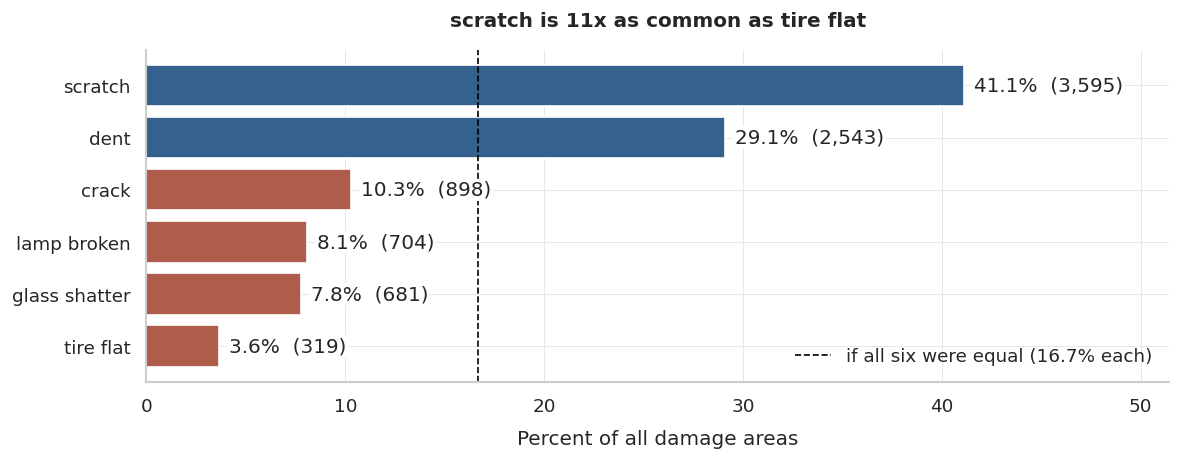

In [247]:
class_totals = annotations["damage_class"].value_counts().sort_values()
class_shares = 100 * class_totals / class_totals.sum()
balanced_share = 100 / len(class_totals)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(
    class_shares.index,
    class_shares.values,
    color=np.where(class_shares < balanced_share, RUST, BLUE),
)
ax.axvline(
    balanced_share,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"if all six were equal ({balanced_share:.1f}% each)",
)

# Label each bar with its share and count; the white box keeps text readable over the line.
for position, (share, count) in enumerate(zip(class_shares, class_totals, strict=True)):
    ax.text(
        share + 0.5,
        position,
        f"{share:.1f}%  ({count:,})",
        va="center",
        bbox={"facecolor": "white", "edgecolor": "none", "pad": 1},
    )

ax.set_xlabel("Percent of all damage areas")
ax.set_xlim(0, class_shares.max() * 1.25)
imbalance_ratio = class_totals.max() / class_totals.min()
ax.set_title(
    f"{class_totals.idxmax()} is {imbalance_ratio:.0f}x as common as {class_totals.idxmin()}"
)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Think of the three partitions as three bags of damage photos.**
- **Each bag has the same flavors in about the same amounts.** The biggest difference: scratches are 41.7% of the validation bag and 39.1% of the test bag, and every other type is closer than that. ✅ So testing on the test bag is fair.
- **But every bag is mostly scratches and dents** (70% of all damage areas). There are about **11 scratches for every flat tire**. 🛞
- **Why that matters:** a lazy model could score well by getting good at scratches and ignoring flat tires. So in Stage 4 we grade each damage type separately (average precision, AP, per type, plus overall mAP), and the rare types can't hide behind the common ones.

### How many damage areas are in each photo?

Photos with no damage labeled at all: 0


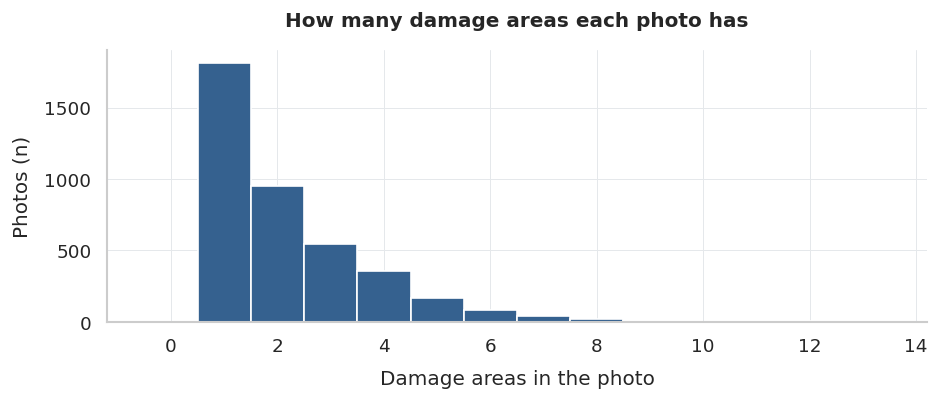

In [248]:
# How many damage areas does each photo have? Zero would mean nobody labeled any damage on it.
areas_per_photo = annotations.groupby(["split", "image_id"]).size().rename("damage_areas")
per_photo = images.merge(
    areas_per_photo.reset_index(),
    left_on=["split", "id"],
    right_on=["split", "image_id"],
    how="left",
    validate="one_to_one",
)
per_photo["damage_areas"] = per_photo["damage_areas"].fillna(0).astype(int)
print(f"Photos with no damage labeled at all: {(per_photo['damage_areas'] == 0).sum()}")

most_areas = per_photo["damage_areas"].max()
fig, ax = plt.subplots(figsize=(8, 3.5))
# Bins centered on whole numbers, starting at 0 so photos with no annotations would show up.
ax.hist(
    per_photo["damage_areas"],
    bins=np.arange(-0.5, most_areas + 1.5),
    color=BLUE,
    edgecolor="white",
)
ax.set_xlabel("Damage areas in the photo")
ax.set_ylabel("Photos (n)")
ax.set_title("How many damage areas each photo has")
plt.tight_layout()
plt.show()

### Are the files consistent?
Before looking at sizes, a few sanity checks: every box should fit inside its photo, every damage area should have an outline, every photo file should exist, and no photo should appear in two partitions. Each count below should be zero.

In [249]:
def attach_box_geometry(images, annotations):
    """One row per damage area, with its box split into columns and its photo's size attached."""
    geometry = annotations.merge(
        images[["split", "id", "file_name", "width", "height"]].rename(
            columns={"id": "image_id"}
        ),
        on=["split", "image_id"],
        how="left",
        validate="many_to_one",
        indicator=True,
    )
    if not (geometry["_merge"] == "both").all():
        raise ValueError("A damage area points to a photo that is not in its partition.")

    # COCO boxes are [x, y, width, height] in pixels.
    if not geometry["bbox"].map(len).eq(4).all():
        raise ValueError("Every box should have exactly four numbers.")
    boxes = pd.DataFrame(
        geometry["bbox"].tolist(),
        columns=["x", "y", "box_w", "box_h"],
        index=geometry.index,
    )
    return geometry.drop(columns="_merge").join(boxes)


geometry = attach_box_geometry(images, annotations)

In [250]:
# Annotation tools often round a box one pixel past the photo's edge, so allow that much.
EDGE_TOLERANCE_PX = 1


def find_bad_boxes(geometry, tolerance=EDGE_TOLERANCE_PX):
    """True for boxes with a missing or infinite number, no size, or that stick out of the photo."""
    # Check bad numbers first: any comparison with NaN is False, so NaN would slip through.
    numbers = geometry[["x", "y", "box_w", "box_h", "width", "height"]].astype(float)
    has_bad_number = ~np.isfinite(numbers).all(axis=1)
    return has_bad_number | (
        (geometry["width"] <= 0)
        | (geometry["height"] <= 0)
        | (geometry["box_w"] <= 0)
        | (geometry["box_h"] <= 0)
        | (geometry["x"] < 0)
        | (geometry["y"] < 0)
        | (geometry["x"] + geometry["box_w"] > geometry["width"] + tolerance)
        | (geometry["y"] + geometry["box_h"] > geometry["height"] + tolerance)
    )


bad_box = find_bad_boxes(geometry)
missing_outline = geometry["segmentation"].map(
    lambda outline: outline is None or len(outline) == 0
)
missing_photo_files = sum(
    not (CARDD_IMAGE_DIRS[row.split] / row.file_name).is_file()
    for row in images.itertuples()
)
filenames = images.groupby("split")["file_name"].apply(set)

consistency_checks = pd.Series(
    {
        "boxes that are broken or stick out of their photo": int(bad_box.sum()),
        "damage areas with no outline": int(missing_outline.sum()),
        "photo files missing": missing_photo_files,
        "same filename twice in one partition": int(
            images.duplicated(["split", "file_name"]).sum()
        ),
        "filenames in both train and validation": len(
            filenames["train"] & filenames["val"]
        ),
        "filenames in both train and test": len(filenames["train"] & filenames["test"]),
        "filenames in both validation and test": len(filenames["val"] & filenames["test"]),
    },
    name="count",
)
display(consistency_checks.to_frame())

# Box sizes below use only good boxes; nothing is clipped or changed.
geometry = geometry.loc[~bad_box].copy()
geometry["box_area_pct"] = (
    100 * (geometry["box_w"] * geometry["box_h"]) / (geometry["width"] * geometry["height"])
)

,count
boxes that are broken or stick out of their photo,0
damage areas with no outline,0
photo files missing,0
same filename twice in one partition,0
filenames in both train and validation,0
filenames in both train and test,0
filenames in both validation and test,0


### How big are the photos, and how much of the photo does each damage box cover?
A box is a rectangle around the damage, so it also covers some undamaged paint around it.

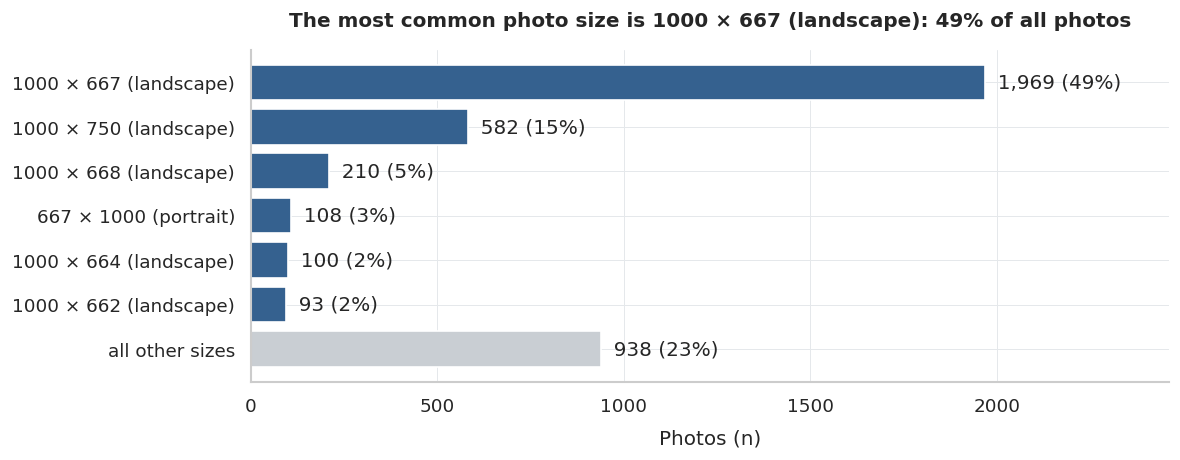

,median_pct,damage_areas
damage_class,,
crack,1.0,898
scratch,5.6,3595
dent,8.2,2543
lamp broken,18.1,704
tire flat,34.7,319
glass shatter,67.8,681


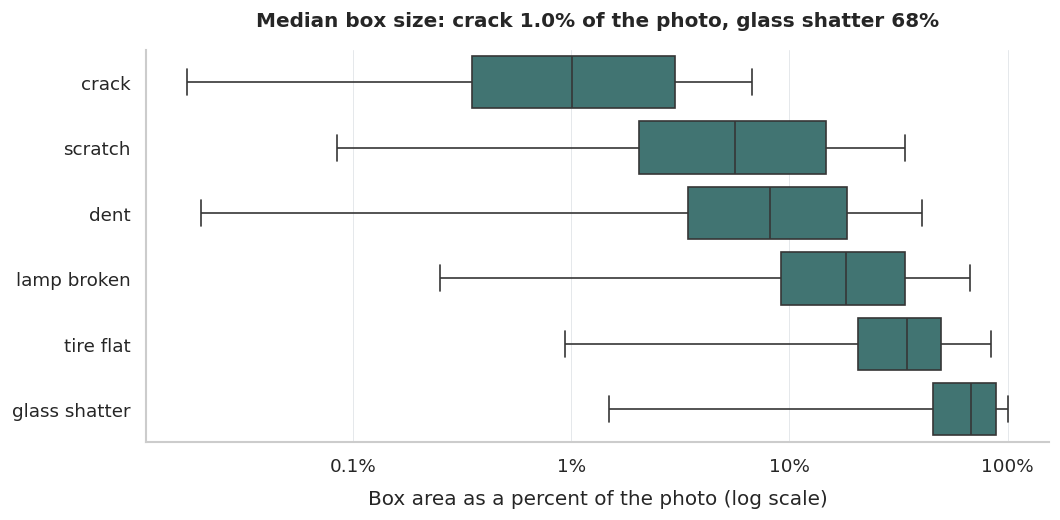

In [251]:
# Most common photo sizes, written the way people say them ("1000 x 667, landscape").
def photo_shape(width, height):
    if width > height:
        return "landscape"
    return "portrait" if height > width else "square"


photo_sizes = images.assign(
    size=images["width"].astype(int).astype(str)
    + " × "
    + images["height"].astype(int).astype(str)
    + " ("
    + [photo_shape(w, h) for w, h in zip(images["width"], images["height"], strict=True)]
    + ")"
)["size"].value_counts()
TOP_SIZES = 6
top_sizes = photo_sizes.head(TOP_SIZES)
other_count = photo_sizes.iloc[TOP_SIZES:].sum()
size_counts = pd.concat([top_sizes, pd.Series({"all other sizes": other_count})]).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(
    size_counts.index,
    size_counts.values,
    color=[
        LIGHT_GRAY if label == "all other sizes" else BLUE for label in size_counts.index
    ],
)
for position, count in enumerate(size_counts.values):
    ax.text(count, position, f"  {count:,} ({count / len(images):.0%})", va="center")
ax.set_xlim(0, size_counts.max() * 1.25)
ax.set_xlabel("Photos (n)")
ax.set_title(
    f"The most common photo size is {photo_sizes.index[0]}: "
    f"{photo_sizes.iloc[0] / len(images):.0%} of all photos"
)
plt.tight_layout()
plt.show()

# Typical share of the photo that one damage box covers, by damage type.
# (The box is a rectangle, so this overstates the damaged area itself.)
box_size_order = (
    geometry.groupby("damage_class")["box_area_pct"].median().sort_values().index
)
box_size_summary = (
    geometry.groupby("damage_class")["box_area_pct"]
    .agg(median_pct="median", damage_areas="size")
    .reindex(box_size_order)
)
display(box_size_summary.round(1))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(
    data=geometry,
    x="box_area_pct",
    y="damage_class",
    order=box_size_order,
    showfliers=False,
    color=TEAL,
    ax=ax,
)
ax.set_xscale("log")  # box sizes run from well under 1% to nearly 100% of the photo
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:g}%"))  # 1%, 10%, 100%
ax.set_xlabel("Box area as a percent of the photo (log scale)")
ax.set_ylabel("")
smallest, largest = box_size_order[0], box_size_order[-1]
ax.set_title(
    f"Median box size: {smallest} {box_size_summary.loc[smallest, 'median_pct']:.1f}% "
    f"of the photo, {largest} {box_size_summary.loc[largest, 'median_pct']:.0f}%"
)
plt.tight_layout()
plt.show()

In [252]:
# @title Helper: draw a photo with its damage labels { display-mode: "form" }
BOX_COLOR = "#F7B32B"  # yellow boxes and labels
OUTLINE_COLOR = "#53A7D8"  # blue damage outlines


def draw_labeled_photo(ax, photo_path, photo_areas):
    """Show a photo with each damage area's box, damage type, and outline."""
    with Image.open(photo_path) as photo:
        ax.imshow(photo.convert("RGB"))

    for area in photo_areas.itertuples():
        ax.add_patch(
            Rectangle(
                (area.x, area.y),
                area.box_w,
                area.box_h,
                fill=False,
                edgecolor=BOX_COLOR,
                linewidth=1.5,
            )
        )
        ax.text(
            area.x,
            area.y,
            area.damage_class,
            fontsize=8,
            color="black",
            bbox={"facecolor": BOX_COLOR, "alpha": 0.85, "pad": 1},
        )
        # Outlines are stored as flat [x1, y1, x2, y2, ...] lists of points.
        for outline in area.segmentation:
            ax.add_patch(
                Polygon(
                    np.asarray(outline).reshape(-1, 2), facecolor=OUTLINE_COLOR, alpha=0.3
                )
            )
    ax.axis("off")

### Example photos with their labels
One test photo per damage type (the lowest photo id that contains it), so the grid is the same on every run.

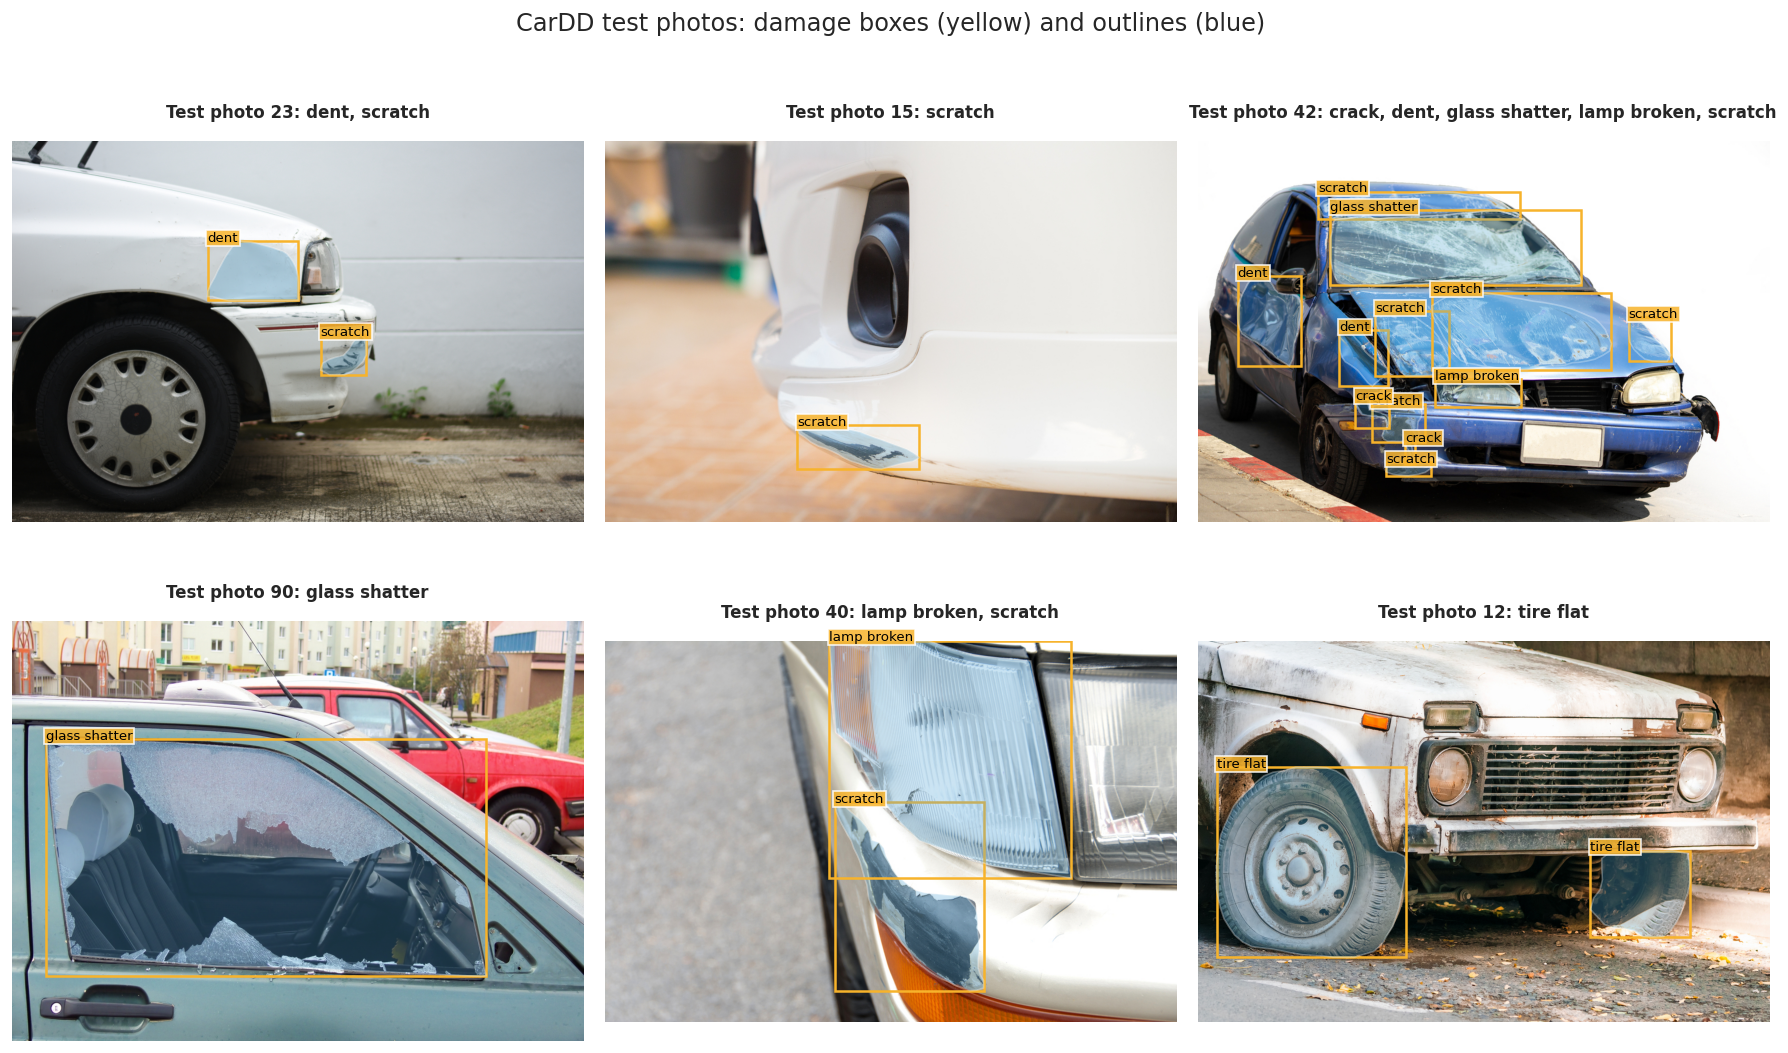

In [253]:
test_geometry = geometry[geometry["split"] == "test"]

example_photo_ids = []
for damage_class in categories.values():
    photo_ids = sorted(
        test_geometry.loc[test_geometry["damage_class"] == damage_class, "image_id"]
    )
    unused_ids = [photo_id for photo_id in photo_ids if photo_id not in example_photo_ids]
    if unused_ids:
        example_photo_ids.append(unused_ids[0])

fig, axes = plt.subplots(2, 3, figsize=(15, 9.5))
for ax in axes.ravel():
    ax.axis("off")

# Up to six examples; any unused panel stays blank, so the lengths can differ.
for ax, photo_id in zip(axes.ravel(), example_photo_ids, strict=False):
    photo_areas = test_geometry[test_geometry["image_id"] == photo_id]
    photo_path = CARDD_IMAGE_DIRS["test"] / photo_areas["file_name"].iloc[0]
    draw_labeled_photo(ax, photo_path, photo_areas)
    damage_types = ", ".join(sorted(photo_areas["damage_class"].unique()))
    ax.set_title(f"Test photo {photo_id}: {damage_types}", fontsize=10)

fig.suptitle("CarDD test photos: damage boxes (yellow) and outlines (blue)")
plt.tight_layout()
plt.show()

### What Part B tells us
- **Size.** 4,000 photos with 8,740 labeled damage areas, split by the authors into 2,816 / 810 / 374 photos.
- **Balance.** The three partitions have nearly the same mix of damage types; no type's share differs by more than a few percentage points between them. The dataset as a whole is lopsided, though: about 11 scratches for every flat tire. Stage 4 reports average precision (AP) for each damage type plus overall mAP, so the rare types can't hide behind the common ones.
- **Size of the damage.** The typical crack box covers about 1% of the photo and the typical shattered-glass box about 68%, so the detector has to find both very small and very large things.
- **Consistency.** All file checks came back clean: no boxes outside their photo, no missing files, and no filename shared between partitions. That does not rule out two different photos of the same car.
- **No clean cars.** Every photo has at least one labeled damage area. To check whether the detector cries wolf on a clean car, we need to add some photos of undamaged cars ourselves.

In [254]:
# Optional: look for photos that are byte-for-byte identical. This finds exact copies only,
# not crops, re-saved files, or different photos of the same car.
if HASH_CARDD_PIXELS:
    photo_hashes = images.assign(
        sha256=[
            file_sha256(CARDD_IMAGE_DIRS[row.split] / row.file_name)
            for row in images.itertuples()
        ]
    )
    partitions_per_hash = photo_hashes.groupby("sha256")["split"].nunique()
    print(
        f"Identical photo files:                 {photo_hashes['sha256'].duplicated().sum()}"
    )
    print(f"Identical files in more than one split: {(partitions_per_hash > 1).sum()}")
else:
    print("Skipped the identical-photo check (set HASH_CARDD_PIXELS = True to run it).")

Skipped the identical-photo check (set HASH_CARDD_PIXELS = True to run it).


## Next steps (Stage 4)
- Review the held VIN-derived values and label mappings before choosing the missing-attribute treatment.
- After approval, implement the prespecified treatment comparison with train-only preprocessing and fixed model settings. Keep completed historical scores and label any test-informed correction post-holdout.
- Continue damage detection on authorized CarDD data; verify an undamaged-photo control set before claiming false-alarm performance.
- Acquire a later untouched auction sample and genuinely linked photo-price data before current-market or damage-value claims.

## Additional references
- CarDD: https://cardd-ustc.github.io/ ; Wang, Li & Wu (2023), *IEEE Transactions on Intelligent Transportation Systems*.
- DSBA 6165 project guidelines.
